# Проект Маркетинг

Интернет-магазин собирает историю покупателей, проводит рассылки предложений и
планирует будущие продажи. Для оптимизации процессов надо выделить пользователей,
которые готовы совершить покупку в ближайшее время.

# Постановка задачи

Цель: Предсказать вероятность покупки в течение 90 дней

## Критерии успеха
- метрика roc_auc, минимальный порог не задан

<div class="alert alert-secondary" style="background-color:#D9EEE1;color:black;">

[ссылка на датасет](https://disk.yandex.ru/d/cIfdQTAPMQ8XxA)

## Описание данных

**apparel-purchases**

Данные о покупках клиентов по дням и по товарам. В каждой записи покупка
определенного товара, его цена, количество штук.

В таблице есть списки идентификаторов, к каким категориям относится товар. Часто
это вложенные категории (например автотовары-аксессуары-освежители), но также может
включать в начале списка маркер распродажи или маркер женщинам/мужчинам.

Нумерация категорий сквозная для всех уровней, то есть 44 на второй позиции списка
или на третьей – это одна и та же категория. Иногда дерево категорий обновляется, поэтому
могут меняться вложенности, например ['4', '28', '44', '1594'] или ['4', '44', '1594']. Как
обработать такие случаи – можете предлагать свои варианты решения.

- `client_id` идентификатор клиента
- `quantity` количество единиц товара
- `price` цена товара
- `category_ids` идентификаторы категорий
- `date` дата покупки
- `message_id` идентификатор сообщения из рассылки

**apparel-messages**

Рассылки, которые были отправлены клиентам из таблицы покупок.

- `bulk_campaign_id` идентификатор рассылки
- `client_id` идентификатор клиента
- `message_id` идентификатор сообщения
- `event` действие с сообщением (отправлено, открыто, покупка…)
- `channel` канал рассылки
- `date` дата действия
- `created_at` дата-время полностью

**target**
- `client_id` идентификатор клиента
- `target` клиент совершил покупку в целевом периоде
    - **целевой признак**

Общая база рассылок огромна, поэтому собрали для вас агрегированную по дням
статистику по рассылкам. Если будете создавать на основе этой статистики дополнительные
признаки, обратите внимание, что нельзя суммировать по колонкам nunique, потому что это
уникальные клиенты в пределах дня, у вас нет данных, повторяются ли они в другие дни

**full_campaign_daily_event**

Агрегация общей базы рассылок по дням и типам событий

- `date` дата
- `bulk_campaign_id` идентификатор рассылки
- `count_event`* общее количество каждого события event
- `nunique_event`* количество уникальных client_id в каждом событии

\*в именах колонок найдете все типы событий event

**full_campaign_daily_event_channel**

Агрегация по дням с учетом событий и каналов рассылки

- `date` дата
- `bulk_campaign_id` идентификатор рассылки
- `count_event_channel`* общее количество каждого события по каналам
- `nunique_event_channel`* количество уникальных client_id по событиям и каналам

\* в именах колонок есть все типы событий event и каналов рассылки channel


# Инициализация

## Импорт библиотек

In [1]:
CLASSIFICATION_TASK = 1
REGRESSION_TASK = 0

In [2]:
!pip install phik -q
import phik

In [3]:
if CLASSIFICATION_TASK:
    !pip install lightgbm -q
    import lightgbm as lgb

In [4]:
if CLASSIFICATION_TASK:
    !pip install xgboost -q
    from xgboost import XGBClassifier

In [5]:
!pip install category_encoders -q
from category_encoders import TargetEncoder

In [6]:
!pip install shap -q
import shap

In [7]:
import pandas as pd
import numpy as np
import os

import matplotlib.pyplot as plt 
import seaborn as sns

if REGRESSION_TASK:
    from sklearn.linear_model import LinearRegression
    from sklearn.tree import DecisionTreeRegressor
    from sklearn.svm import SVR 
    from sklearn.ensemble import RandomForestRegressor
    from sklearn.metrics import (root_mean_squared_error)
if CLASSIFICATION_TASK:
    from sklearn.linear_model import LogisticRegression
    from sklearn.tree import DecisionTreeClassifier
    from sklearn.svm import SVC 
    from sklearn.metrics import classification_report
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.metrics import RocCurveDisplay, roc_curve
    from sklearn.metrics import PrecisionRecallDisplay, roc_auc_score, \
                                precision_recall_curve

from sklearn.model_selection import train_test_split, \
                                RandomizedSearchCV #, GridSearchCV

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (OneHotEncoder, OrdinalEncoder, 
                                   MinMaxScaler, StandardScaler)
from sklearn.compose import ColumnTransformer

import re
import time
from datetime import datetime, timedelta

from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import ADASYN

## Установка главных параметров

In [8]:
RANDOM_STATE = 42

# Вспомогательные функции

In [9]:
def correct_path (csv_name, folder=""):
    if not os.path.exists(folder + csv_name):
        return '/datasets/' + csv_name
    return folder + csv_name

def def_load_csv(csv, folder="", print_info=True):
    display(f"⬇-------- Таблица {csv}: ----------⬇")
    df = pd.read_csv(correct_path(csv, folder))
    if print_info:
        display(df.info())
        display(df.head())
    return df

def columns_to_snake_case (df):
    names = {}
    for c in df.columns:
        names [c] = re.sub(r'(?<!^)(?=[A-Z])', '_', c).lower()
    df.rename(columns=names, inplace=True)
    return df

# визуализирует все категориальные фичи датафрейма в виде пирогов
# визуализирует все категориальные фичи датафрейма в виде ящиков с усами и гистограмм с распределением, выводит descirbe
# поддерживает любое количество фильтров, фильтры поочерёдно применяются к датафрейму как запрос в query(),
#   графики выводятся для каждого фильтра
#   чтобы вывести графики без фильтра нужно передать пустой запрос, или же не передавать фильтры вовсе


def keep_top_group_other (d, top_n = 10):
    vc = d.value_counts()
    l = len (vc)
    if l > top_n:
        t = vc[:top_n].index
        display(t)
        d = d.apply(lambda x: x if x in t else f'Other {l-top_n} categories')
    return d

def do_eda(df, columns=[], filters=[]):
    bins=25
    n_filters = len(filters)
    PIE_WIDTH = 5
    
    if len (columns) == 0:
        columns = df.columns

    # вывод графиков по категориальным фичам 
    for column in columns:
        if df[column].dtype == 'O':
            display (f"⬇-------- столбец {column} --------⬇")
            title0 = f"столбец {column}, количество и доля значений"
            df_show = df[column]
            if n_filters > 0 and filters[0] != '':
                title = title0 + f"\nфильтр: {filters[0]}"
                df_show = df.query(filters[0])[column]
            # if n_filters ...: 👷🚩[todo] поддержать фильтры при помощи гистограммы с группировкой
            v = keep_top_group_other(df_show) \
                .value_counts(normalize=False, ascending=True)
            ax = v.plot.barh(title=title0);
            s = v.values.sum()
            for i, value in enumerate(v.values):
                ax.text(value + 5, i, f'{value} ({int(value*100/s)}%)')
            xmin, xmax = ax.get_xlim()
            ax.set_xlim(xmin, 1.2*xmax)
        plt.show();

    # вывод графиков по числовым фичам 
    if n_filters == 0:
        filters = ['']
        n_filters = 1
    for column in columns:
        if df[column].dtype in ['int64', 'float64'] and column != "id":
            display (f"⬇-------- Следующий признак: {column} --------⬇")
            fig, axs = plt.subplots(nrows=2*max(1, n_filters), ncols=1, 
                                    figsize=(6, 7*n_filters))
            for i in range (n_filters):
                title = f"столбец {column}"
                df_show = df[column]
                if filters[i] != '':
                    title = title + f", фильтр: {filters[i]}"
                    df_show = df.query(filters[i])[column]
                axs[i*2].boxplot(df_show, vert=False);
                ##v1 sns.boxplot(data=df_show, ax=axs[i*2], palette=['lightsteelblue'], orient='h')
                axs[i*2].set_title(title, fontsize=9)
                sns.histplot(df_show, bins=bins, kde=True, ax=axs[i*2+1], alpha=0.8)
                axs[i*2+1].set_xlabel('')
                display(f"фильтр = '{filters[i]}'")
                display(df_show.describe())
            plt.show();

def print_unique_text_features(df):
    for c in df.columns:
        if df[c].dtype == 'O':
            x = df[c].unique()
            x = np.sort(x[~pd.isnull(x)])
            display(f"⬇-------- Feature \"{c}\"--------⬇")
            display(x)

def split_date (df, date_column, needed_parts, format="", drop_date_column=False):
    if format != "":
        df[date_column] = pd.to_datetime(df[date_column], format=format)
    if ['y' in needed_parts]:
        df [date_column + "_year"] = df[date_column].dt.year
    if ['m' in needed_parts]:
        df [date_column + "_month"] = df[date_column].dt.month
    if ['d' in needed_parts]:
        df [date_column + "_day"] = df[date_column].dt.day
    if ['w' in needed_parts]:
        df [date_column + "_weekday"] = df[date_column].dt.weekday
    if ['h' in needed_parts]:
        df [date_column + "_hour"] = df[date_column].dt.hour
    if drop_date_column:
        df = df.drop([date_column], axis=1)
    return df

def show_nans (df):
    n = df.isna().sum()
    l = len(df)
    display("empty parts:")
    display(round(n [n>0] / l, 2))

def get_multicollinear_features (phik_matrix):
    mc_features=[]
    while True:
        if len(phik_matrix) == 0:
            break
        mc_features_ranked = phik_matrix[(phik_matrix >= 0.9) & (phik_matrix < 1)].sum()
        mc_features_ranked = mc_features_ranked[mc_features_ranked>0] \
            .sort_values(ascending=False)
        if len(mc_features_ranked) == 0:
            break
        top_mc_feature = mc_features_ranked.index[0]
        phik_matrix = phik_matrix.drop(top_mc_feature,axis=0)
        phik_matrix = phik_matrix.drop(top_mc_feature,axis=1)
        mc_features.append(top_mc_feature)
    return mc_features, phik_matrix

# Подготовка данных

## Загрузка таблиц

In [10]:
folder = 'C:/TMP/filtered_data/'
df_apparel_purchases = def_load_csv ('apparel-purchases.csv', folder=folder)
df_apparel_messages = def_load_csv ('apparel-messages.csv', folder=folder)
df_apparel_target = def_load_csv ('apparel-target_binary.csv', folder=folder)
df_full_events = def_load_csv ('full_campaign_daily_event.csv', folder=folder)
df_full_events_channel = def_load_csv ('full_campaign_daily_event_channel.csv', folder=folder)

'⬇-------- Таблица apparel-purchases.csv: ----------⬇'

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 202208 entries, 0 to 202207
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   client_id     202208 non-null  int64  
 1   quantity      202208 non-null  int64  
 2   price         202208 non-null  float64
 3   category_ids  202208 non-null  object 
 4   date          202208 non-null  object 
 5   message_id    202208 non-null  object 
dtypes: float64(1), int64(2), object(3)
memory usage: 9.3+ MB


None

,client_id,quantity,price,category_ids,date,message_id
0,1515915625468169594,1,1999.0,"['4', '28', '57', '431']",2022-05-16,1515915625468169594-4301-627b661e9736d
1,1515915625468169594,1,2499.0,"['4', '28', '57', '431']",2022-05-16,1515915625468169594-4301-627b661e9736d
2,1515915625471138230,1,6499.0,"['4', '28', '57', '431']",2022-05-16,1515915625471138230-4437-6282242f27843
3,1515915625471138230,1,4999.0,"['4', '28', '244', '432']",2022-05-16,1515915625471138230-4437-6282242f27843
4,1515915625471138230,1,4999.0,"['4', '28', '49', '413']",2022-05-16,1515915625471138230-4437-6282242f27843


'⬇-------- Таблица apparel-messages.csv: ----------⬇'

...

,date,bulk_campaign_id,count_click,count_complain,count_hard_bounce,count_open,count_purchase,count_send,count_soft_bounce,count_subscribe,...,nunique_open,nunique_purchase,nunique_send,nunique_soft_bounce,nunique_subscribe,nunique_unsubscribe,count_hbq_spam,nunique_hbq_spam,count_close,nunique_close
0,2022-05-19,563,0,0,0,4,0,0,0,0,...,4,0,0,0,0,0,0,0,0,0
1,2022-05-19,577,0,0,0,1,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
2,2022-05-19,622,0,0,0,2,0,0,0,0,...,2,0,0,0,0,0,0,0,0,0
3,2022-05-19,634,0,0,0,1,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
4,2022-05-19,676,0,0,0,1,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0


'⬇-------- Таблица full_campaign_daily_event_channel.csv: ----------⬇'

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 131072 entries, 0 to 131071
Data columns (total 36 columns):
 #   Column                           Non-Null Count   Dtype 
---  ------                           --------------   ----- 
 0   date                             131072 non-null  object
 1   bulk_campaign_id                 131072 non-null  int64 
 2   count_click_email                131072 non-null  int64 
 3   count_click_mobile_push          131072 non-null  int64 
 4   count_open_email                 131072 non-null  int64 
 5   count_open_mobile_push           131072 non-null  int64 
 6   count_purchase_email             131072 non-null  int64 
 7   count_purchase_mobile_push       131072 non-null  int64 
 8   count_soft_bounce_email          131072 non-null  int64 
 9   count_subscribe_email            131072 non-null  int64 
 10  count_unsubscribe_email          131072 non-null  int64 
 11  nunique_click_email              131072 non-null  int64 
 12  nunique_click_mo

None

,date,bulk_campaign_id,count_click_email,count_click_mobile_push,count_open_email,count_open_mobile_push,count_purchase_email,count_purchase_mobile_push,count_soft_bounce_email,count_subscribe_email,...,count_send_email,nunique_hard_bounce_email,nunique_hbq_spam_email,nunique_send_email,count_soft_bounce_mobile_push,nunique_soft_bounce_mobile_push,count_complain_email,nunique_complain_email,count_close_mobile_push,nunique_close_mobile_push
0,2022-05-19,563,0,0,4,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2022-05-19,577,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,2022-05-19,622,0,0,2,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,2022-05-19,634,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,2022-05-19,676,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## Исправим типы данных

In [11]:
df_apparel_purchases = split_date (df_apparel_purchases, 'date', 
                                   needed_parts='ymdw', format='%Y-%m-%d')
df_apparel_messages = split_date (df_apparel_messages, 'date', 
                                  needed_parts='ymdw', format='%Y-%m-%d')
df_apparel_messages = split_date (df_apparel_messages, 'created_at', 
                                  needed_parts='ymdwh', format='%Y-%m-%d %H:%M:%S')
df_full_events = split_date (df_full_events, 'date', 
                                   needed_parts='ymdw', format='%Y-%m-%d')
df_full_events_channel = split_date (df_full_events_channel, 'date', 
                                   needed_parts='ymdw', format='%Y-%m-%d')

Изучим category_ids - можно ли их заменить, например, OHE?

In [12]:
df_apparel_purchases['category_ids'].value_counts()

['4', '28', '57', '431']            8626
['4', '28', '260', '420']           6989
['4', '28', '244', '432']           6821
[]                                  5579
['4', '28', '275', '421']           4936
                                    ... 
['5562', '5589', '5623', '1775']       1
['4', '28', '44', '528']               1
['5562', '5597', '5696', '751']        1
['4', '44', '1600']                    1
['1', '8', '280', '710']               1
Name: category_ids, Length: 933, dtype: int64

Оценим глубину вложенных категорий:

In [13]:
df_apparel_purchases['category_ids'].apply (lambda x: len(x.split(','))) \
                                            .value_counts(dropna=False)

4    193491
1      6843
3      1356
5       518
Name: category_ids, dtype: int64

- категория бывает представлена цепочками из 0, 1, 3, 4, 5 элементов.
- всего не более 933 видов (уникальных цепочек категорий) товаров покупали клиенты.

933 - многовато для OHE. Попробуем укрупнить категории (исходя из того, что они вложены и корень - слева). Попробуем укоротить цепочку, удалив более специфичные подветки, и оставив более крупные категории.

Для начала просто разделим цепочки на отдельные столбцы и посмотрим на их значения.

In [14]:
def get_element(x, i):
    l = re.sub("[ \'\[\]]", '', x).split(',')
    val = 0
    if i < len(l) and len(l[i])>0 and l[i] != 'None':
        val = int(l[i])
    return val

for i in range(5):
    df_apparel_purchases[f'cat{i+1}'] = df_apparel_purchases['category_ids'].apply (lambda x: get_element(x, i))


In [15]:
df_apparel_purchases.head()

,client_id,quantity,price,category_ids,date,message_id,date_year,date_month,date_day,date_weekday,date_hour,cat1,cat2,cat3,cat4,cat5
0,1515915625468169594,1,1999.0,"['4', '28', '57', '431']",2022-05-16,1515915625468169594-4301-627b661e9736d,2022,5,16,0,0,4,28,57,431,0
1,1515915625468169594,1,2499.0,"['4', '28', '57', '431']",2022-05-16,1515915625468169594-4301-627b661e9736d,2022,5,16,0,0,4,28,57,431,0
2,1515915625471138230,1,6499.0,"['4', '28', '57', '431']",2022-05-16,1515915625471138230-4437-6282242f27843,2022,5,16,0,0,4,28,57,431,0
3,1515915625471138230,1,4999.0,"['4', '28', '244', '432']",2022-05-16,1515915625471138230-4437-6282242f27843,2022,5,16,0,0,4,28,244,432,0
4,1515915625471138230,1,4999.0,"['4', '28', '49', '413']",2022-05-16,1515915625471138230-4437-6282242f27843,2022,5,16,0,0,4,28,49,413,0


<AxesSubplot:>

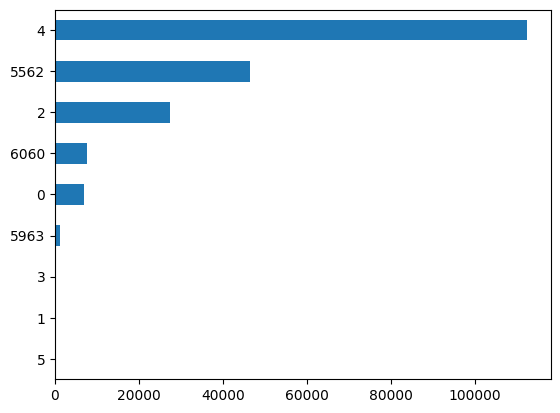

In [16]:
df_apparel_purchases['cat1'].value_counts(ascending=True).plot.barh()

<AxesSubplot:>

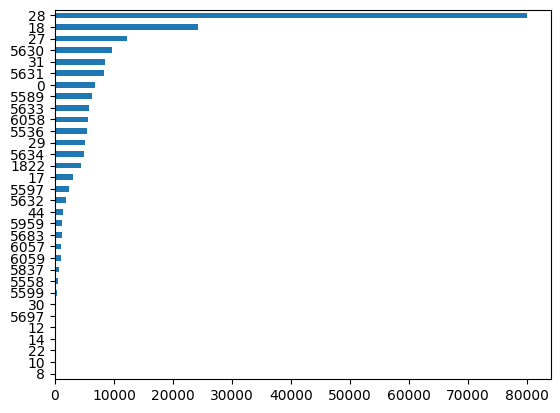

In [17]:
df_apparel_purchases['cat2'].value_counts(ascending=True).plot.barh()

<AxesSubplot:>

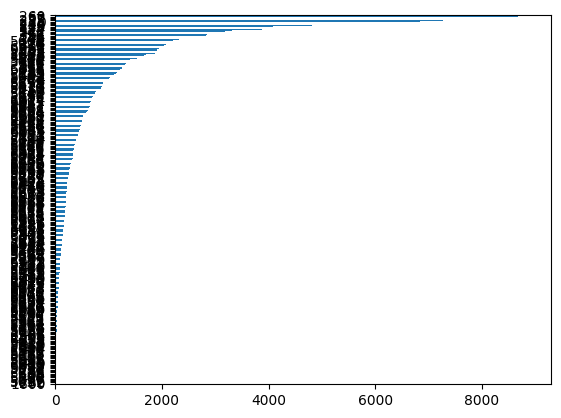

In [18]:
df_apparel_purchases['cat3'].value_counts(ascending=True).plot.barh()

<AxesSubplot:>

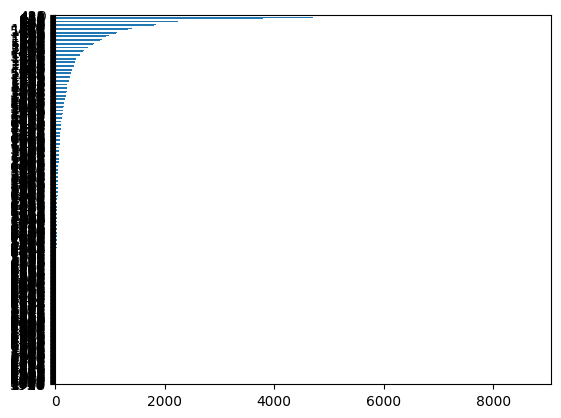

In [19]:
df_apparel_purchases['cat4'].value_counts(ascending=True).plot.barh()

<AxesSubplot:>

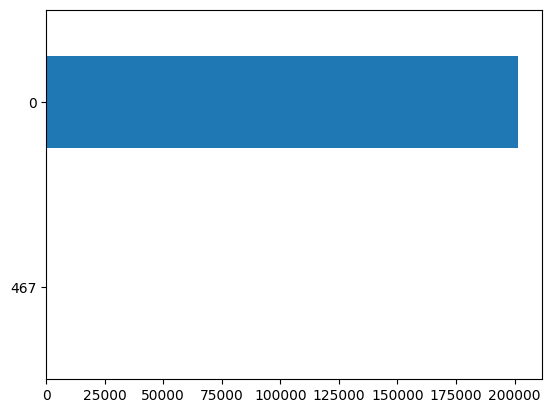

In [20]:
df_apparel_purchases['cat5'].value_counts(ascending=True).plot.barh()

Сходу не очень понятно, что с этим делать. Есть соблазн укрупнить просто по первому элементу и применить OHE (выбросив остальные элементы цепочки) - но, вероятно, это слишком грубо. Другой вариант - оставить в текущем виде. Либо, возможно, придут новые идеи после объединения датафреймов и анализа мультикллиенарности.

## Изучим пропуски

In [21]:
show_nans (df_apparel_purchases)

'empty parts:'

Series([], dtype: float64)

In [22]:
show_nans (df_apparel_messages)

'empty parts:'

Series([], dtype: float64)

In [23]:
show_nans (df_full_events)

'empty parts:'

Series([], dtype: float64)

In [24]:
show_nans (df_full_events_channel)

'empty parts:'

Series([], dtype: float64)

Пропусков нет.

## Изучим и удалим явные дубликаты в датафрейме

In [25]:
display(df_apparel_purchases.duplicated().sum())

73020

Дубли ⤴ покупок  удалять не будем, т. к. это могут быть повторные покупки одного и того же товара в тот же день и в связи с тем же сообщением.

In [26]:
display(df_apparel_messages.duplicated().sum())

48610

А эти сообщения ⤴ имеют дату с точностью до секунды, поэтому такие дубликаты - удалим:

In [27]:
df_apparel_messages = df_apparel_messages.drop_duplicates()

In [28]:
display(df_apparel_target.duplicated().sum())

0

In [29]:
display(df_full_events.duplicated().sum())

0

In [30]:
display(df_full_events_channel.duplicated().sum())

0

## Изучим неявные дубликаты в датафрейме


In [31]:
print_unique_text_features(df_apparel_purchases)

'⬇-------- Feature "category_ids"--------⬇'

array(["['1', '22', '50', '685']", "['1', '8', '280', '710']",
       "['2', '17', '107', '453']", "['2', '17', '137', '469']",
       "['2', '17', '171', '475']", "['2', '17', '173', '1598']",
       "['2', '17', '173', '1845']", "['2', '17', '173', '459']",
       "['2', '17', '180', '465']", "['2', '17', '1826', '1818']",
       "['2', '17', '188', '525']", "['2', '17', '198', '497']",
       "['2', '17', '232', '463']", "['2', '17', '279', '5807']",
       "['2', '17', '286', '455']", "['2', '17', '293', '5819']",
       "['2', '17', '330', '387', '467']", "['2', '17', '83', '519']",
       "['2', '17', '83', '5810']", "['2', '18', '123', '451']",
       "['2', '18', '155', '1325']", "['2', '18', '155', '439']",
       "['2', '18', '212', '658']", "['2', '18', '212', '659']",
       "['2', '18', '212', '726']", "['2', '18', '217', '662']",
       "['2', '18', '217', '663']", "['2', '18', '243', '440']",
       "['2', '18', '248', '449']", "['2', '18', '248', '677']",
       "['2', 

'⬇-------- Feature "message_id"--------⬇'

array(['1515915625468060902-4617-6290657dac196',
       '1515915625468061003-9148-63b54b04855a4',
       '1515915625468061099-4439-62834141aa538', ...,
       '1515915626010152263-14649-65cca1b63edf7',
       '1515915626010221592-14664-65cf1622434a9',
       '1515915626010261344-14648-65cdb6d56c4c8'], dtype=object)

In [32]:
print_unique_text_features(df_apparel_messages)

'⬇-------- Feature "message_id"--------⬇'

array(['1515915625468060902-10022-63e5ededd911f',
       '1515915625468060902-10218-63ef56ed94656',
       '1515915625468060902-10289-63f35a8a9ff35', ...,
       '1515915626010234726-14656-65cdd2f839b78',
       '1515915626010261344-14648-65cdb6d56c4c8',
       '1515915626010288690-14648-65cdb6d29b698'], dtype=object)

'⬇-------- Feature "event"--------⬇'

array(['click', 'close', 'complain', 'hard_bounce', 'hbq_spam', 'open',
       'purchase', 'send', 'soft_bounce', 'subscribe', 'unsubscribe'],
      dtype=object)

'⬇-------- Feature "channel"--------⬇'

array(['email', 'mobile_push'], dtype=object)

Неявных дубликатов не найдено.

# Исследовательский анализ данных (EDA)

'⬇-------- столбец category_ids --------⬇'

Index(['['4', '28', '57', '431']', '['4', '28', '260', '420']',
       '['4', '28', '244', '432']', '[]', '['4', '28', '275', '421']',
       '['2', '18', '258', '441']', '['4', '28', '62', '657']',
       '['4', '28', '62', '656']', '['4', '28', '124', '415']',
       '['4', '28', '275', '673']'],
      dtype='object')

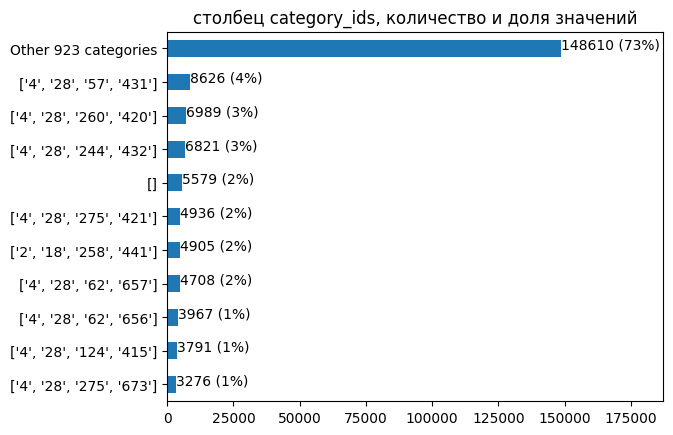

'⬇-------- столбец message_id --------⬇'

Index(['1515915625489095763-6251-6311b13a4cf78',
       '1515915625624308268-7803-636dfea7ca890',
       '1515915625880116527-8725-639b2f0ad5e2e',
       '1515915625607113301-13818-650a8af70fd67',
       '1515915625558691508-14212-6567128370bdd',
       '1515915625490352441-13443-64a52fa882390',
       '1515915625567363010-7576-63637523deb92',
       '1515915625559931867-13598-64cd08c473b82',
       '1515915625488041632-6336-63198505ee106',
       '1515915625558824236-13319-64851ce067caa'],
      dtype='object')

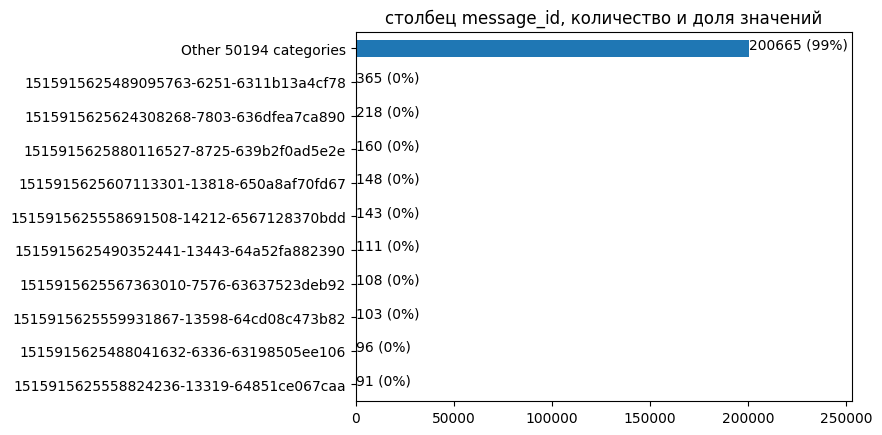

'⬇-------- Следующий признак: client_id --------⬇'

"фильтр = ''"

count    2.022080e+05
mean     1.515916e+18
std      1.459458e+08
min      1.515916e+18
25%      1.515916e+18
50%      1.515916e+18
75%      1.515916e+18
max      1.515916e+18
Name: client_id, dtype: float64

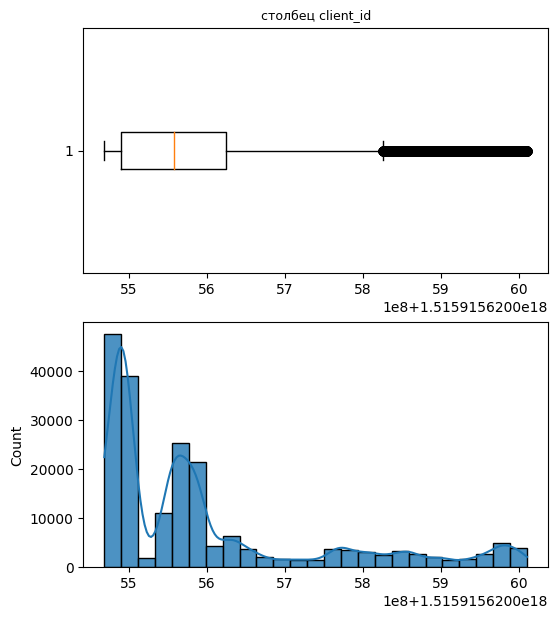

'⬇-------- Следующий признак: quantity --------⬇'

"фильтр = ''"

count    202208.000000
mean          1.006483
std           0.184384
min           1.000000
25%           1.000000
50%           1.000000
75%           1.000000
max          30.000000
Name: quantity, dtype: float64

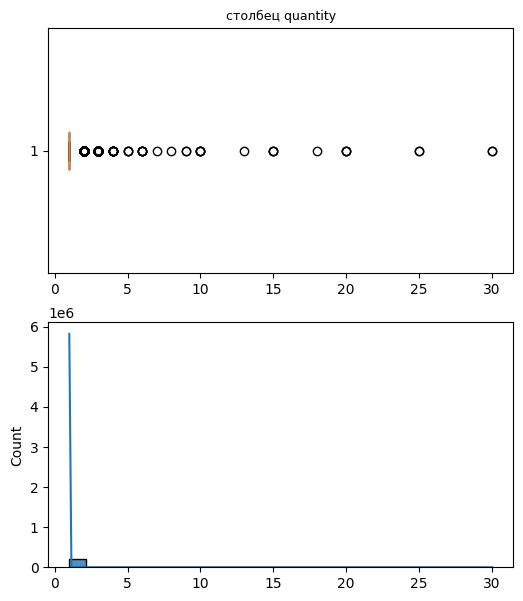

'⬇-------- Следующий признак: price --------⬇'

"фильтр = ''"

count    202208.000000
mean       1193.301516
std        1342.252664
min           1.000000
25%         352.000000
50%         987.000000
75%        1699.000000
max       85499.000000
Name: price, dtype: float64

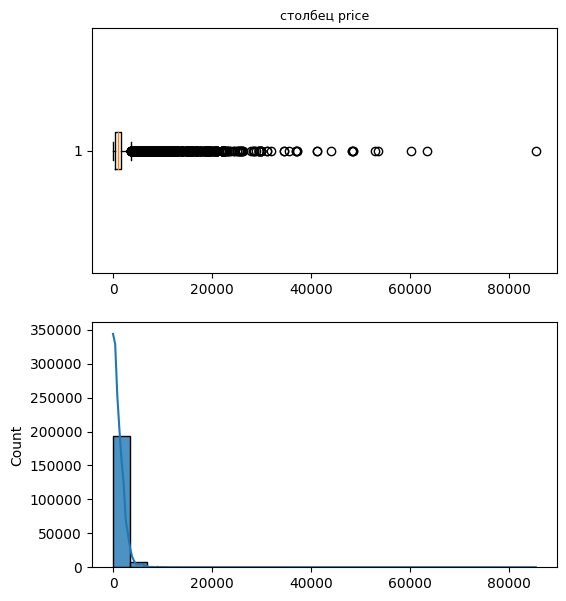

'⬇-------- Следующий признак: date_year --------⬇'

"фильтр = ''"

count    202208.000000
mean       2022.650291
std           0.579045
min        2022.000000
25%        2022.000000
50%        2023.000000
75%        2023.000000
max        2024.000000
Name: date_year, dtype: float64

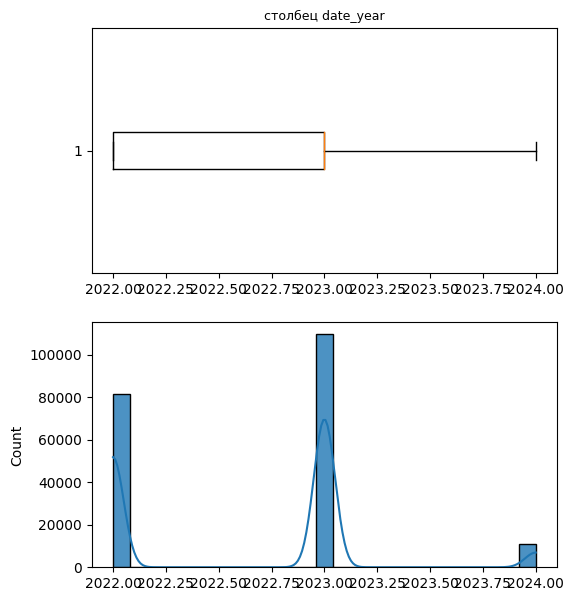

'⬇-------- Следующий признак: date_month --------⬇'

"фильтр = ''"

count    202208.000000
mean          7.219358
std           3.294712
min           1.000000
25%           5.000000
50%           7.000000
75%          11.000000
max          12.000000
Name: date_month, dtype: float64

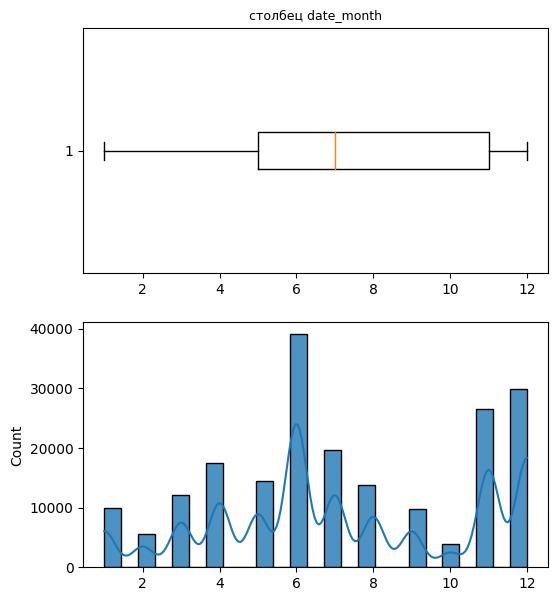

'⬇-------- Следующий признак: date_day --------⬇'

"фильтр = ''"

count    202208.000000
mean         15.466708
std           8.556121
min           1.000000
25%           9.000000
50%          15.000000
75%          23.000000
max          31.000000
Name: date_day, dtype: float64

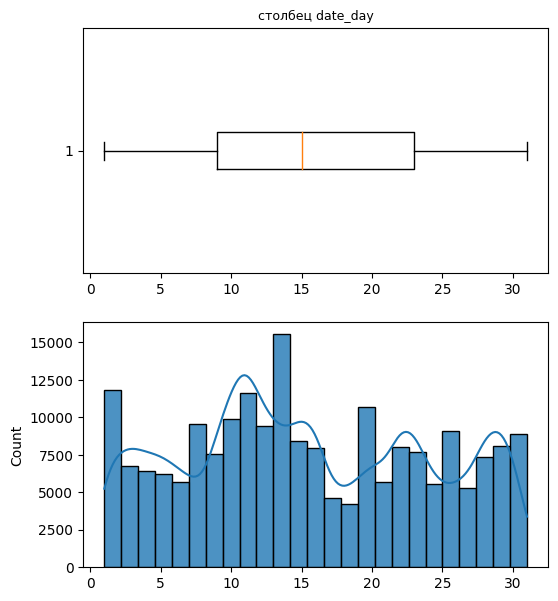

'⬇-------- Следующий признак: date_weekday --------⬇'

"фильтр = ''"

count    202208.000000
mean          3.189013
std           1.717311
min           0.000000
25%           2.000000
50%           3.000000
75%           4.000000
max           6.000000
Name: date_weekday, dtype: float64

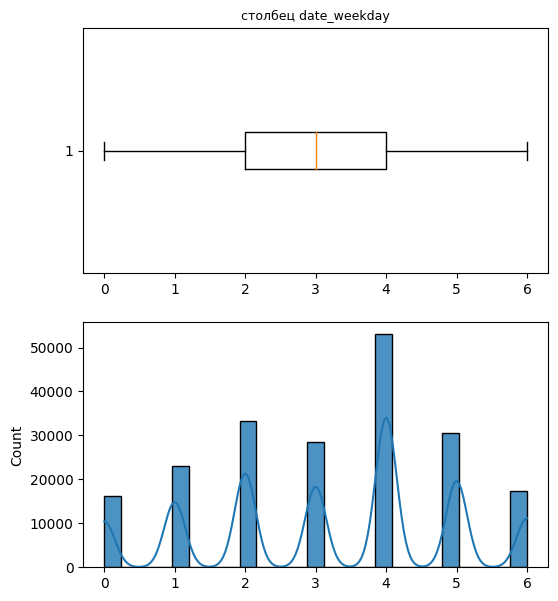

'⬇-------- Следующий признак: date_hour --------⬇'

c:\Users\Papa\.conda\envs\practicum\lib\site-packages\seaborn\distributions.py:306: UserWarning: Dataset has 0 variance; skipping density estimate.
  warnings.warn(msg, UserWarning)


"фильтр = ''"

count    202208.0
mean          0.0
std           0.0
min           0.0
25%           0.0
50%           0.0
75%           0.0
max           0.0
Name: date_hour, dtype: float64

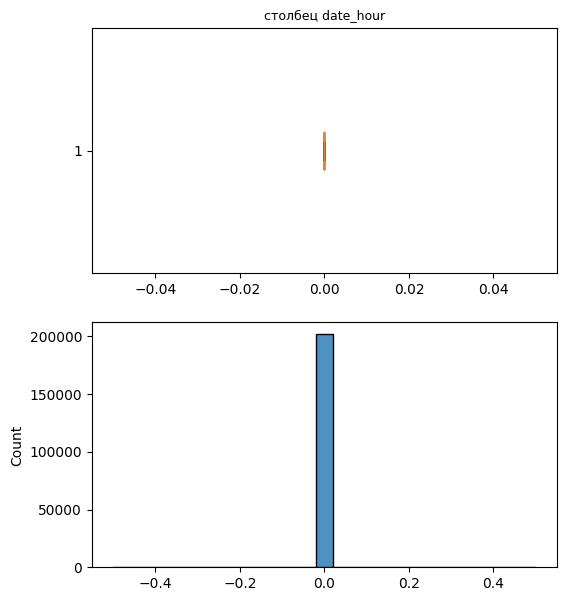

'⬇-------- Следующий признак: cat1 --------⬇'

"фильтр = ''"

count    202208.000000
mean       1545.892714
std        2514.452645
min           0.000000
25%           4.000000
50%           4.000000
75%        5562.000000
max        6060.000000
Name: cat1, dtype: float64

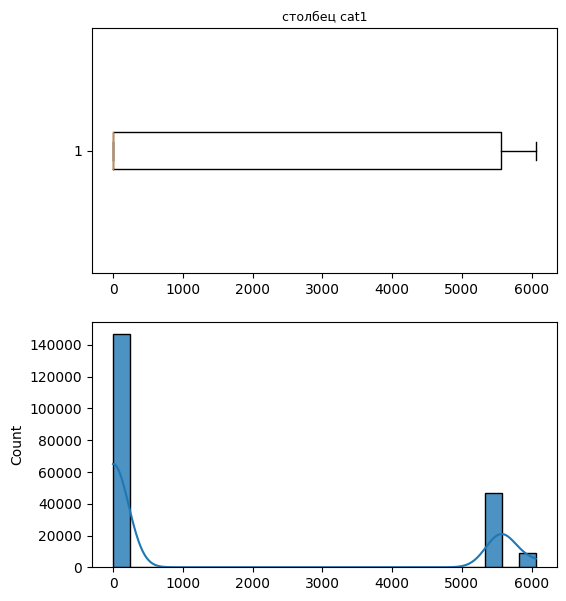

'⬇-------- Следующий признак: cat2 --------⬇'

"фильтр = ''"

count    202208.000000
mean       1635.220446
std        2524.485877
min           0.000000
25%          28.000000
50%          28.000000
75%        5558.000000
max        6059.000000
Name: cat2, dtype: float64

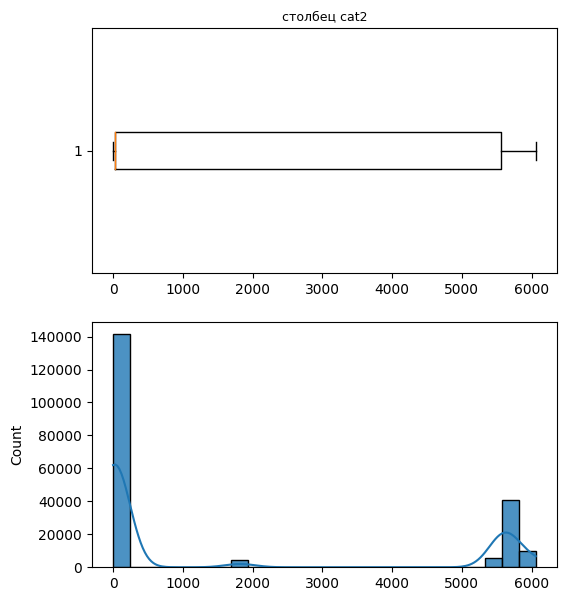

'⬇-------- Следующий признак: cat3 --------⬇'

"фильтр = ''"

count    202208.000000
mean       1778.901136
std        2467.825795
min           0.000000
25%         156.000000
50%         274.000000
75%        5549.000000
max        6309.000000
Name: cat3, dtype: float64

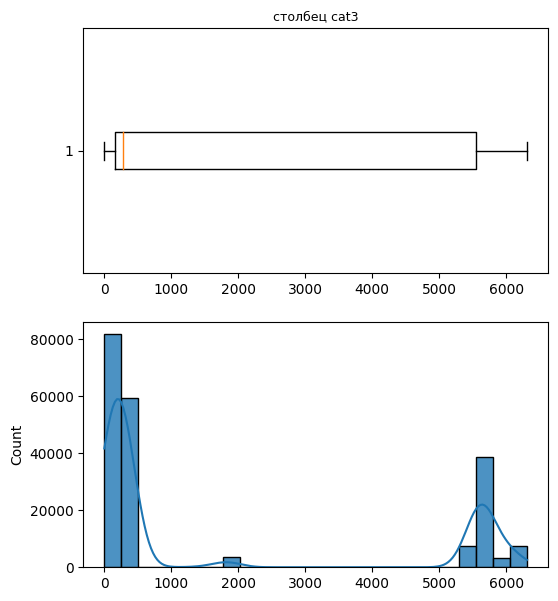

'⬇-------- Следующий признак: cat4 --------⬇'

"фильтр = ''"

count    202208.000000
mean        883.531878
std        1066.742346
min           0.000000
25%         432.000000
50%         555.000000
75%         732.000000
max        6323.000000
Name: cat4, dtype: float64

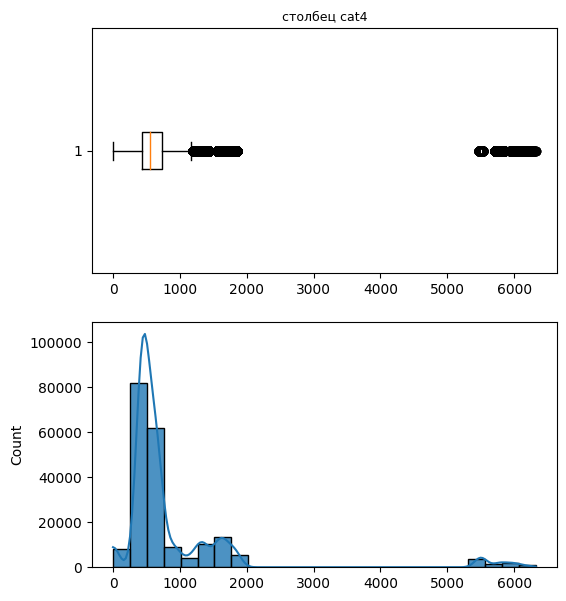

'⬇-------- Следующий признак: cat5 --------⬇'

"фильтр = ''"

count    202208.000000
mean          1.196323
std          23.606233
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max         467.000000
Name: cat5, dtype: float64

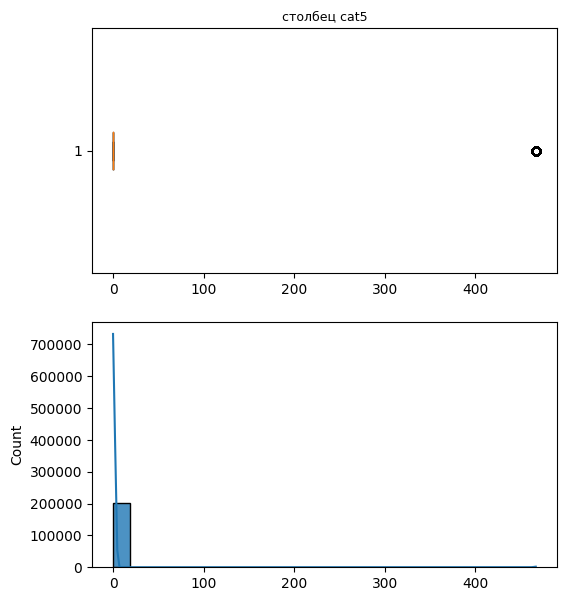

In [33]:
do_eda(df_apparel_purchases)

'⬇-------- столбец message_id --------⬇'

Index(['1515915625489095763-6251-6311b13a4cf78',
       '1515915625490241385-6973-633edf70723d8',
       '1515915625490540122-6973-633edf707840d',
       '1515915625629509124-6374-63241bd1541d5',
       '1515915625488270582-3433-6232d6007e929',
       '1515915625490539613-6973-633edf70783e3',
       '1515915625491074240-10507-63ff04f77c9cb',
       '1515915625468222486-5515-62d79a05031f0',
       '1515915625490334876-4981-62ac2db92d569',
       '1515915625572510657-4679-6297223c95479'],
      dtype='object')

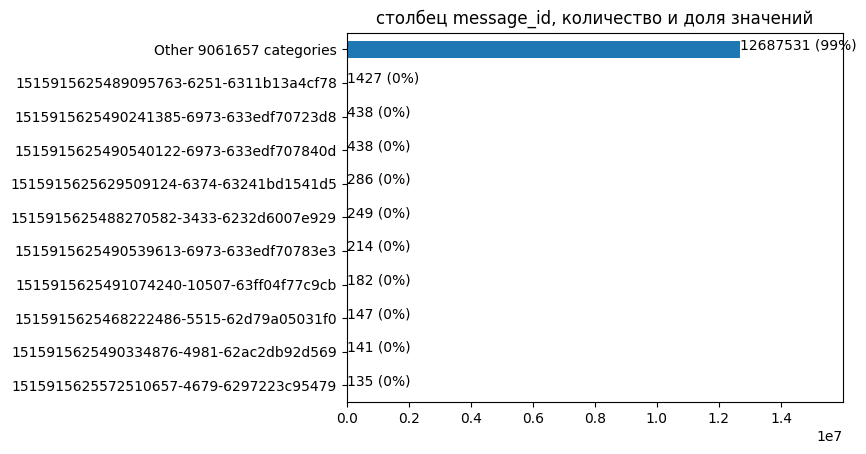

'⬇-------- столбец event --------⬇'

Index(['send', 'open', 'click', 'purchase', 'hard_bounce', 'soft_bounce',
       'unsubscribe', 'hbq_spam', 'complain', 'subscribe'],
      dtype='object')

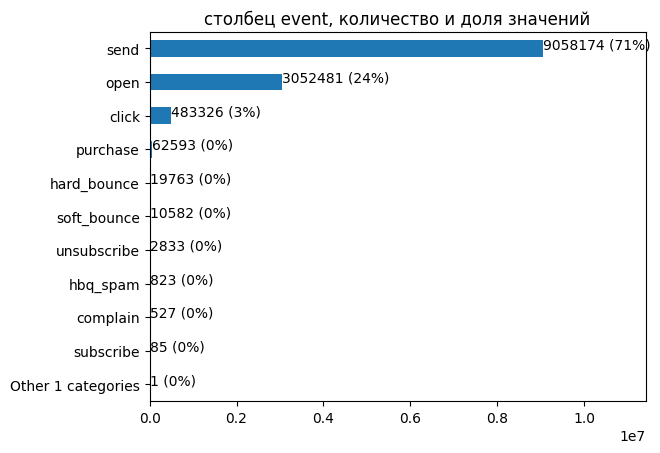

'⬇-------- столбец channel --------⬇'

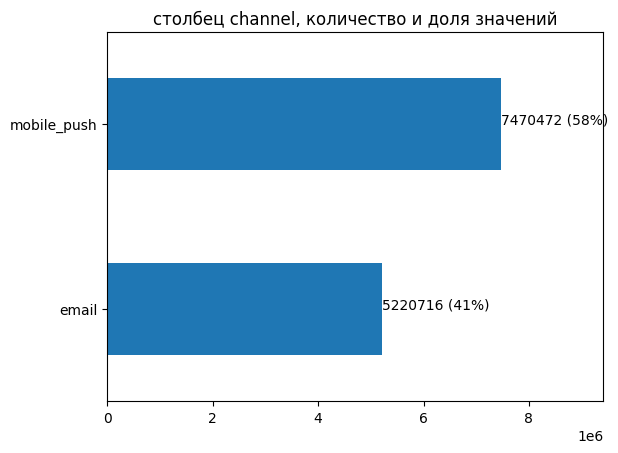

'⬇-------- Следующий признак: bulk_campaign_id --------⬇'

"фильтр = ''"

count    1.269119e+07
mean     1.159768e+04
std      3.262181e+03
min      5.480000e+02
25%      8.746000e+03
50%      1.351600e+04
75%      1.415800e+04
max      1.465700e+04
Name: bulk_campaign_id, dtype: float64

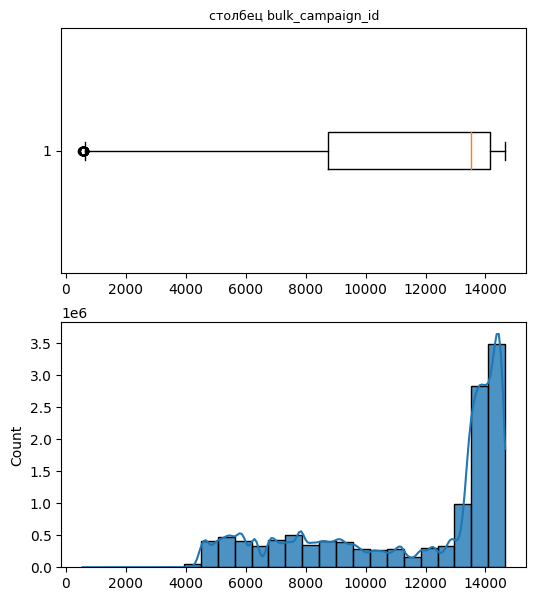

'⬇-------- Следующий признак: client_id --------⬇'

"фильтр = ''"

count    1.269119e+07
mean     1.515916e+18
std      1.329008e+08
min      1.515916e+18
25%      1.515916e+18
50%      1.515916e+18
75%      1.515916e+18
max      1.515916e+18
Name: client_id, dtype: float64

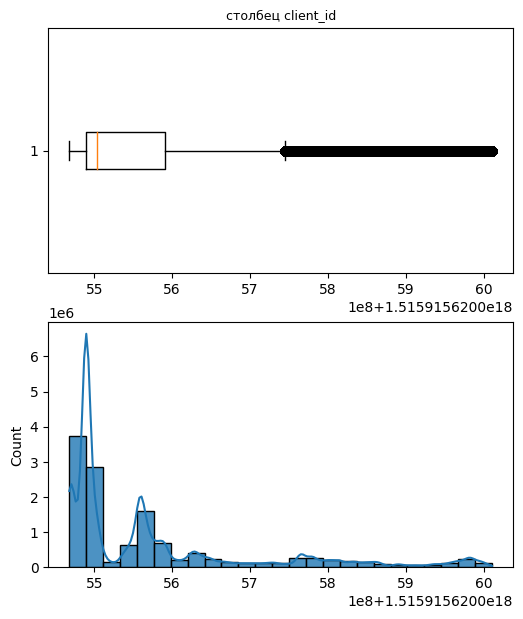

'⬇-------- Следующий признак: date_year --------⬇'

"фильтр = ''"

count    1.269119e+07
mean     2.022855e+03
std      6.146481e-01
min      2.022000e+03
25%      2.022000e+03
50%      2.023000e+03
75%      2.023000e+03
max      2.024000e+03
Name: date_year, dtype: float64

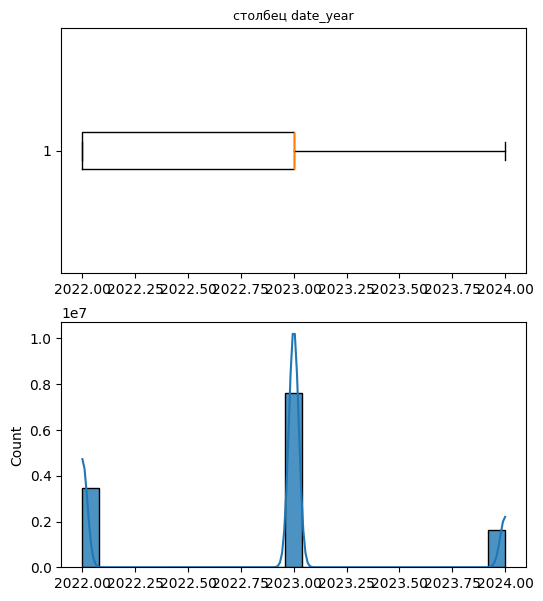

'⬇-------- Следующий признак: date_month --------⬇'

"фильтр = ''"

count    1.269119e+07
mean     7.355943e+00
std      3.721032e+00
min      1.000000e+00
25%      5.000000e+00
50%      8.000000e+00
75%      1.100000e+01
max      1.200000e+01
Name: date_month, dtype: float64

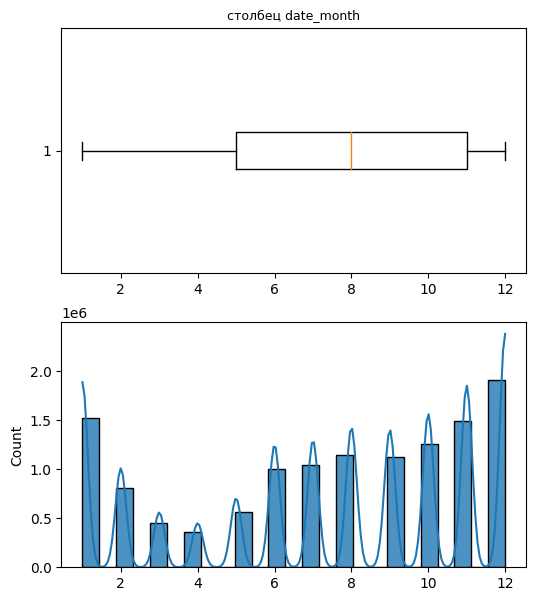

'⬇-------- Следующий признак: date_day --------⬇'

"фильтр = ''"

count    1.269119e+07
mean     1.612233e+01
std      8.755090e+00
min      1.000000e+00
25%      9.000000e+00
50%      1.600000e+01
75%      2.400000e+01
max      3.100000e+01
Name: date_day, dtype: float64

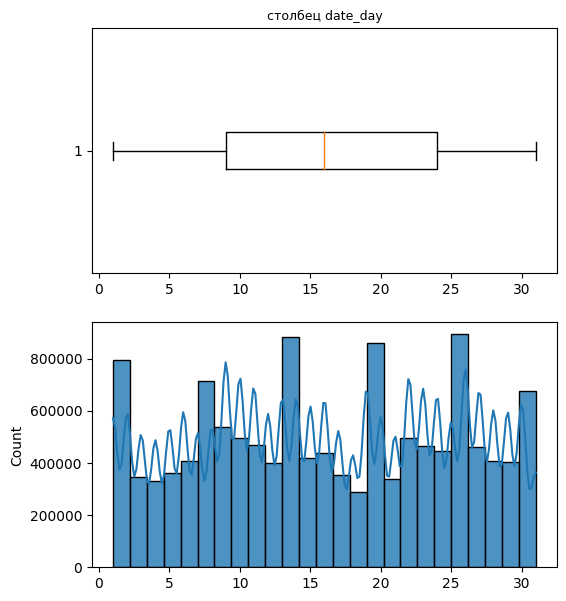

'⬇-------- Следующий признак: date_weekday --------⬇'

"фильтр = ''"

count    1.269119e+07
mean     2.568604e+00
std      1.631744e+00
min      0.000000e+00
25%      1.000000e+00
50%      3.000000e+00
75%      4.000000e+00
max      6.000000e+00
Name: date_weekday, dtype: float64

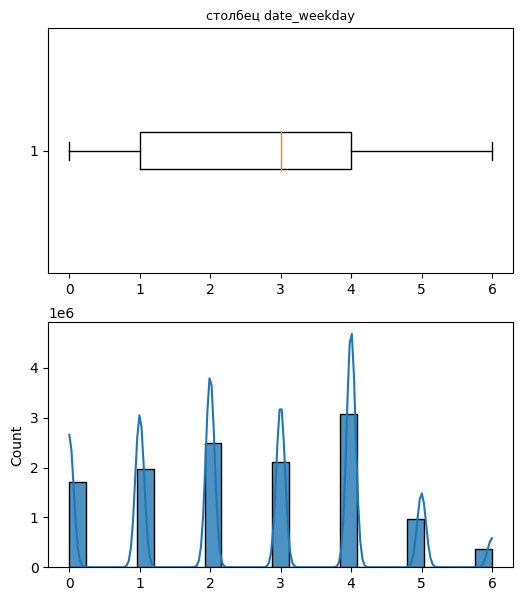

'⬇-------- Следующий признак: date_hour --------⬇'

c:\Users\Papa\.conda\envs\practicum\lib\site-packages\seaborn\distributions.py:306: UserWarning: Dataset has 0 variance; skipping density estimate.
  warnings.warn(msg, UserWarning)


"фильтр = ''"

count    12691188.0
mean            0.0
std             0.0
min             0.0
25%             0.0
50%             0.0
75%             0.0
max             0.0
Name: date_hour, dtype: float64

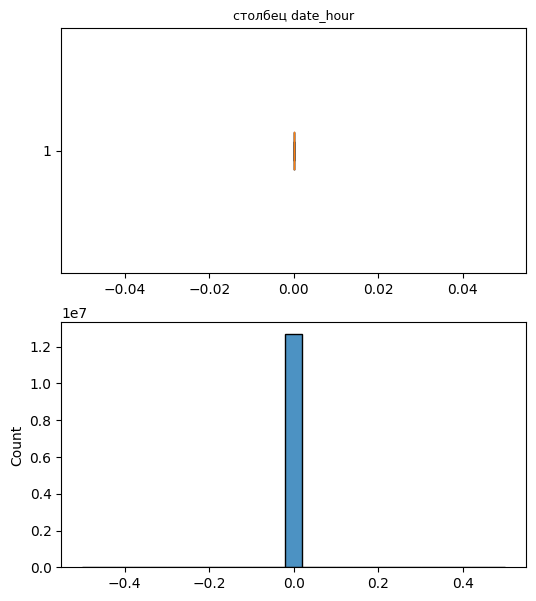

'⬇-------- Следующий признак: created_at_year --------⬇'

"фильтр = ''"

count    1.269119e+07
mean     2.022855e+03
std      6.146481e-01
min      2.022000e+03
25%      2.022000e+03
50%      2.023000e+03
75%      2.023000e+03
max      2.024000e+03
Name: created_at_year, dtype: float64

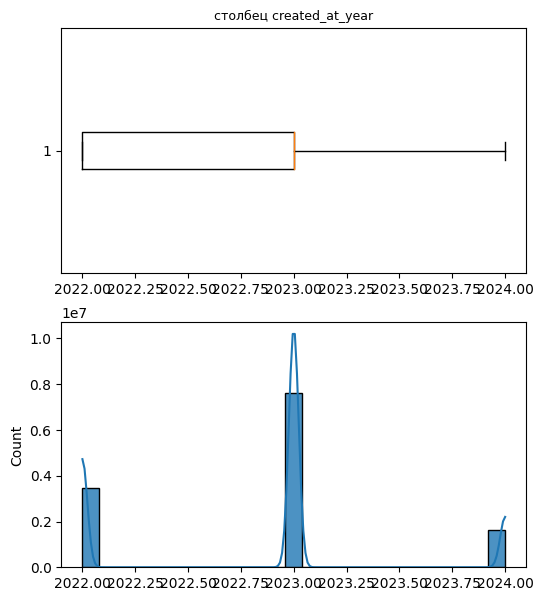

'⬇-------- Следующий признак: created_at_month --------⬇'

"фильтр = ''"

count    1.269119e+07
mean     7.355943e+00
std      3.721032e+00
min      1.000000e+00
25%      5.000000e+00
50%      8.000000e+00
75%      1.100000e+01
max      1.200000e+01
Name: created_at_month, dtype: float64

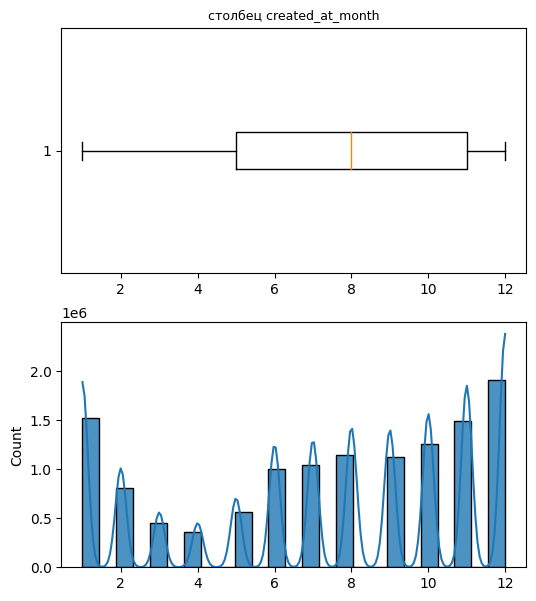

'⬇-------- Следующий признак: created_at_day --------⬇'

"фильтр = ''"

count    1.269119e+07
mean     1.612233e+01
std      8.755090e+00
min      1.000000e+00
25%      9.000000e+00
50%      1.600000e+01
75%      2.400000e+01
max      3.100000e+01
Name: created_at_day, dtype: float64

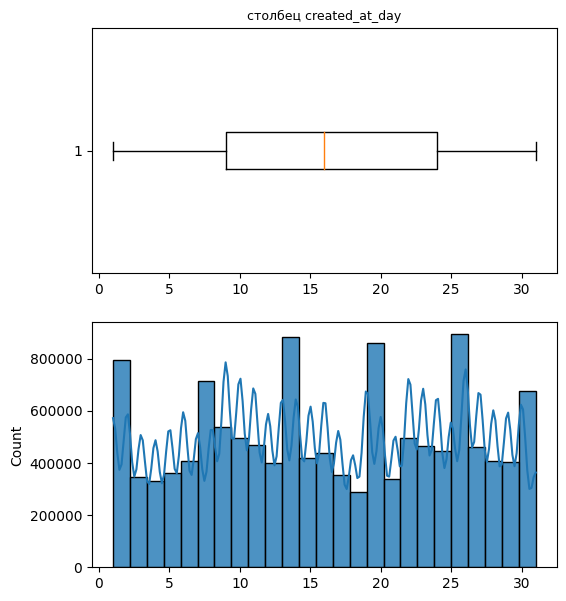

'⬇-------- Следующий признак: created_at_weekday --------⬇'

"фильтр = ''"

count    1.269119e+07
mean     2.568604e+00
std      1.631744e+00
min      0.000000e+00
25%      1.000000e+00
50%      3.000000e+00
75%      4.000000e+00
max      6.000000e+00
Name: created_at_weekday, dtype: float64

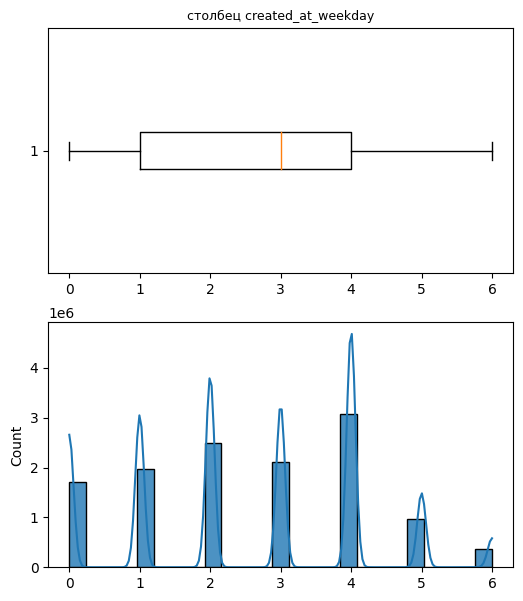

'⬇-------- Следующий признак: created_at_hour --------⬇'

"фильтр = ''"

count    1.269119e+07
mean     1.073610e+01
std      3.501076e+00
min      0.000000e+00
25%      8.000000e+00
50%      1.000000e+01
75%      1.300000e+01
max      2.300000e+01
Name: created_at_hour, dtype: float64

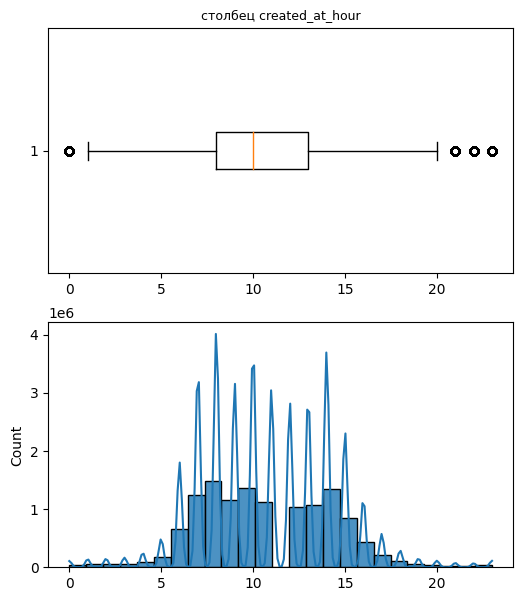

In [34]:
do_eda(df_apparel_messages)

'⬇-------- Следующий признак: bulk_campaign_id --------⬇'

"фильтр = ''"

count    131072.000000
mean       8416.743378
std        4877.369306
min         548.000000
25%        4116.000000
50%        7477.000000
75%       13732.000000
max       15150.000000
Name: bulk_campaign_id, dtype: float64

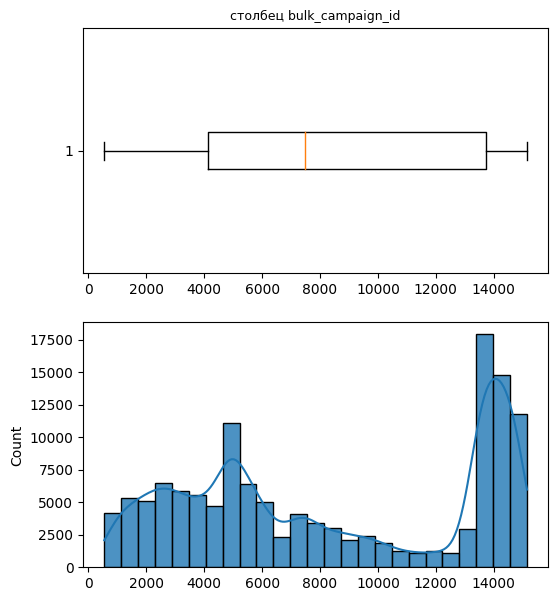

'⬇-------- Следующий признак: count_click --------⬇'

"фильтр = ''"

count    131072.000000
mean         90.982971
std        1275.503564
min           0.000000
25%           0.000000
50%           0.000000
75%           2.000000
max      128453.000000
Name: count_click, dtype: float64

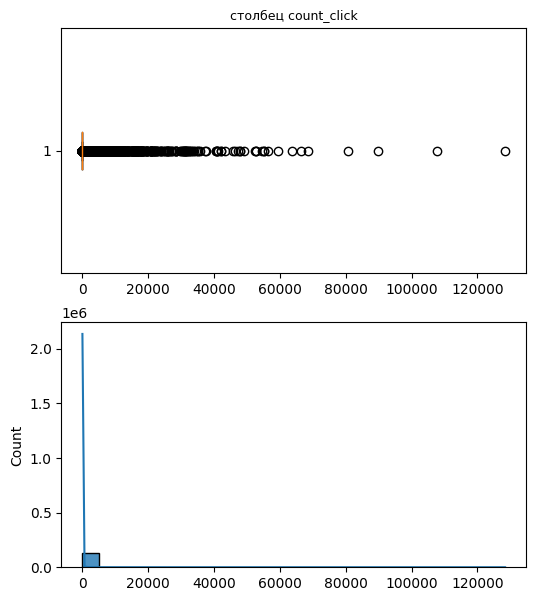

'⬇-------- Следующий признак: count_complain --------⬇'

"фильтр = ''"

count    131072.000000
mean          0.932655
std          30.198326
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max        5160.000000
Name: count_complain, dtype: float64

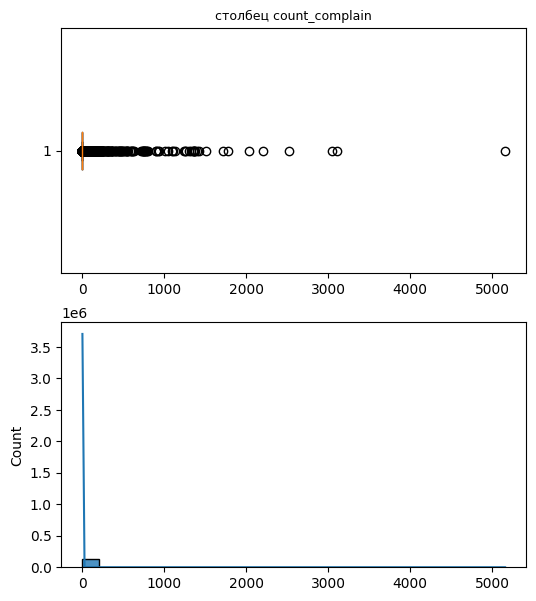

'⬇-------- Следующий признак: count_hard_bounce --------⬇'

"фильтр = ''"

count    131072.000000
mean         78.473434
std        1961.317826
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max      287404.000000
Name: count_hard_bounce, dtype: float64

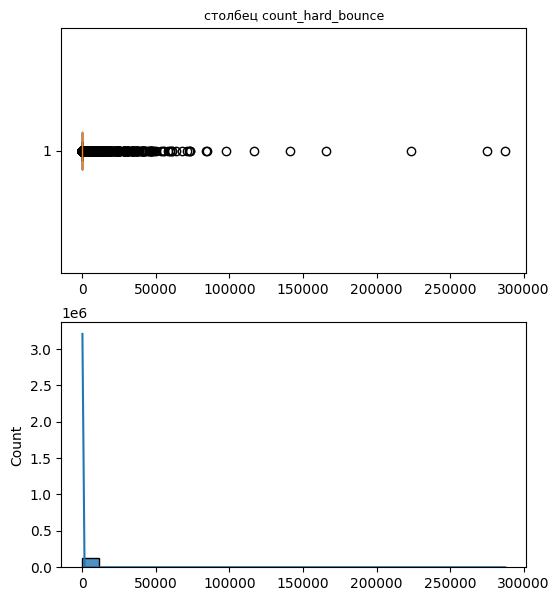

'⬇-------- Следующий признак: count_open --------⬇'

"фильтр = ''"

count    1.310720e+05
mean     3.771091e+03
std      6.516067e+04
min      0.000000e+00
25%      1.000000e+00
50%      6.000000e+00
75%      3.000000e+01
max      5.076151e+06
Name: count_open, dtype: float64

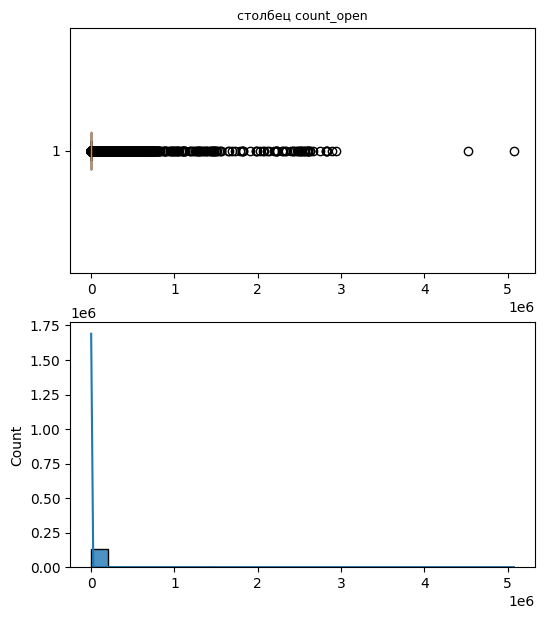

'⬇-------- Следующий признак: count_purchase --------⬇'

"фильтр = ''"

count    131072.000000
mean          0.577927
std           9.107040
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max        1077.000000
Name: count_purchase, dtype: float64

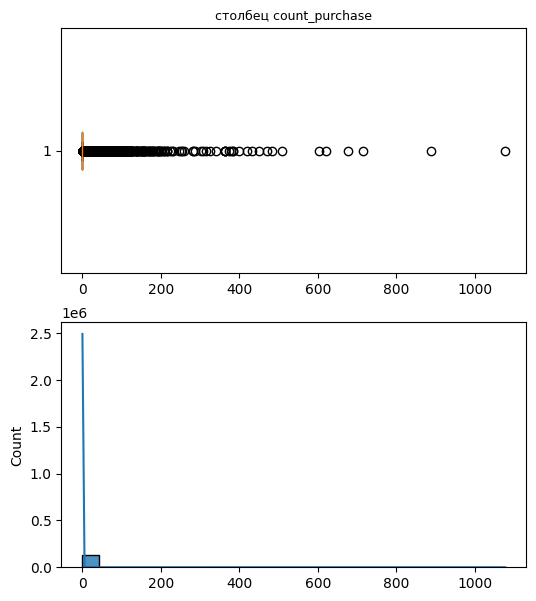

'⬇-------- Следующий признак: count_send --------⬇'

"фильтр = ''"

count    1.310720e+05
mean     1.163414e+04
std      1.757095e+05
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      1.154351e+07
Name: count_send, dtype: float64

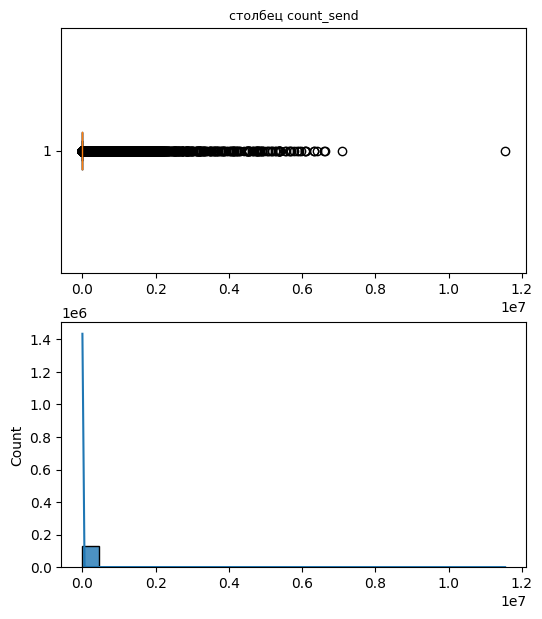

'⬇-------- Следующий признак: count_soft_bounce --------⬇'

"фильтр = ''"

count    131072.000000
mean         27.807312
std         736.944714
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max       76284.000000
Name: count_soft_bounce, dtype: float64

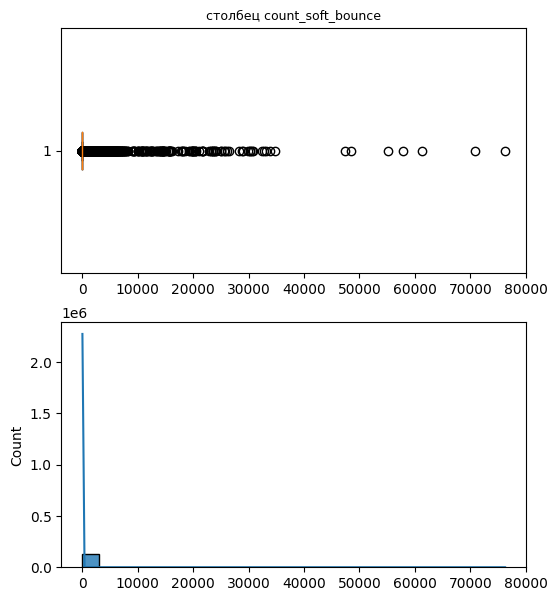

'⬇-------- Следующий признак: count_subscribe --------⬇'

"фильтр = ''"

count    131072.000000
mean          0.140518
std           2.072777
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max         189.000000
Name: count_subscribe, dtype: float64

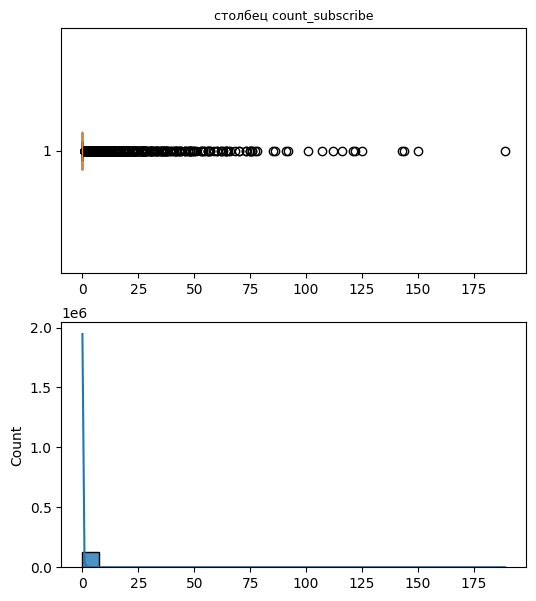

'⬇-------- Следующий признак: count_unsubscribe --------⬇'

"фильтр = ''"

count    131072.000000
mean          6.362679
std          79.172069
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max        9089.000000
Name: count_unsubscribe, dtype: float64

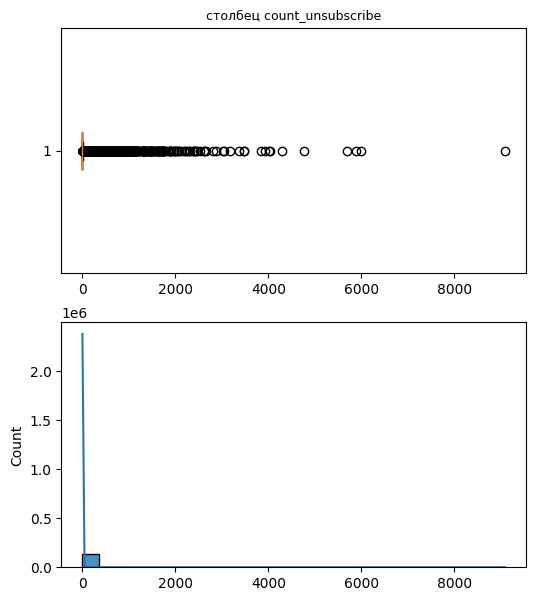

'⬇-------- Следующий признак: nunique_click --------⬇'

"фильтр = ''"

count    131072.000000
mean         74.276016
std        1004.271405
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max       75899.000000
Name: nunique_click, dtype: float64

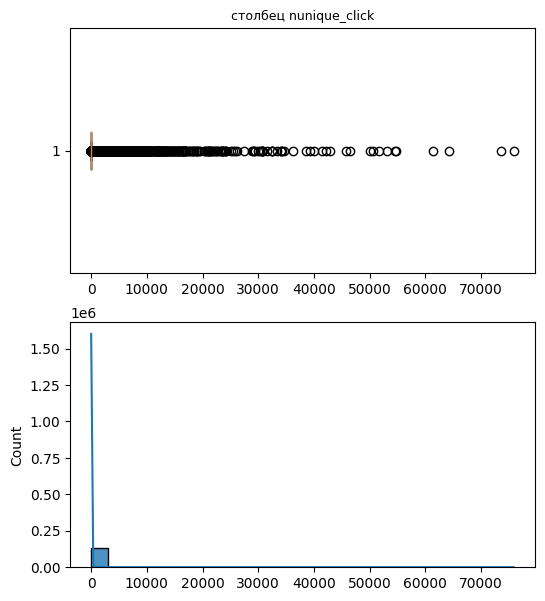

'⬇-------- Следующий признак: nunique_complain --------⬇'

"фильтр = ''"

count    131072.000000
mean          0.921326
std          29.715170
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max        5043.000000
Name: nunique_complain, dtype: float64

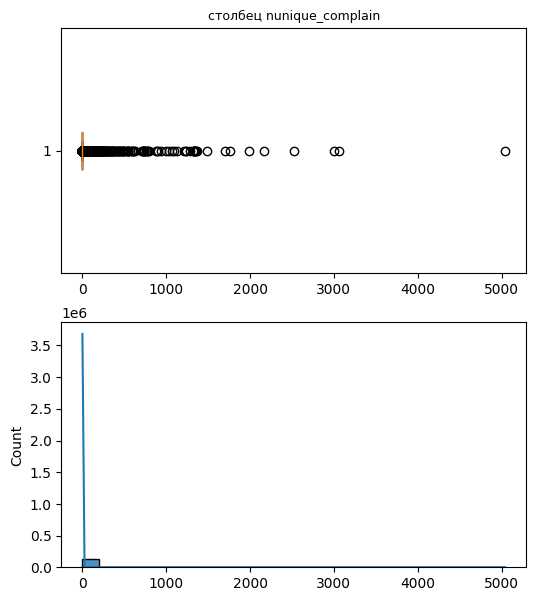

'⬇-------- Следующий признак: nunique_hard_bounce --------⬇'

"фильтр = ''"

count    131072.000000
mean         77.398689
std        1913.395511
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max      287341.000000
Name: nunique_hard_bounce, dtype: float64

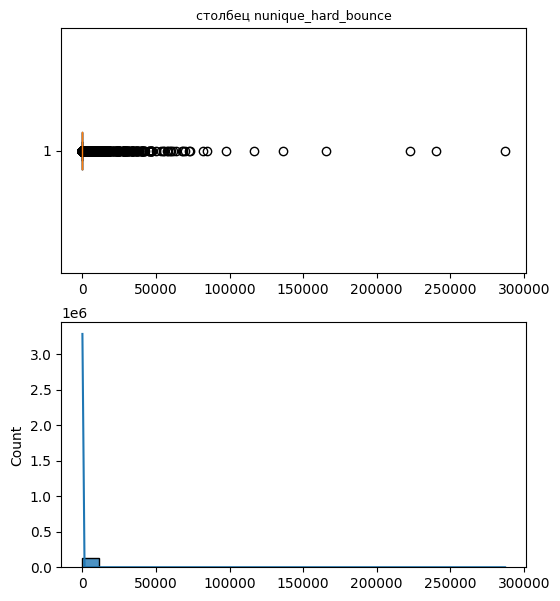

'⬇-------- Следующий признак: nunique_open --------⬇'

"фильтр = ''"

count    1.310720e+05
mean     3.683000e+03
std      6.258647e+04
min      0.000000e+00
25%      1.000000e+00
50%      6.000000e+00
75%      3.000000e+01
max      2.922440e+06
Name: nunique_open, dtype: float64

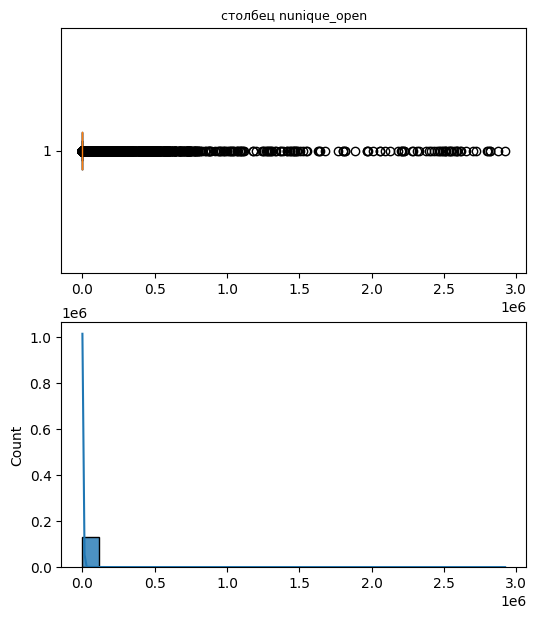

'⬇-------- Следующий признак: nunique_purchase --------⬇'

"фильтр = ''"

count    131072.000000
mean          0.465103
std           7.126368
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max         779.000000
Name: nunique_purchase, dtype: float64

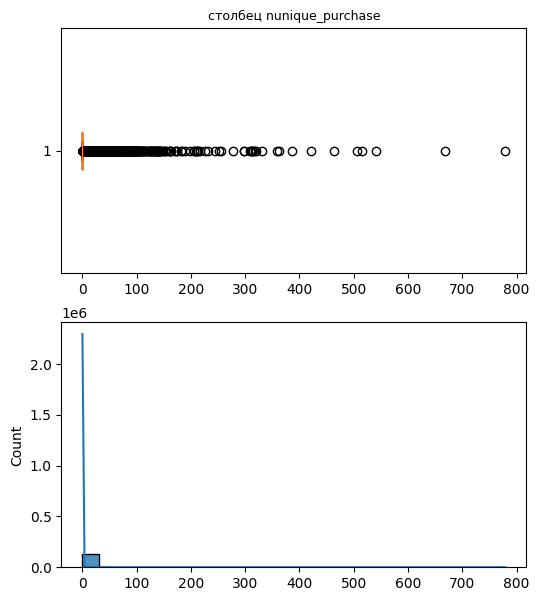

'⬇-------- Следующий признак: nunique_send --------⬇'

"фильтр = ''"

count    1.310720e+05
mean     1.153716e+04
std      1.727005e+05
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      7.094600e+06
Name: nunique_send, dtype: float64

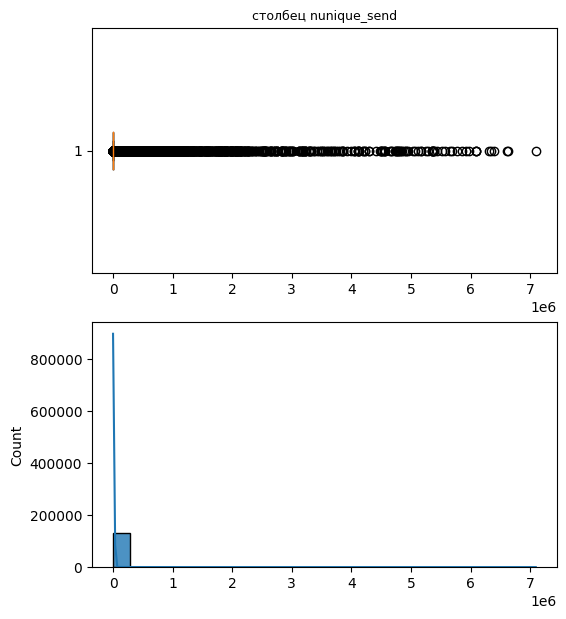

'⬇-------- Следующий признак: nunique_soft_bounce --------⬇'

"фильтр = ''"

count    131072.000000
mean         27.573799
std         734.050700
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max       76281.000000
Name: nunique_soft_bounce, dtype: float64

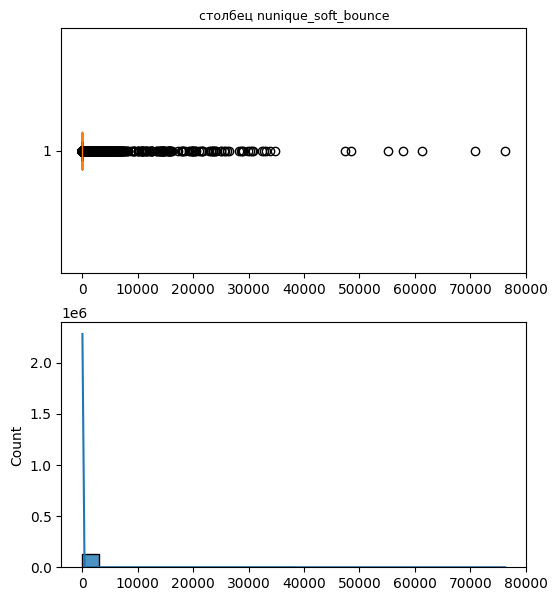

'⬇-------- Следующий признак: nunique_subscribe --------⬇'

"фильтр = ''"

count    131072.000000
mean          0.134125
std           1.976439
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max         177.000000
Name: nunique_subscribe, dtype: float64

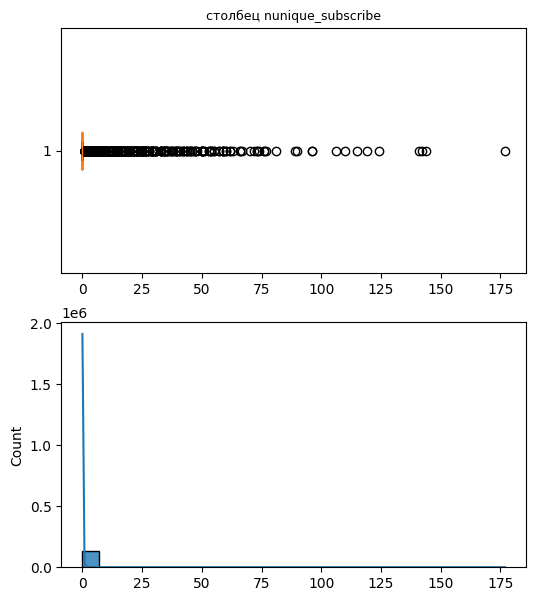

'⬇-------- Следующий признак: nunique_unsubscribe --------⬇'

"фильтр = ''"

count    131072.000000
mean          5.960602
std          73.284148
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max        8299.000000
Name: nunique_unsubscribe, dtype: float64

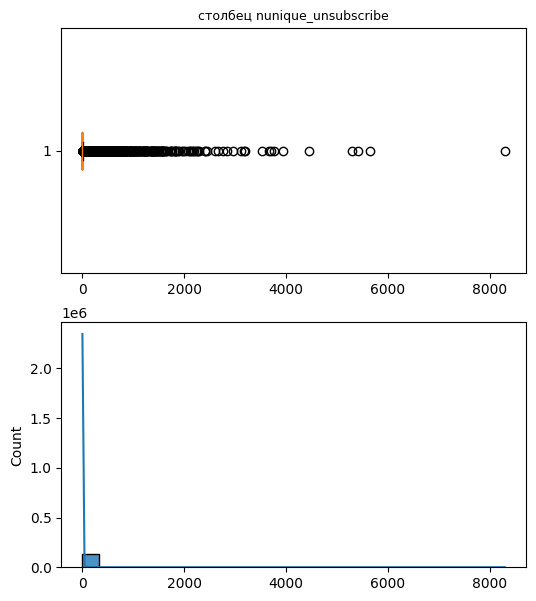

'⬇-------- Следующий признак: count_hbq_spam --------⬇'

"фильтр = ''"

count    131072.000000
mean          0.810364
std         183.298579
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max       63920.000000
Name: count_hbq_spam, dtype: float64

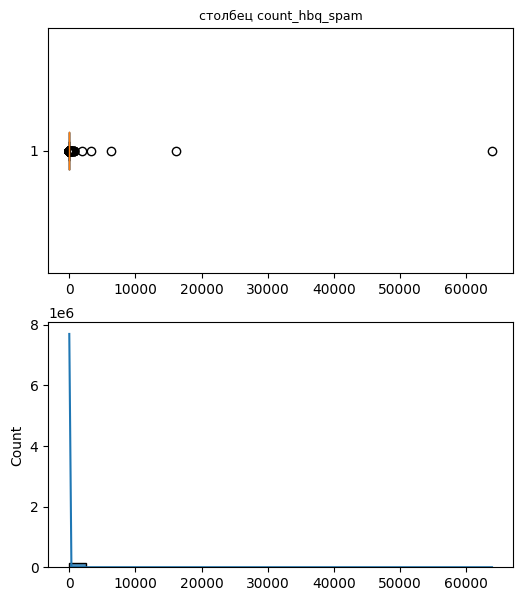

'⬇-------- Следующий признак: nunique_hbq_spam --------⬇'

"фильтр = ''"

count    131072.000000
mean          0.809799
std         183.298245
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max       63920.000000
Name: nunique_hbq_spam, dtype: float64

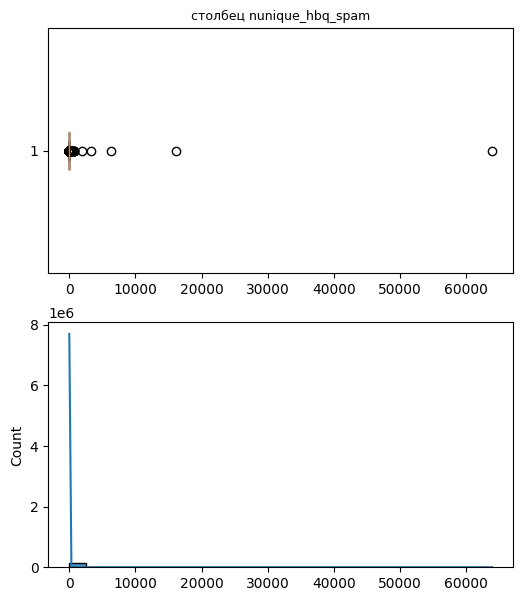

'⬇-------- Следующий признак: count_close --------⬇'

"фильтр = ''"

count    131072.000000
mean          0.000008
std           0.002762
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           1.000000
Name: count_close, dtype: float64

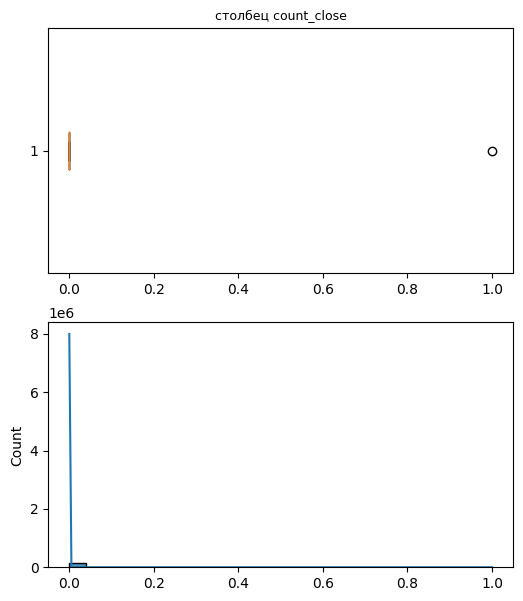

'⬇-------- Следующий признак: nunique_close --------⬇'

"фильтр = ''"

count    131072.000000
mean          0.000008
std           0.002762
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           1.000000
Name: nunique_close, dtype: float64

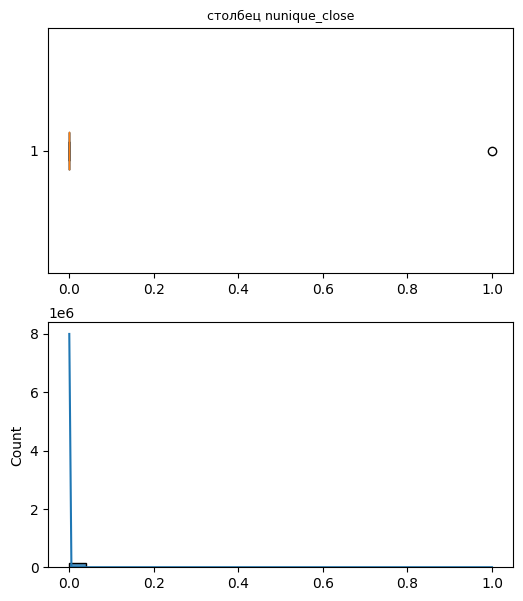

'⬇-------- Следующий признак: date_year --------⬇'

"фильтр = ''"

count    131072.000000
mean       2022.886688
std           0.760484
min        2022.000000
25%        2022.000000
50%        2023.000000
75%        2023.000000
max        2024.000000
Name: date_year, dtype: float64

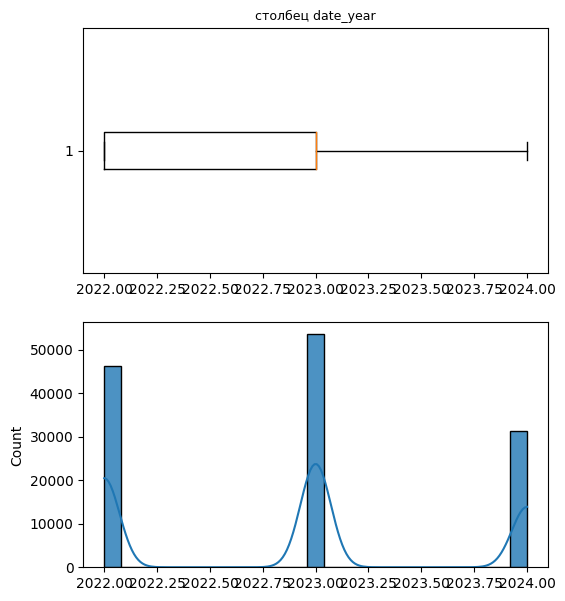

'⬇-------- Следующий признак: date_month --------⬇'

"фильтр = ''"

count    131072.000000
mean          6.195587
std           3.644664
min           1.000000
25%           3.000000
50%           6.000000
75%          10.000000
max          12.000000
Name: date_month, dtype: float64

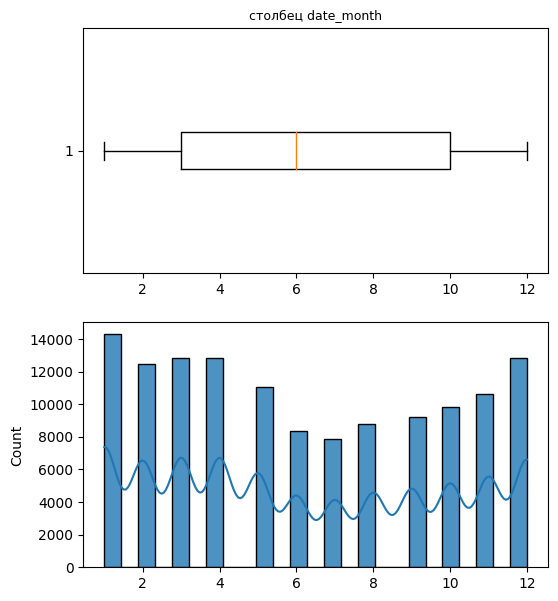

'⬇-------- Следующий признак: date_day --------⬇'

"фильтр = ''"

count    131072.000000
mean         15.722099
std           8.843386
min           1.000000
25%           8.000000
50%          16.000000
75%          23.000000
max          31.000000
Name: date_day, dtype: float64

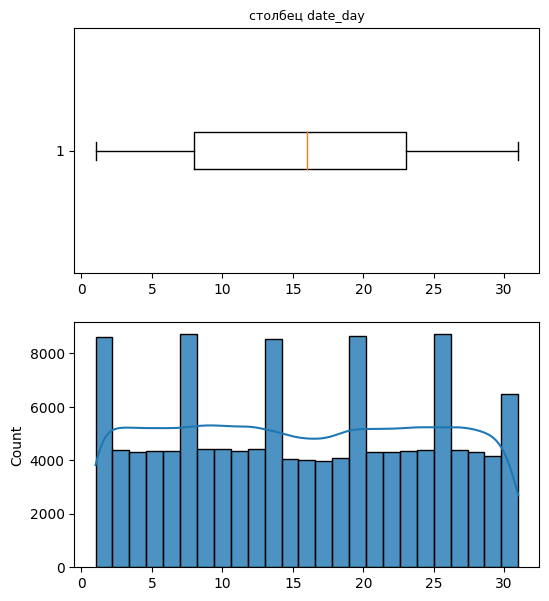

'⬇-------- Следующий признак: date_weekday --------⬇'

"фильтр = ''"

count    131072.000000
mean          2.973129
std           1.984597
min           0.000000
25%           1.000000
50%           3.000000
75%           5.000000
max           6.000000
Name: date_weekday, dtype: float64

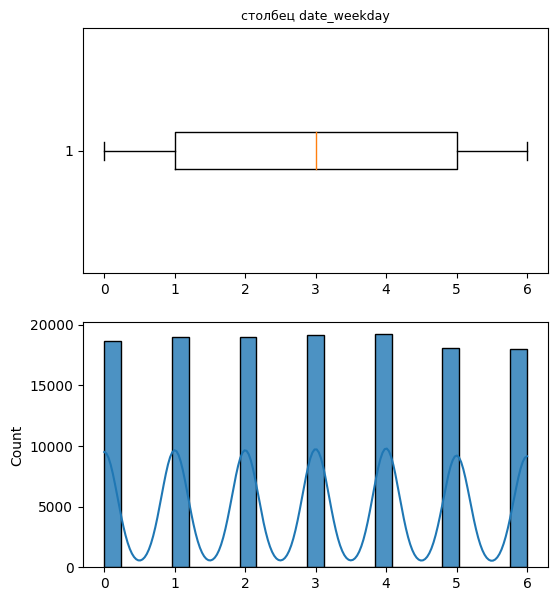

'⬇-------- Следующий признак: date_hour --------⬇'

c:\Users\Papa\.conda\envs\practicum\lib\site-packages\seaborn\distributions.py:306: UserWarning: Dataset has 0 variance; skipping density estimate.
  warnings.warn(msg, UserWarning)


"фильтр = ''"

count    131072.0
mean          0.0
std           0.0
min           0.0
25%           0.0
50%           0.0
75%           0.0
max           0.0
Name: date_hour, dtype: float64

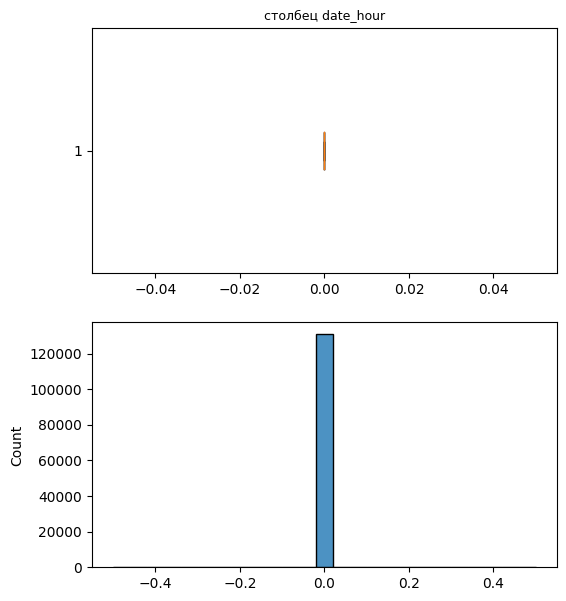

In [35]:
do_eda(df_full_events)

'⬇-------- Следующий признак: bulk_campaign_id --------⬇'

"фильтр = ''"

count    131072.000000
mean       8416.743378
std        4877.369306
min         548.000000
25%        4116.000000
50%        7477.000000
75%       13732.000000
max       15150.000000
Name: bulk_campaign_id, dtype: float64

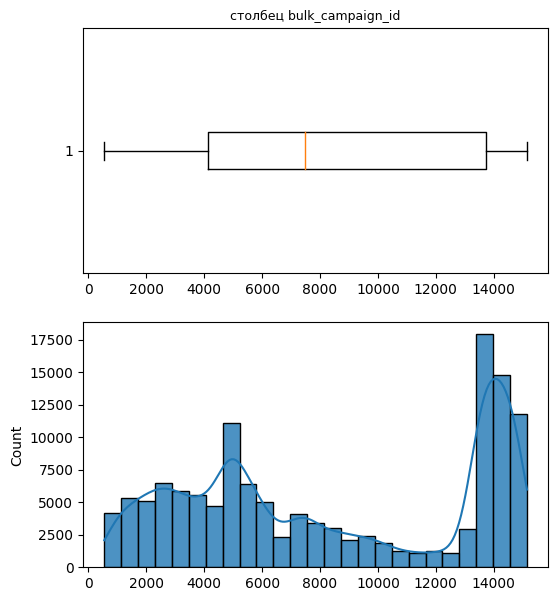

'⬇-------- Следующий признак: count_click_email --------⬇'

"фильтр = ''"

count    131072.000000
mean         41.582169
std         745.484035
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max       59365.000000
Name: count_click_email, dtype: float64

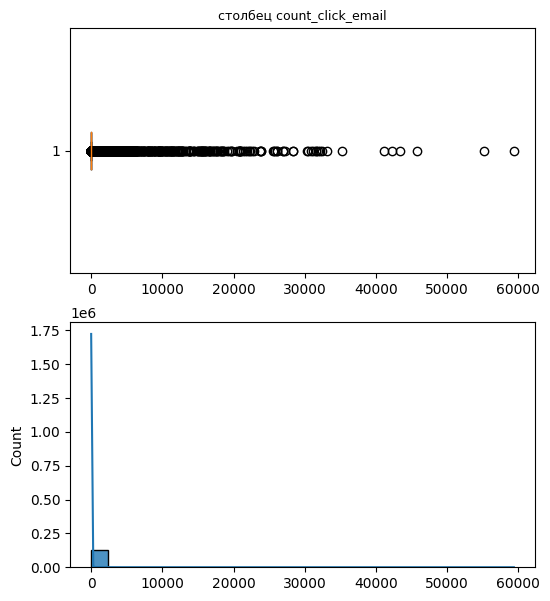

'⬇-------- Следующий признак: count_click_mobile_push --------⬇'

"фильтр = ''"

count    131072.000000
mean         49.400803
std        1036.952898
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max      128453.000000
Name: count_click_mobile_push, dtype: float64

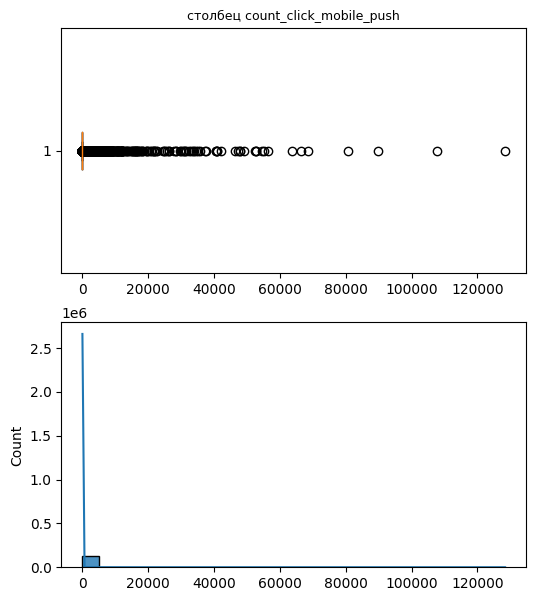

'⬇-------- Следующий признак: count_open_email --------⬇'

"фильтр = ''"

count    1.310720e+05
mean     4.237060e+02
std      9.753384e+03
min      0.000000e+00
25%      1.000000e+00
50%      5.000000e+00
75%      2.300000e+01
max      2.597015e+06
Name: count_open_email, dtype: float64

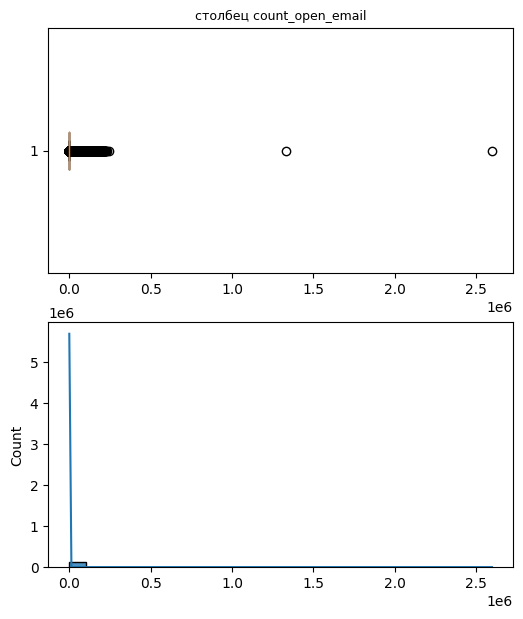

'⬇-------- Следующий признак: count_open_mobile_push --------⬇'

"фильтр = ''"

count    1.310720e+05
mean     3.347385e+03
std      6.444859e+04
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      5.076151e+06
Name: count_open_mobile_push, dtype: float64

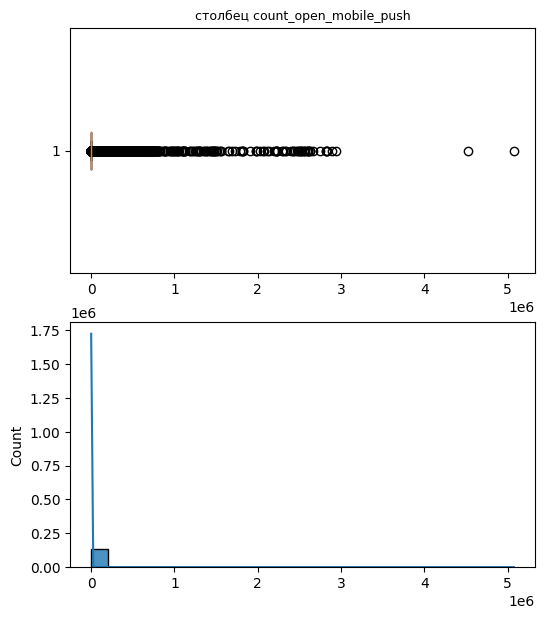

'⬇-------- Следующий признак: count_purchase_email --------⬇'

"фильтр = ''"

count    131072.000000
mean          0.357483
std           8.287483
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max        1077.000000
Name: count_purchase_email, dtype: float64

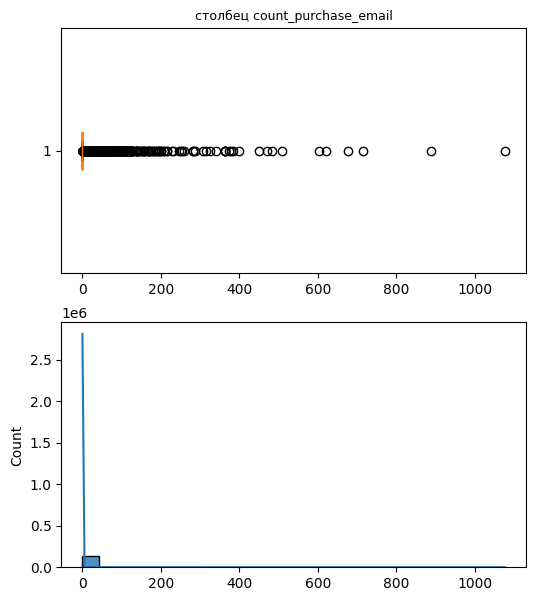

'⬇-------- Следующий признак: count_purchase_mobile_push --------⬇'

"фильтр = ''"

count    131072.000000
mean          0.220444
std           3.796500
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max         431.000000
Name: count_purchase_mobile_push, dtype: float64

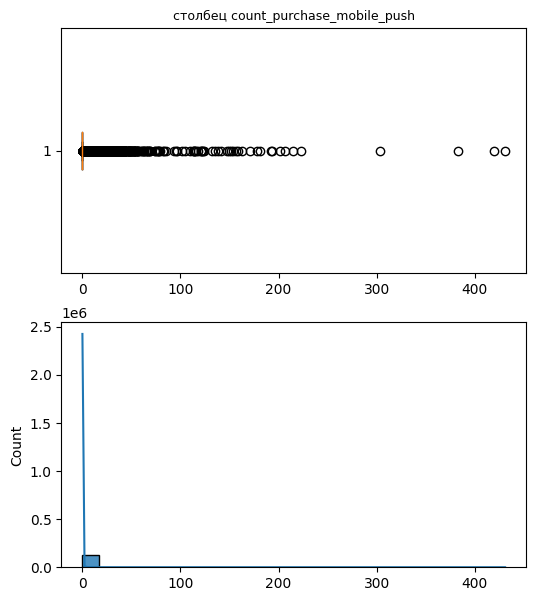

'⬇-------- Следующий признак: count_soft_bounce_email --------⬇'

"фильтр = ''"

count    131072.000000
mean         24.474823
std         727.069387
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max       76284.000000
Name: count_soft_bounce_email, dtype: float64

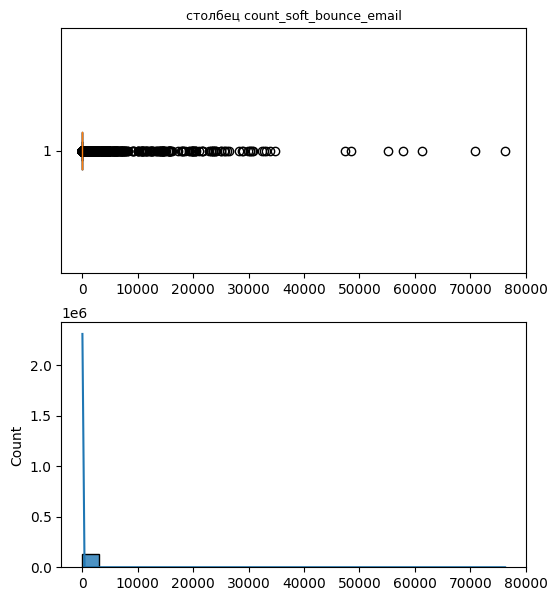

'⬇-------- Следующий признак: count_subscribe_email --------⬇'

"фильтр = ''"

count    131072.000000
mean          0.140518
std           2.072777
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max         189.000000
Name: count_subscribe_email, dtype: float64

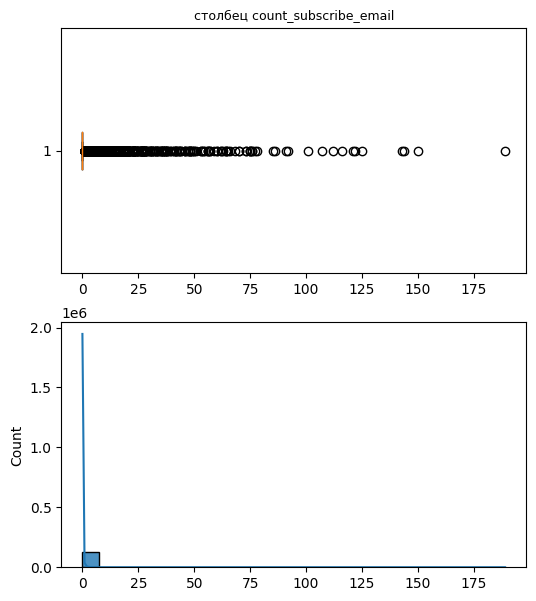

'⬇-------- Следующий признак: count_unsubscribe_email --------⬇'

"фильтр = ''"

count    131072.000000
mean          6.362679
std          79.172069
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max        9089.000000
Name: count_unsubscribe_email, dtype: float64

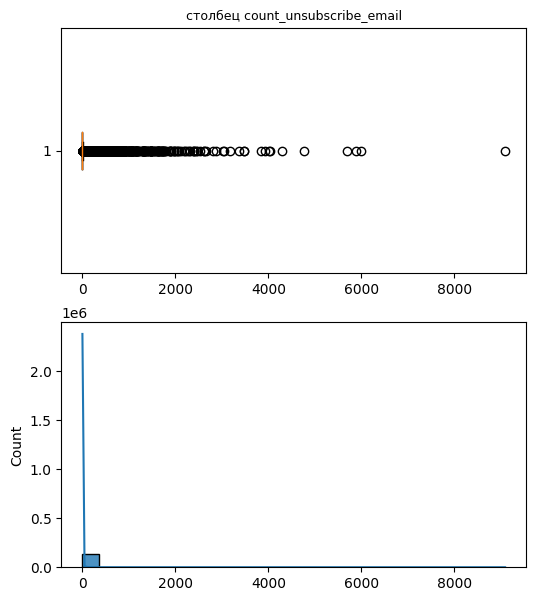

'⬇-------- Следующий признак: nunique_click_email --------⬇'

"фильтр = ''"

count    131072.000000
mean         31.396263
std         562.883309
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max       45718.000000
Name: nunique_click_email, dtype: float64

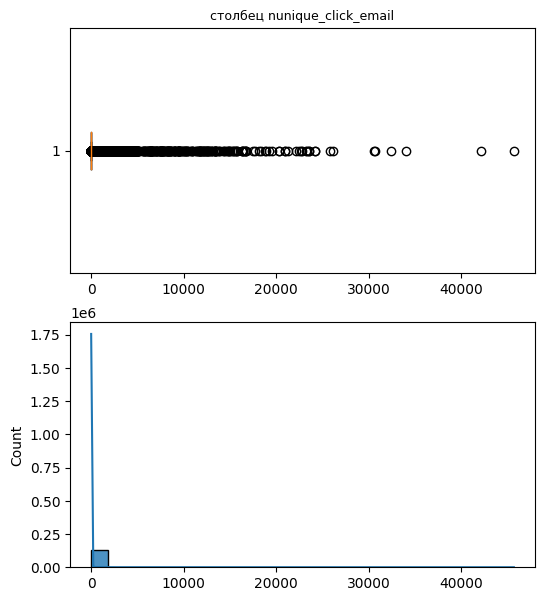

'⬇-------- Следующий признак: nunique_click_mobile_push --------⬇'

"фильтр = ''"

count    131072.000000
mean         42.879753
std         833.316257
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max       75899.000000
Name: nunique_click_mobile_push, dtype: float64

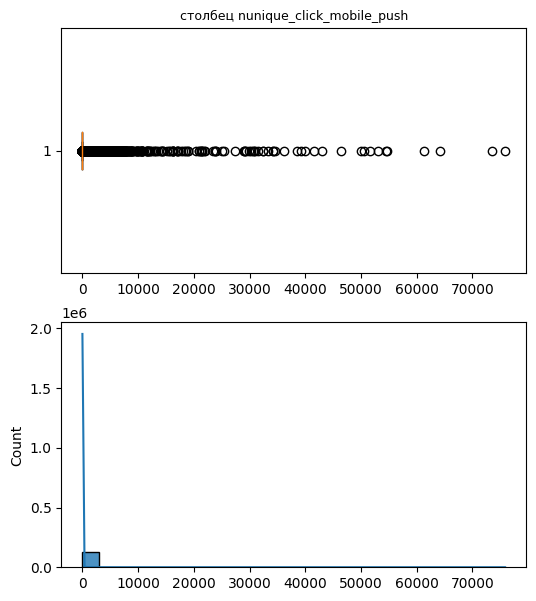

'⬇-------- Следующий признак: nunique_open_email --------⬇'

"фильтр = ''"

count    1.310720e+05
mean     4.116615e+02
std      9.519713e+03
min      0.000000e+00
25%      1.000000e+00
50%      5.000000e+00
75%      2.300000e+01
max      2.548617e+06
Name: nunique_open_email, dtype: float64

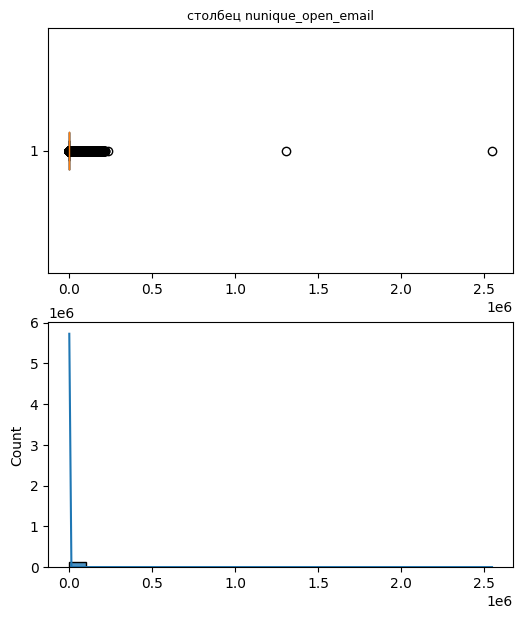

'⬇-------- Следующий признак: nunique_open_mobile_push --------⬇'

"фильтр = ''"

count    1.310720e+05
mean     3.271339e+03
std      6.188001e+04
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      2.922440e+06
Name: nunique_open_mobile_push, dtype: float64

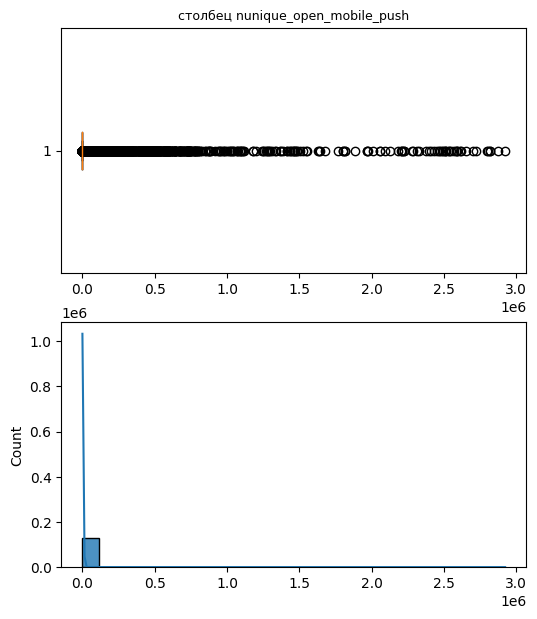

'⬇-------- Следующий признак: nunique_purchase_email --------⬇'

"фильтр = ''"

count    131072.000000
mean          0.287712
std           6.484979
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max         779.000000
Name: nunique_purchase_email, dtype: float64

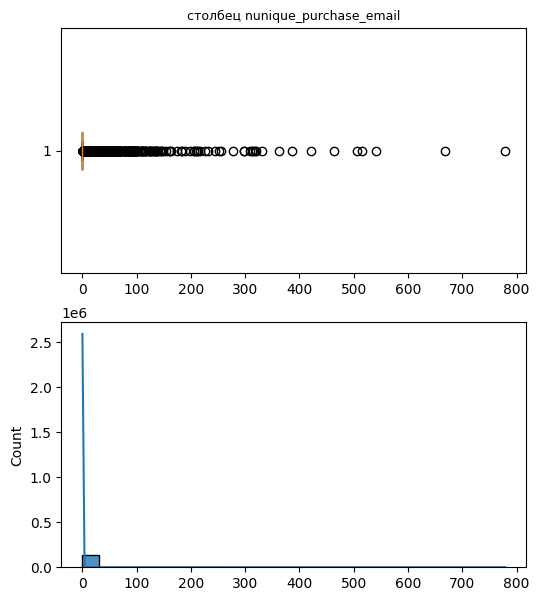

'⬇-------- Следующий признак: nunique_purchase_mobile_push --------⬇'

"фильтр = ''"

count    131072.000000
mean          0.177391
std           2.971908
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max         359.000000
Name: nunique_purchase_mobile_push, dtype: float64

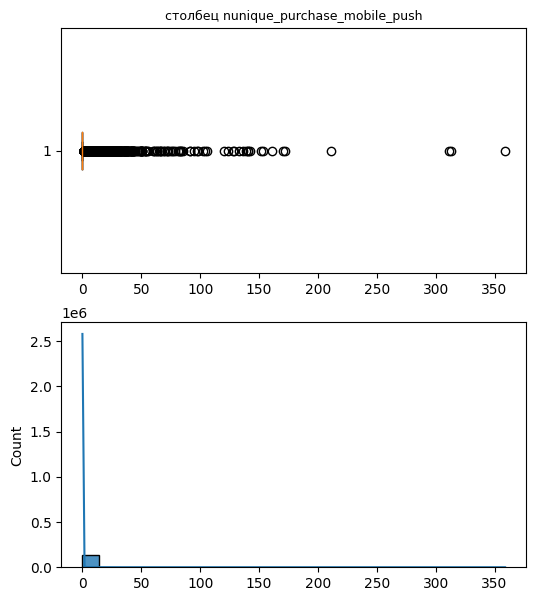

'⬇-------- Следующий признак: nunique_soft_bounce_email --------⬇'

"фильтр = ''"

count    131072.000000
mean         24.262146
std         724.270910
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max       76281.000000
Name: nunique_soft_bounce_email, dtype: float64

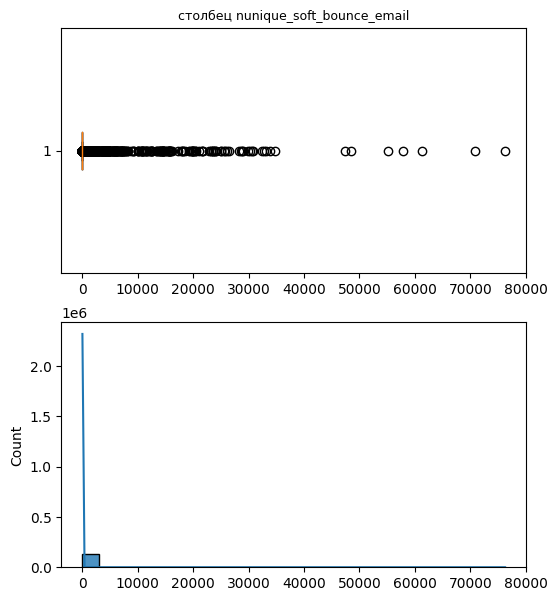

'⬇-------- Следующий признак: nunique_subscribe_email --------⬇'

"фильтр = ''"

count    131072.000000
mean          0.134125
std           1.976439
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max         177.000000
Name: nunique_subscribe_email, dtype: float64

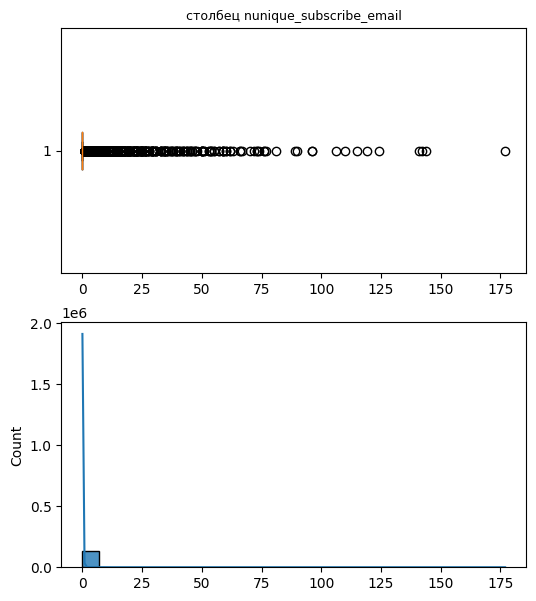

'⬇-------- Следующий признак: nunique_unsubscribe_email --------⬇'

"фильтр = ''"

count    131072.000000
mean          5.960602
std          73.284148
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max        8299.000000
Name: nunique_unsubscribe_email, dtype: float64

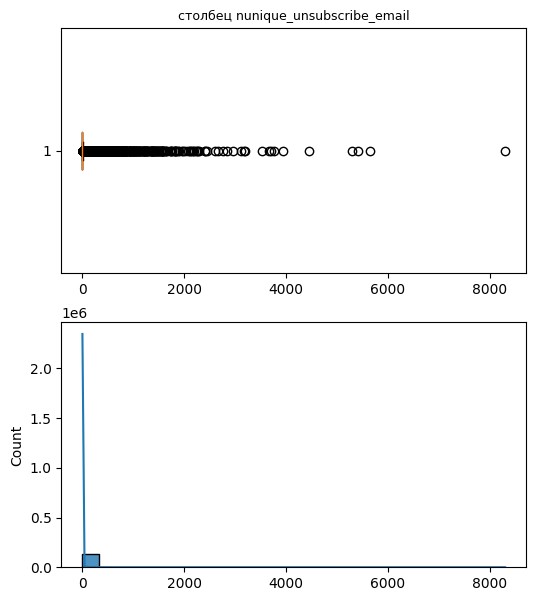

'⬇-------- Следующий признак: count_hard_bounce_mobile_push --------⬇'

"фильтр = ''"

count    131072.000000
mean         59.483444
std        1371.955350
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max      165526.000000
Name: count_hard_bounce_mobile_push, dtype: float64

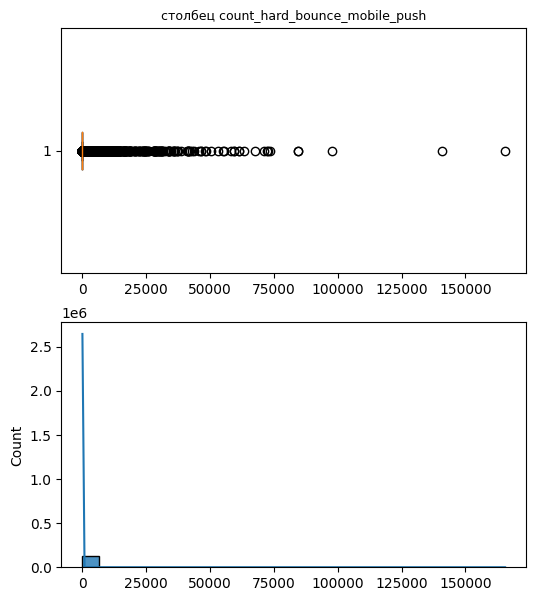

'⬇-------- Следующий признак: count_send_mobile_push --------⬇'

"фильтр = ''"

count    1.310720e+05
mean     7.444562e+03
std      1.393509e+05
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      1.154351e+07
Name: count_send_mobile_push, dtype: float64

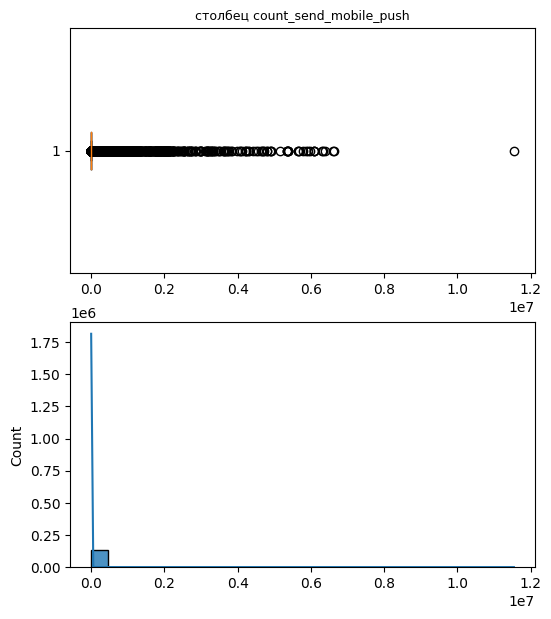

'⬇-------- Следующий признак: nunique_hard_bounce_mobile_push --------⬇'

"фильтр = ''"

count    131072.000000
mean         58.863007
std        1357.271261
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max      165526.000000
Name: nunique_hard_bounce_mobile_push, dtype: float64

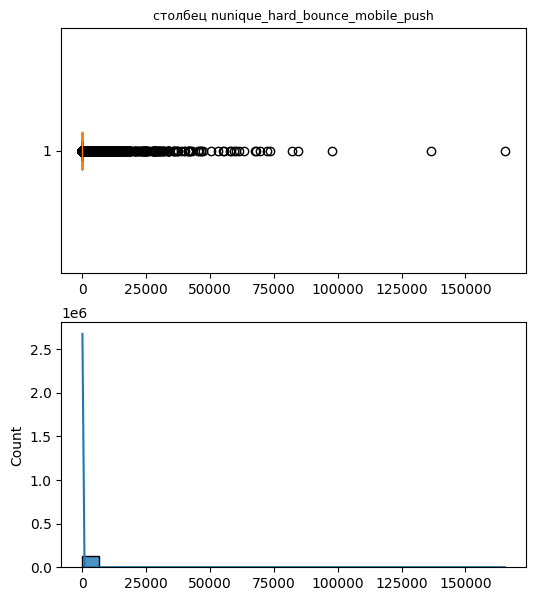

'⬇-------- Следующий признак: nunique_send_mobile_push --------⬇'

"фильтр = ''"

count    1.310720e+05
mean     7.350267e+03
std      1.355799e+05
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      6.636578e+06
Name: nunique_send_mobile_push, dtype: float64

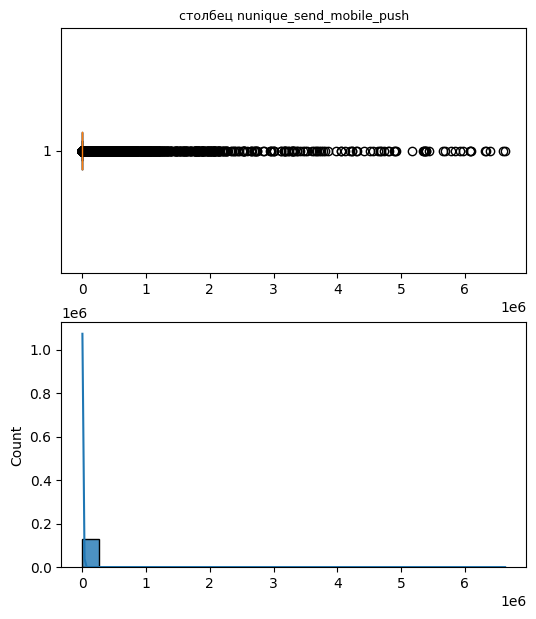

'⬇-------- Следующий признак: count_hard_bounce_email --------⬇'

"фильтр = ''"

count    131072.000000
mean         18.989990
std        1402.414107
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max      287404.000000
Name: count_hard_bounce_email, dtype: float64

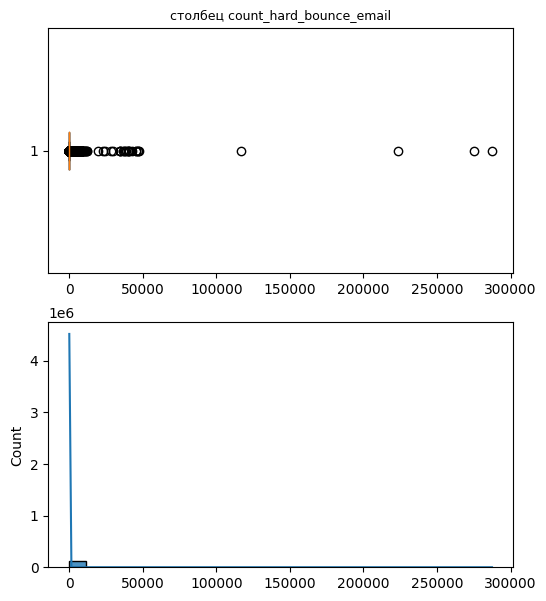

'⬇-------- Следующий признак: count_hbq_spam_email --------⬇'

"фильтр = ''"

count    131072.000000
mean          0.810364
std         183.298579
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max       63920.000000
Name: count_hbq_spam_email, dtype: float64

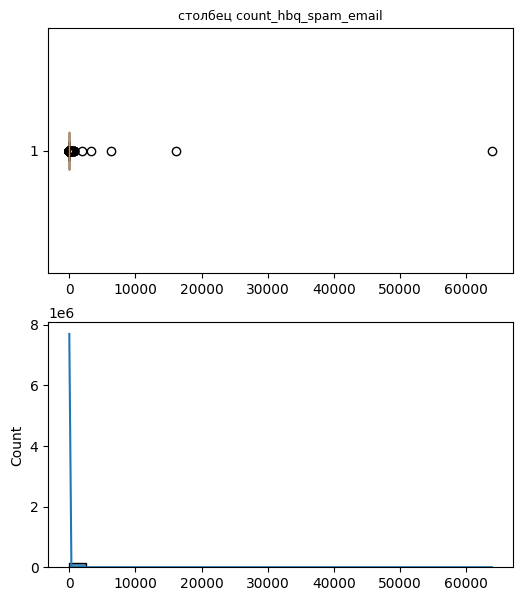

'⬇-------- Следующий признак: count_send_email --------⬇'

"фильтр = ''"

count    1.310720e+05
mean     4.189581e+03
std      1.073198e+05
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      7.094600e+06
Name: count_send_email, dtype: float64

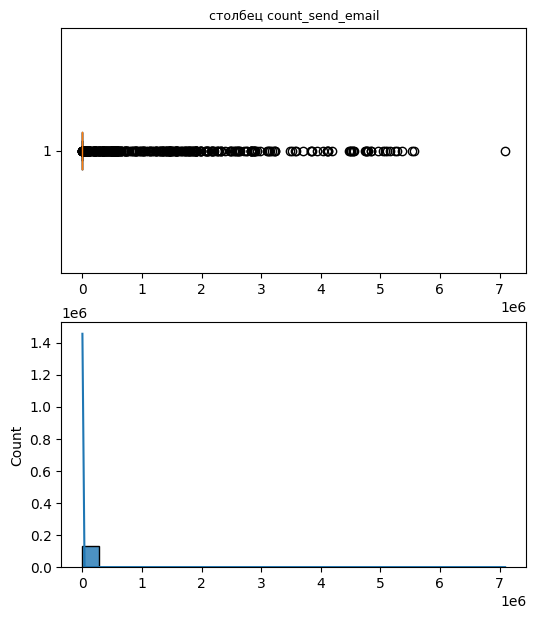

'⬇-------- Следующий признак: nunique_hard_bounce_email --------⬇'

"фильтр = ''"

count    131072.000000
mean         18.535683
std        1349.473695
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max      287341.000000
Name: nunique_hard_bounce_email, dtype: float64

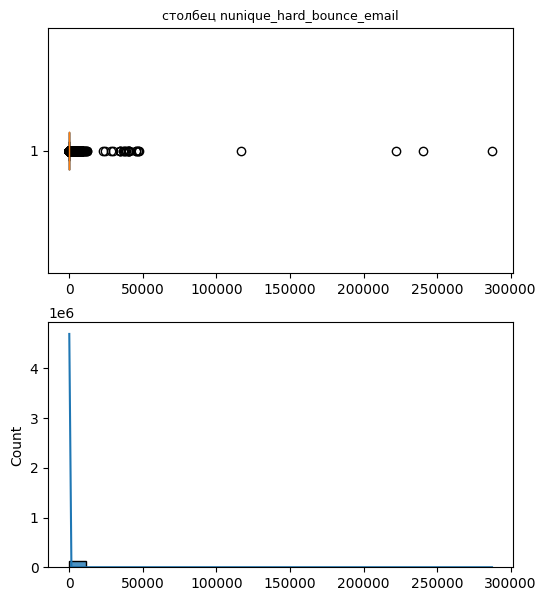

'⬇-------- Следующий признак: nunique_hbq_spam_email --------⬇'

"фильтр = ''"

count    131072.000000
mean          0.809799
std         183.298245
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max       63920.000000
Name: nunique_hbq_spam_email, dtype: float64

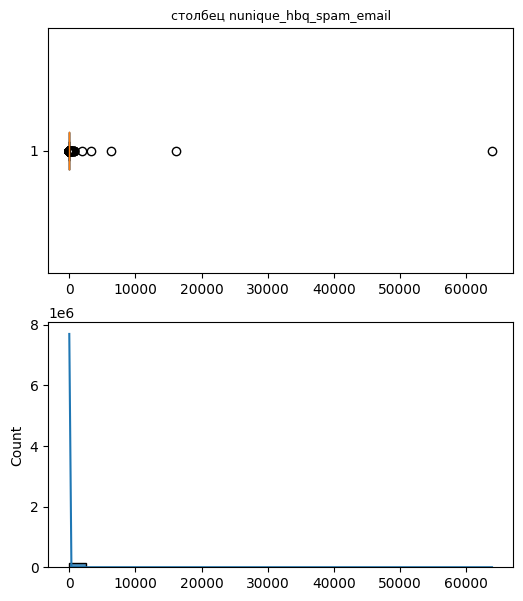

'⬇-------- Следующий признак: nunique_send_email --------⬇'

"фильтр = ''"

count    1.310720e+05
mean     4.186898e+03
std      1.072618e+05
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      7.094600e+06
Name: nunique_send_email, dtype: float64

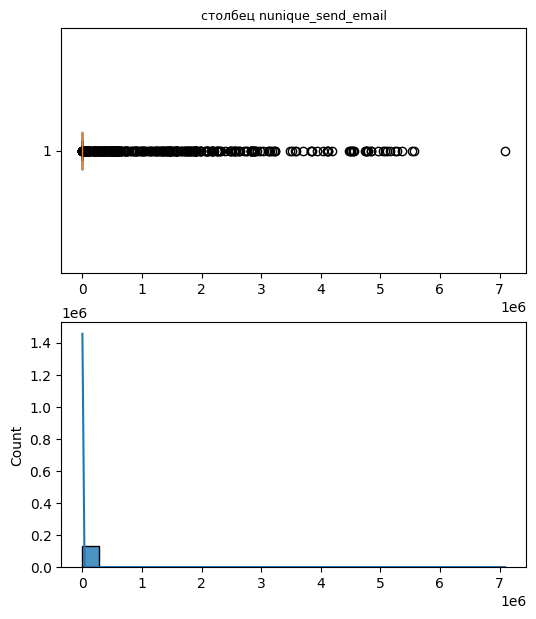

'⬇-------- Следующий признак: count_soft_bounce_mobile_push --------⬇'

"фильтр = ''"

count    131072.000000
mean          3.332489
std         120.916269
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max       21831.000000
Name: count_soft_bounce_mobile_push, dtype: float64

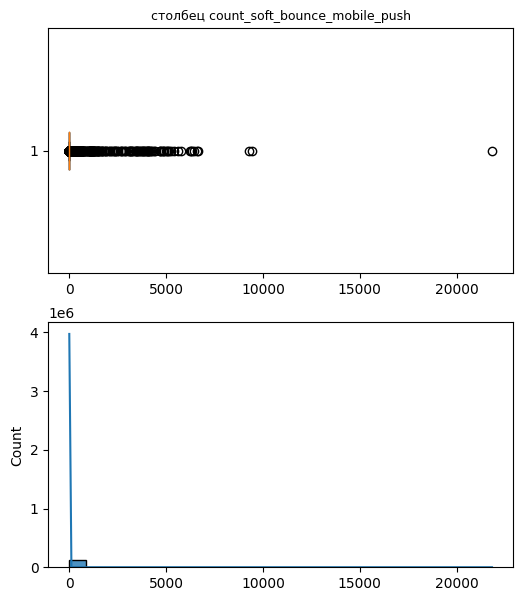

'⬇-------- Следующий признак: nunique_soft_bounce_mobile_push --------⬇'

"фильтр = ''"

count    131072.000000
mean          3.311653
std         120.094858
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max       21389.000000
Name: nunique_soft_bounce_mobile_push, dtype: float64

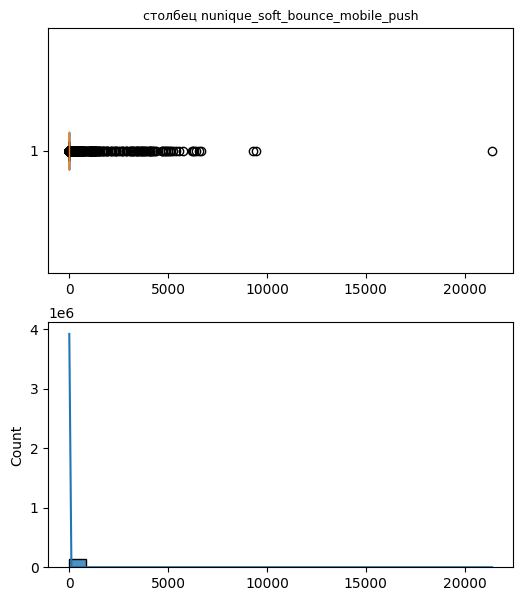

'⬇-------- Следующий признак: count_complain_email --------⬇'

"фильтр = ''"

count    131072.000000
mean          0.932655
std          30.198326
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max        5160.000000
Name: count_complain_email, dtype: float64

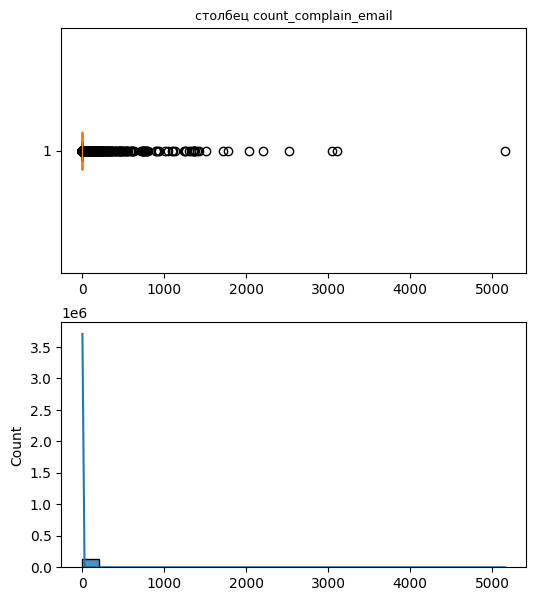

'⬇-------- Следующий признак: nunique_complain_email --------⬇'

"фильтр = ''"

count    131072.000000
mean          0.921326
std          29.715170
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max        5043.000000
Name: nunique_complain_email, dtype: float64

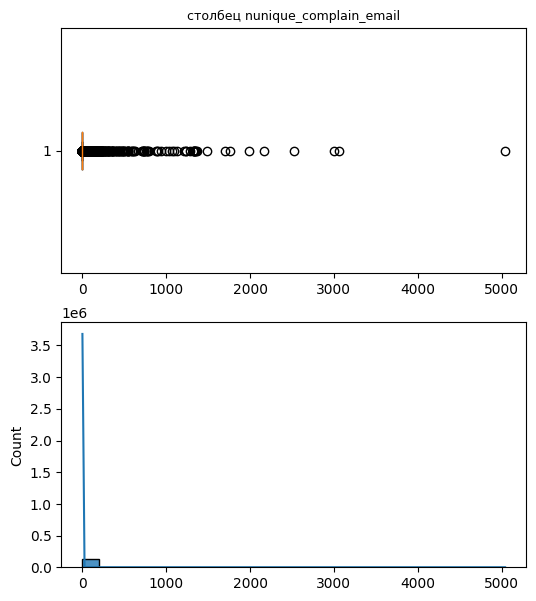

'⬇-------- Следующий признак: count_close_mobile_push --------⬇'

"фильтр = ''"

count    131072.000000
mean          0.000008
std           0.002762
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           1.000000
Name: count_close_mobile_push, dtype: float64

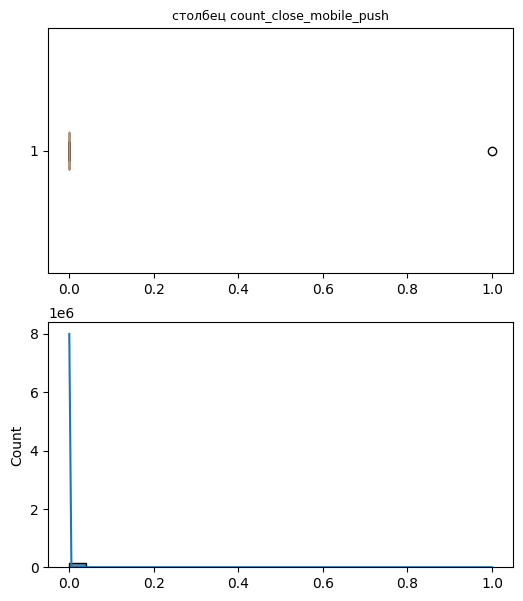

'⬇-------- Следующий признак: nunique_close_mobile_push --------⬇'

"фильтр = ''"

count    131072.000000
mean          0.000008
std           0.002762
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           1.000000
Name: nunique_close_mobile_push, dtype: float64

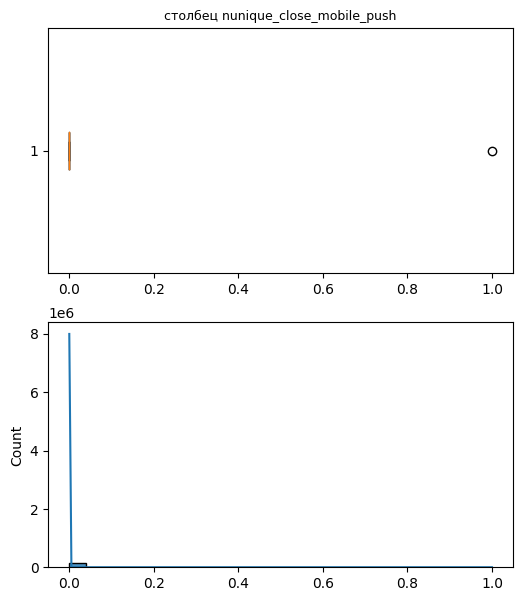

'⬇-------- Следующий признак: date_year --------⬇'

"фильтр = ''"

count    131072.000000
mean       2022.886688
std           0.760484
min        2022.000000
25%        2022.000000
50%        2023.000000
75%        2023.000000
max        2024.000000
Name: date_year, dtype: float64

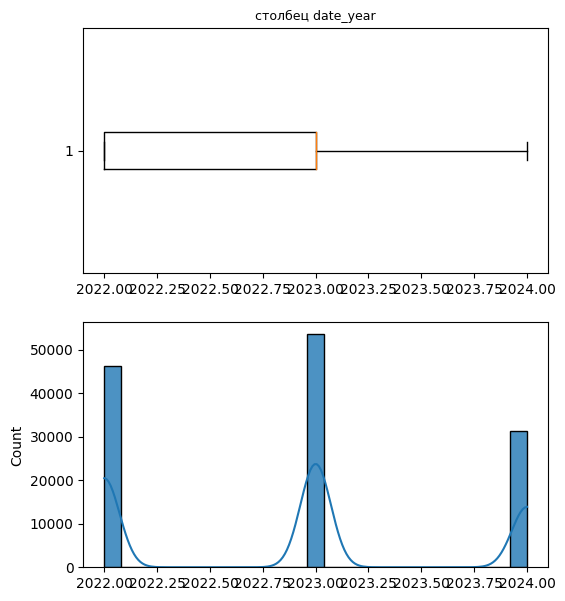

'⬇-------- Следующий признак: date_month --------⬇'

"фильтр = ''"

count    131072.000000
mean          6.195587
std           3.644664
min           1.000000
25%           3.000000
50%           6.000000
75%          10.000000
max          12.000000
Name: date_month, dtype: float64

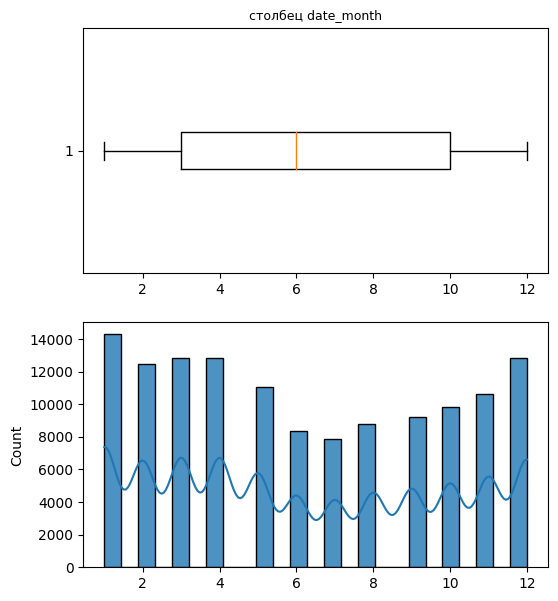

'⬇-------- Следующий признак: date_day --------⬇'

"фильтр = ''"

count    131072.000000
mean         15.722099
std           8.843386
min           1.000000
25%           8.000000
50%          16.000000
75%          23.000000
max          31.000000
Name: date_day, dtype: float64

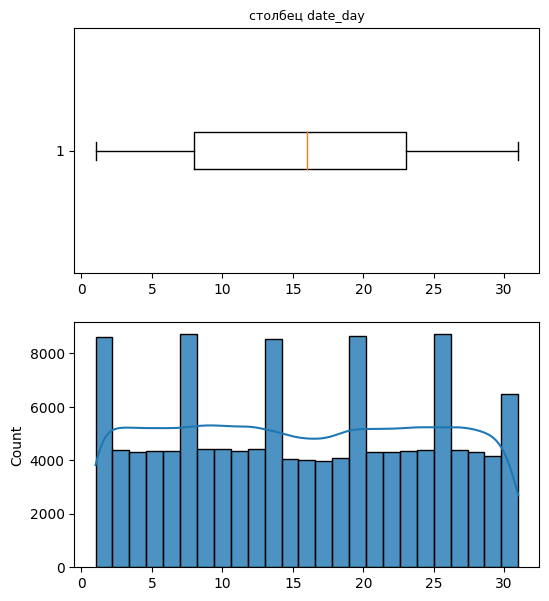

'⬇-------- Следующий признак: date_weekday --------⬇'

"фильтр = ''"

count    131072.000000
mean          2.973129
std           1.984597
min           0.000000
25%           1.000000
50%           3.000000
75%           5.000000
max           6.000000
Name: date_weekday, dtype: float64

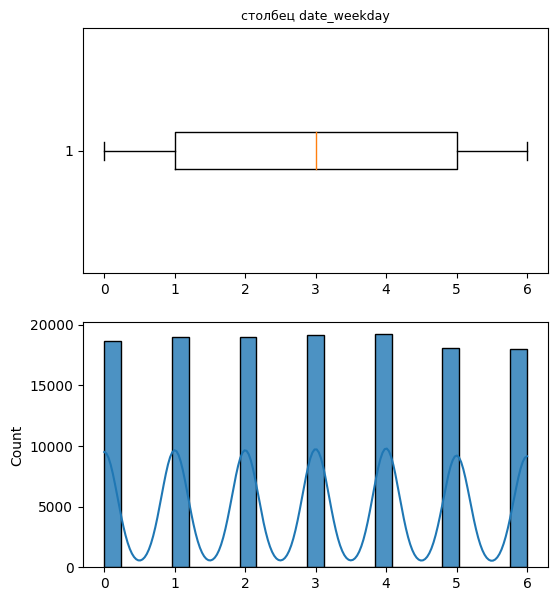

'⬇-------- Следующий признак: date_hour --------⬇'

c:\Users\Papa\.conda\envs\practicum\lib\site-packages\seaborn\distributions.py:306: UserWarning: Dataset has 0 variance; skipping density estimate.
  warnings.warn(msg, UserWarning)


"фильтр = ''"

count    131072.0
mean          0.0
std           0.0
min           0.0
25%           0.0
50%           0.0
75%           0.0
max           0.0
Name: date_hour, dtype: float64

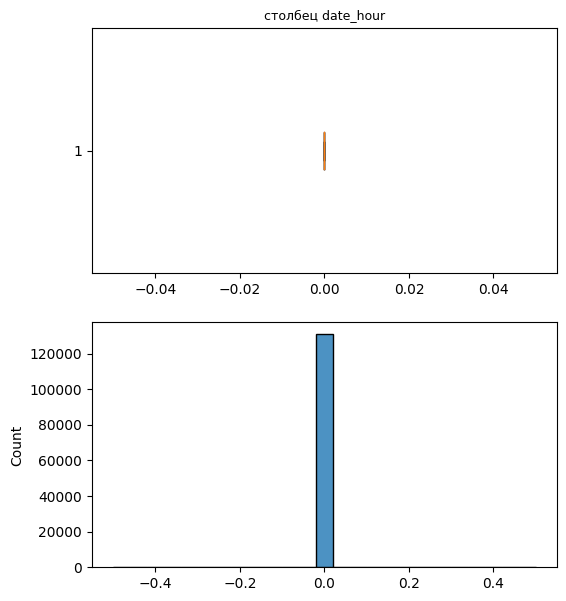

In [36]:
do_eda(df_full_events_channel)

Оценим целевой признак:

'⬇-------- Следующий признак: client_id --------⬇'

"фильтр = ''"

count    4.984900e+04
mean     1.515916e+18
std      1.487947e+08
min      1.515916e+18
25%      1.515916e+18
50%      1.515916e+18
75%      1.515916e+18
max      1.515916e+18
Name: client_id, dtype: float64

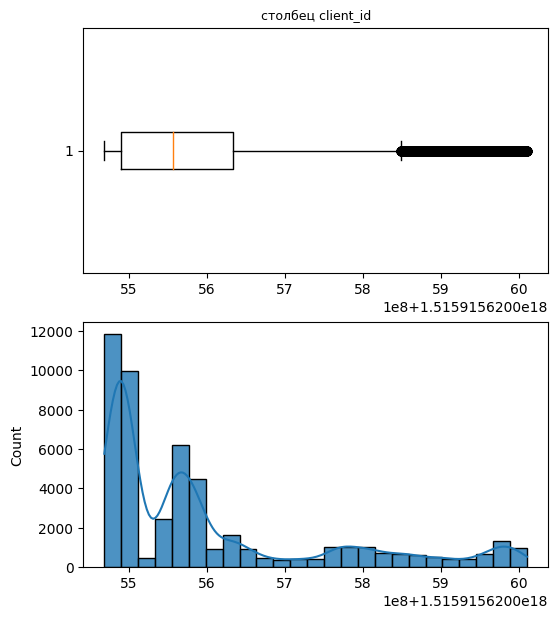

'⬇-------- Следующий признак: target --------⬇'

"фильтр = ''"

count    49849.000000
mean         0.019278
std          0.137503
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: target, dtype: float64

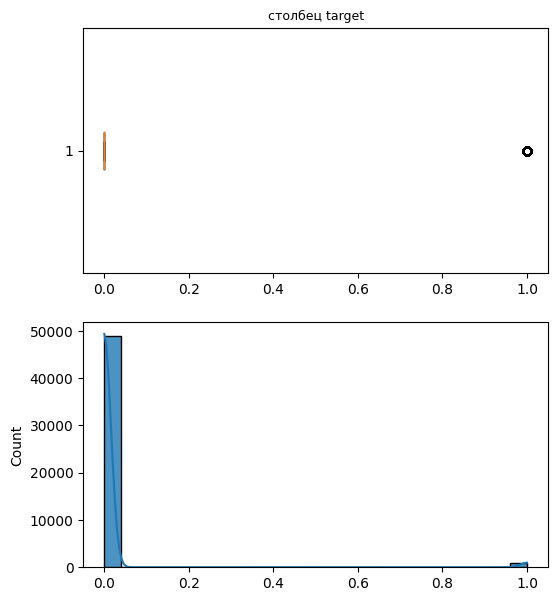

In [37]:
do_eda(df_apparel_target)

## Выводы по EDA

###  apparel-purchases \ category_ids:

Наиболее крупные группы категорий начинаются с:
- '4', '28'
- '4', '18'

Но 4 может быть "маркером распродажи или маркер женщинам/мужчинам".

Изучим топ, за исключением этих комбинаций:

In [38]:
df_apparel_purchases.query('not (cat1 == 4 and (cat2 == 28 or cat2 == 18))') \
    ['category_ids'].value_counts()

[]                                  5579
['2', '18', '258', '441']           4905
['4', '31', '326', '505']           2843
['2', '18', '344', '445']           2314
['2', '18', '61', '661']            2133
                                    ... 
['5562', '5597', '5642', '900']        1
['5562', '5597', '5696', '1429']       1
['4', '5837', '5838', '5835']          1
['4', '27', '278', '471']              1
['5963', '5959', '6021', '6278']       1
Name: category_ids, Length: 870, dtype: int64

Видно ⤴ что топовые цепочки состоят из четырёх четырёхзначных чисел. Изучим ещё подетальнее, но уже в csv, раз value_counts не позволяет регулировать число строк на экране:

In [39]:
df_apparel_purchases.query('not (cat1 == 4 and (cat2 == 28 or cat2 == 18))') \
    ['category_ids'].value_counts().to_csv('df_apparel_purchases_no_4_18_28.csv')

Также стало понятно, что в крупные группы входят:

- ['2', '18'
- ['2', '17'
- ['4', '31'
- ['4', '29'
- ['4', '27'

Остальные случае в основном укладываются в паттерн "четырёх четырёхзначных чисел"

В то же время в описании сказано, что 44 - относится к категориям:

*44 на второй позиции списка или на третьей – это одна и та же категория. Иногда дерево категорий обновляется, поэтому могут меняться вложенности, например ['4', '28', '44', '1594'] или ['4', '44', '1594'].*

Делаю вывод, что 2 и 4 - это маркеры. Вынесем их наличие в отдельный признак:

In [40]:
df_apparel_purchases['marker2'] = df_apparel_purchases['cat1'].apply(lambda x: 1 if x == 2 else 0)
df_apparel_purchases['marker4'] = df_apparel_purchases['cat1'].apply(lambda x: 1 if x == 4 else 0)

Также в большими группами являются [] и [None]. Посмотрим на них:

In [41]:
df_apparel_purchases.query('category_ids == "[]" or category_ids == "[None]"').head()

,client_id,quantity,price,category_ids,date,message_id,date_year,date_month,date_day,date_weekday,date_hour,cat1,cat2,cat3,cat4,cat5,marker2,marker4
14848,1515915625649908756,1,2499.0,[None],2022-06-17,1515915625649908756-4981-62ac2dbf52fad,2022,6,17,4,0,0,0,0,0,0,0,0
22153,1515915625558323436,1,1.0,[],2022-07-09,1515915625487742246-5335-62c7d2d1281c7,2022,7,9,5,0,0,0,0,0,0,0,0
22154,1515915625558323436,1,1.0,[],2022-07-09,1515915625487742246-5335-62c7d2d1281c7,2022,7,9,5,0,0,0,0,0,0,0,0
32281,1515915625578652401,1,8.0,[None],2022-08-19,1515915625815834300-5922-62ff35494e05f,2022,8,19,4,0,0,0,0,0,0,0,0
32282,1515915625578652401,1,8.0,[None],2022-08-19,1515915625815834300-5922-62ff35494e05f,2022,8,19,4,0,0,0,0,0,0,0,0


Для таких категорий cat1-4, marker2-4 сконструированы корректно.

category_ids нам более не нужен и (вернее вреден при кодировании), поэтому удалим его:

In [42]:
df_apparel_purchases = df_apparel_purchases.drop (['category_ids'], axis=1)

### apparel-purchases \ client_id

по графику распределения видно, что есть 2 пика по значению id и они ближе к левому краю. Из этого можно сделать вывод (в предположении, что id выдавались последовательно), что были две большие волны подключения клиентов, причём они - ближе к началу наблюдаемого периода. Значит рост сервиса замедлился.

### apparel-purchases \ quantity

Подавляющее большинство (75+%) покупок содержат один товар. Максимальное количество товаров в одной покупке = 30.

### apparel-purchases \ price

- Минимальная цена = 1
- Медианная цена = 987
- Максимальная цена = 85499

### apparel-purchases \ date

- год с 2022 по 2024 включительно (большинство покупок за 2023 год)
- самые активные месяцы 6, 11, 12 (возможно, отпуска и новый год), наименее актинвые месяцы - 2 и 10
- наиболее активный день недели - Пт

### apparel-messages \ event

Это признак имеет порядок и его нужнео будет кодировать ordinal-encoder-ом.

Можно было бы выделить в отдельный признак как наиболее позитивные события (purchase, subscribe, click, open), как и наиболее негативные (complain, unsubscribe, hard_bounce, hbq_spam) - но мы просто учтём это при указании порядка. Распределение показывает вполне логичную ожидаемую воронку и видно, что мобильное приложение (вероятно, маркет) лидирует (~59) по сравнению с почтой (~40%):

In [43]:
df_apparel_messages['event'].value_counts()

send           9058174
open           3052481
click           483326
purchase         62593
hard_bounce      19763
soft_bounce      10582
unsubscribe       2833
hbq_spam           823
complain           527
subscribe           85
close                1
Name: event, dtype: int64

In [44]:
df_apparel_messages[['event', 'channel']].value_counts()

event        channel    
send         mobile_push    5120953
             email          3937221
open         mobile_push    2179343
             email           873138
click        email           351949
             mobile_push     131377
purchase     email            44215
hard_bounce  mobile_push      19404
purchase     mobile_push      18378
soft_bounce  email             9566
unsubscribe  email             2833
soft_bounce  mobile_push       1016
hbq_spam     email              823
complain     email              527
hard_bounce  email              359
subscribe    email               85
close        mobile_push          1
dtype: int64

Можно было бы также добавить каналы рекламных баннеров из сайтов/поиска/приложений/видео - это помогло бы предсказывать ещё точнее.

Разберём пример одной рассылки:

In [45]:
df_apparel_messages.query('message_id == "1515915625468060902-4617-6290657dac196"')

,bulk_campaign_id,client_id,message_id,event,channel,date,created_at,date_year,date_month,date_day,date_weekday,date_hour,created_at_year,created_at_month,created_at_day,created_at_weekday,created_at_hour
127441,4617,1515915625468060902,1515915625468060902-4617-6290657dac196,send,email,2022-05-27,2022-05-27 05:49:50,2022,5,27,4,0,2022,5,27,4,5
155015,4617,1515915625468060902,1515915625468060902-4617-6290657dac196,open,email,2022-05-27,2022-05-27 10:57:52,2022,5,27,4,0,2022,5,27,4,10
155023,4617,1515915625468060902,1515915625468060902-4617-6290657dac196,click,email,2022-05-27,2022-05-27 10:59:04,2022,5,27,4,0,2022,5,27,4,10
155182,4617,1515915625468060902,1515915625468060902-4617-6290657dac196,click,email,2022-05-27,2022-05-27 11:22:53,2022,5,27,4,0,2022,5,27,4,11
155216,4617,1515915625468060902,1515915625468060902-4617-6290657dac196,purchase,email,2022-05-27,2022-05-27 11:26:49,2022,5,27,4,0,2022,5,27,4,11
155237,4617,1515915625468060902,1515915625468060902-4617-6290657dac196,purchase,email,2022-05-27,2022-05-27 11:31:31,2022,5,27,4,0,2022,5,27,4,11
155260,4617,1515915625468060902,1515915625468060902-4617-6290657dac196,click,email,2022-05-27,2022-05-27 11:35:07,2022,5,27,4,0,2022,5,27,4,11
155263,4617,1515915625468060902,1515915625468060902-4617-6290657dac196,click,email,2022-05-27,2022-05-27 11:35:40,2022,5,27,4,0,2022,5,27,4,11
155312,4617,1515915625468060902,1515915625468060902-4617-6290657dac196,purchase,email,2022-05-27,2022-05-27 11:41:14,2022,5,27,4,0,2022,5,27,4,11
155528,4617,1515915625468060902,1515915625468060902-4617-6290657dac196,purchase,email,2022-05-27,2022-05-27 12:14:50,2022,5,27,4,0,2022,5,27,4,12


- в 5 часов она была отправлена
- в 10 часов была открыта
- затем было 2 клика и 2 покупки

In [46]:
df_apparel_purchases.query('message_id == "1515915625468060902-4617-6290657dac196"')

,client_id,quantity,price,date,message_id,date_year,date_month,date_day,date_weekday,date_hour,cat1,cat2,cat3,cat4,cat5,marker2,marker4
3695,1515915625468060902,1,199.0,2022-05-27,1515915625468060902-4617-6290657dac196,2022,5,27,4,0,4,27,176,458,0,0,1
3696,1515915625468060902,1,1999.0,2022-05-27,1515915625468060902-4617-6290657dac196,2022,5,27,4,0,4,28,260,420,0,0,1
3697,1515915625468060902,1,1299.0,2022-05-27,1515915625468060902-4617-6290657dac196,2022,5,27,4,0,4,27,1828,1599,0,0,1
3698,1515915625468060902,1,1999.0,2022-05-27,1515915625468060902-4617-6290657dac196,2022,5,27,4,0,4,28,260,420,0,0,1
3699,1515915625468060902,1,199.0,2022-05-27,1515915625468060902-4617-6290657dac196,2022,5,27,4,0,4,27,176,458,0,0,1
3700,1515915625468060902,1,299.0,2022-05-27,1515915625468060902-4617-6290657dac196,2022,5,27,4,0,4,28,290,422,0,0,1
3701,1515915625468060902,1,999.0,2022-05-27,1515915625468060902-4617-6290657dac196,2022,5,27,4,0,4,28,244,432,0,0,1


В то же время в таблице покупок ⤴ с этой рассылкой у этого же клиента связано 7 покупок - у 6 из которых не совпадают цены и категории (cat4).

Интересно, какая доля покупок в таблице apparel-purchases без предшествующих сообщений?

In [47]:
df_apparel_purchases.query('message_id.isnull()')

,client_id,quantity,price,date,message_id,date_year,date_month,date_day,date_weekday,date_hour,cat1,cat2,cat3,cat4,cat5,marker2,marker4


все покупки нашего датасета apparel-purchases связаны с какой-то рассылкой ⤴ 

### apparel-messages \ bulk_campaign

По распределению видно, что последние кампании рассылок (в предположении, что они нумеруются последовательно) более значительно массивные. Возможно, это связано с предыдущем наблюдением-предположением о замедлении роста сервиса - интерес клиентов стараются привлечь активнее, чем раньше.

### apparel-messages \ created_month

По распределению видно, что объём рассылок растёт с 4 месяца по 12 и убывает с 12 по 4.

### apparel-messages \ created_day, weekday

Видна периодичность рассылок - пики примерно раз в неделю в Пт, а самый неактивный день - Вс.

### apparel-messages \ created_hour

Видна периодичность рассылок по часам, но оценим её отдельно по каналам:

'⬇-------- Следующий признак: created_at_hour --------⬇'

'фильтр = \'channel == "email"\''

count    5.220716e+06
mean     9.710255e+00
std      3.368512e+00
min      0.000000e+00
25%      7.000000e+00
50%      9.000000e+00
75%      1.100000e+01
max      2.300000e+01
Name: created_at_hour, dtype: float64

'фильтр = \'channel == "mobile_push"\''

count    7.470472e+06
mean     1.145301e+01
std      3.412412e+00
min      0.000000e+00
25%      9.000000e+00
50%      1.200000e+01
75%      1.400000e+01
max      2.300000e+01
Name: created_at_hour, dtype: float64

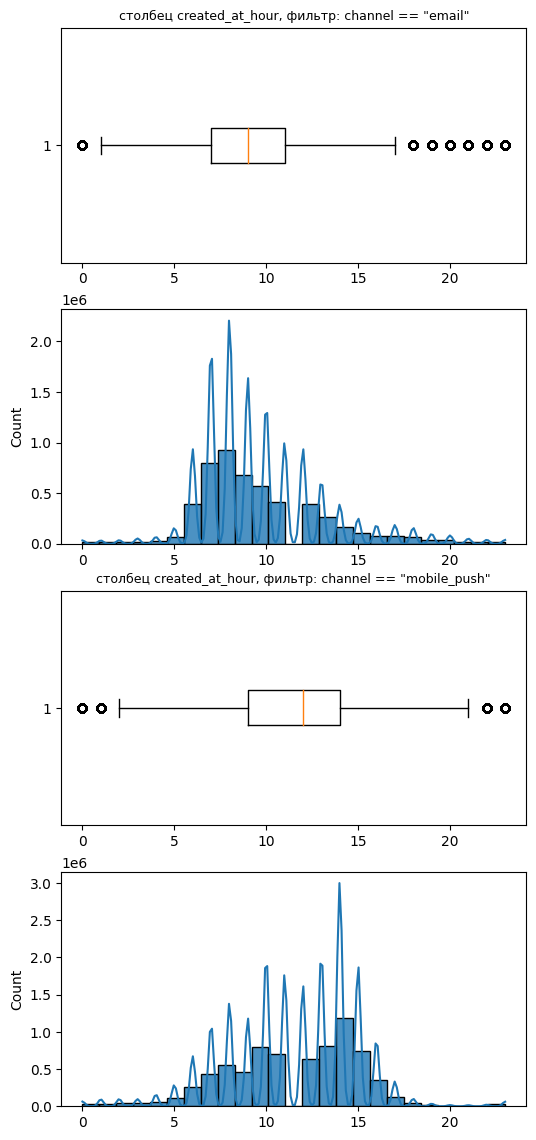

In [48]:
do_eda(df_apparel_messages, columns=['created_at_hour'],
       filters=['channel == "email"', 'channel == "mobile_push"'])

Видно ⤴ что email рассылаются преимущественно с 5 до 11 утра.

Пик пушей же - вечером. Очень много пушей в утреннее время. Очень хочется верить, что это связано с разными рассылкой по разным таймзонам, и что никому в его таймзоне не рассылаются пуши ночью во время сна. Но стоит написать в выводах продакт менеджерам, на всякий случай, пусть проверят ⚠️[!] (проверить в датасете это не удастся из-за отсутствия информации о таймзоне клиента).

👷✅  стоит рассмотреть разделение отдельных признаков на два - мобильных пушей и email.

### apparel-messages \ date

Посмотрим, а нужен ли вообще это столбец, или он всегда совпадает с create_at_date?

In [49]:
df_apparel_messages.query('created_at_year != date_year and '
                          'created_at_month != date_month and '
                          'created_at_day != date_day')

,bulk_campaign_id,client_id,message_id,event,channel,date,created_at,date_year,date_month,date_day,date_weekday,date_hour,created_at_year,created_at_month,created_at_day,created_at_weekday,created_at_hour


Всегда совпадает - удалим date:

In [50]:
df_apparel_messages = df_apparel_messages.drop(['date_year', 'date_month', 'date_day'], axis=1)

### apparel_target

In [51]:
df_apparel_target['target'].value_counts()

0    48888
1      961
Name: target, dtype: int64

In [52]:
df_apparel_target['target'].value_counts(normalize=True)

0    0.980722
1    0.019278
Name: target, dtype: float64

👷✅  датасет крайне несбалансированный, потребуется балансировка!

## Сведение данных

### apparel-purchases

💡[!] Итак, наш таргет - это client_id, предсказание требуется именно на уровне него, значит все остальные сущности (покупки, сообщения) - нужно агрегировать вокруг client_id.

Сгруппируем поля покупок вокруг client_id. Возникает вопрос - за какой период времени лучше агрегировать? С одной стороны лучше ориентироваться на актуальное (ни слишком давнее) поведение клиента (например, полгода). С другой стороны хорошо бы принять во внимание и сезонные явления, которые были в прошлом (и позапрошлом) году в этот же сезон. Поэтому все агрегаты посчитаем 2 раза - для последних 6 месяцев (_6mon) и для всего времени (_ever).

In [53]:
df_apparel_purchases ['amount'] = df_apparel_purchases ['price'] \
    * df_apparel_purchases ['quantity']


In [54]:
df_apparel_purchases ['cat_all'] = 10**12 * df_apparel_purchases ['cat1'] \
                                + 10**8 * df_apparel_purchases ['cat2'] \
                                + 10**4 * df_apparel_purchases ['cat3'] \
                                + df_apparel_purchases ['cat4'] \
                                

In [55]:
max_date = df_apparel_purchases['date'].sort_values(ascending=False).head(1).iloc[0]
max_date

Timestamp('2024-02-16 00:00:00')

In [56]:
date_6mon = (max_date - timedelta(days=180)).strftime("%Y-%m-%d")
date_6mon

'2023-08-20'

In [57]:
df_apparel_purchases_6mon = df_apparel_purchases.query(f'date > "{date_6mon}"')
df_apparel_purchases_6mon.shape

(36820, 19)

In [58]:
display(df_apparel_purchases_6mon.info())
display(df_apparel_purchases_6mon.head())

<class 'pandas.core.frame.DataFrame'>
Int64Index: 36820 entries, 165388 to 202207
Data columns (total 19 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   client_id     36820 non-null  int64         
 1   quantity      36820 non-null  int64         
 2   price         36820 non-null  float64       
 3   date          36820 non-null  datetime64[ns]
 4   message_id    36820 non-null  object        
 5   date_year     36820 non-null  int64         
 6   date_month    36820 non-null  int64         
 7   date_day      36820 non-null  int64         
 8   date_weekday  36820 non-null  int64         
 9   date_hour     36820 non-null  int64         
 10  cat1          36820 non-null  int64         
 11  cat2          36820 non-null  int64         
 12  cat3          36820 non-null  int64         
 13  cat4          36820 non-null  int64         
 14  cat5          36820 non-null  int64         
 15  marker2       36820 non-null  

None

,client_id,quantity,price,date,message_id,date_year,date_month,date_day,date_weekday,date_hour,cat1,cat2,cat3,cat4,cat5,marker2,marker4,amount,cat_all
165388,1515915625468099054,1,1999.0,2023-08-21,1515915625468099054-13690-64e34d49913e7,2023,8,21,0,0,4,27,1828,1606,0,0,1,1999.0,4002718281606
165389,1515915625468159950,1,7.0,2023-08-21,1515915625468159950-13667-64ddcc77cf0d3,2023,8,21,0,0,0,0,0,0,0,0,0,7.0,0
165390,1515915625468159950,1,7.0,2023-08-21,1515915625468159950-13667-64ddcc77cf0d3,2023,8,21,0,0,0,0,0,0,0,0,0,7.0,0
165391,1515915625468159950,1,275.0,2023-08-21,1515915625468159950-13667-64ddcc77cf0d3,2023,8,21,0,0,5562,5589,5686,1672,0,0,0,275.0,5562558956861672
165392,1515915625468159950,1,275.0,2023-08-21,1515915625468159950-13667-64ddcc77cf0d3,2023,8,21,0,0,5562,5589,5686,1672,0,0,0,275.0,5562558956861672


Соберём агрегаты:

In [59]:
df_apparel_purchases_6mon_grouped = df_apparel_purchases_6mon.groupby('client_id').agg( \
    purchases_quantity_6mon=('quantity', 'sum'),
    amount_6mon=('amount', 'sum'),
    median_price_6mon=('price', 'median'),
    min_price_6mon=('price', 'min'),
    max_price_6mon=('price', 'max'),
    top_month_6mon=('date_month', lambda x: x.mode().iloc[0]),
    top_day_6mon=('date_day', lambda x: x.mode().iloc[0]),
    top_weekday_6mon=('date_weekday', lambda x: x.mode().iloc[0]),
    mean_month_6mon=('date_month', 'mean'),
    mean_day_6mon=('date_day', 'mean'),
    mean_weekday_6mon=('date_weekday', 'mean'),
    mean_hour_6mon=('date_hour', 'mean'),
    top_cat_all_6mon=('cat_all', lambda x: x.mode().iloc[0]),
    top_cat1_6mon=('cat1', lambda x: x.mode().iloc[0]),
    top_cat2_6mon=('cat2', lambda x: x.mode().iloc[0]),
    top_cat3_6mon=('cat3', lambda x: x.mode().iloc[0]),
    top_cat4_6mon=('cat4', lambda x: x.mode().iloc[0]),
    mean_marker2_6mon=('marker2', 'mean'),
    mean_marker4_6mon=('marker4', 'mean')
)

In [60]:
df_apparel_purchases_ever_grouped = df_apparel_purchases.groupby('client_id').agg( \
    purchases_quantity_ever=('quantity', 'sum'),
    amount_ever=('amount', 'sum'),
    median_price_ever=('price', 'median'),
    min_price_ever=('price', 'min'),
    max_price_ever=('price', 'max'),
    top_month_ever=('date_month', lambda x: x.mode().iloc[0]),
    top_day_ever=('date_day', lambda x: x.mode().iloc[0]),
    top_weekday_ever=('date_weekday', lambda x: x.mode().iloc[0]),
    mean_month_ever=('date_month', 'mean'),
    mean_day_ever=('date_day', 'mean'),
    mean_weekday_ever=('date_weekday', 'mean'),
    mean_hour_ever=('date_hour', 'mean'),
    top_cat_all_ever=('cat_all', lambda x: x.mode().iloc[0]),
    top_cat1_ever=('cat1', lambda x: x.mode().iloc[0]),
    top_cat2_ever=('cat2', lambda x: x.mode().iloc[0]),
    top_cat3_ever=('cat3', lambda x: x.mode().iloc[0]),
    top_cat4_ever=('cat4', lambda x: x.mode().iloc[0]),
    mean_marker2_ever=('marker2', 'mean'),
    mean_marker4_ever=('marker4', 'mean')
)

### apparel-messages

In [61]:
df_apparel_messages['date'].sort_values(ascending=False).head(1).iloc[0]


Timestamp('2024-02-15 00:00:00')

In [62]:
df_apparel_purchases['date'].sort_values(ascending=False).head(1).iloc[0]

Timestamp('2024-02-16 00:00:00')

date_6mon оставим тем же, т. к. последние даты в purchases и messages - близки

In [63]:
df_apparel_messages_6mon = df_apparel_messages.query(f'date > "{date_6mon}"')
df_apparel_messages_6mon.shape

(5591110, 14)

In [64]:
display(df_apparel_messages_6mon.info())
display(df_apparel_messages_6mon.head())

<class 'pandas.core.frame.DataFrame'>
Int64Index: 5591110 entries, 7117648 to 12739797
Data columns (total 14 columns):
 #   Column              Dtype         
---  ------              -----         
 0   bulk_campaign_id    int64         
 1   client_id           int64         
 2   message_id          object        
 3   event               object        
 4   channel             object        
 5   date                datetime64[ns]
 6   created_at          datetime64[ns]
 7   date_weekday        int64         
 8   date_hour           int64         
 9   created_at_year     int64         
 10  created_at_month    int64         
 11  created_at_day      int64         
 12  created_at_weekday  int64         
 13  created_at_hour     int64         
dtypes: datetime64[ns](2), int64(9), object(3)
memory usage: 639.9+ MB


None

,bulk_campaign_id,client_id,message_id,event,channel,date,created_at,date_weekday,date_hour,created_at_year,created_at_month,created_at_day,created_at_weekday,created_at_hour
7117648,13664,1515915625971475691,1515915625971475691-13664-64dd8d69cb7e8,click,mobile_push,2023-08-21,2023-08-21 00:01:47,0,0,2023,8,21,0,0
7117649,13683,1515915625490413064,1515915625490413064-13683-64df3918b2049,open,email,2023-08-21,2023-08-21 00:05:47,0,0,2023,8,21,0,0
7117650,13683,1515915625491087563,1515915625491087563-13683-64df3928edf60,open,email,2023-08-21,2023-08-21 00:11:47,0,0,2023,8,21,0,0
7117651,13635,1515915625491415374,1515915625491415374-13635-64d61ac37f196,open,email,2023-08-21,2023-08-21 00:19:47,0,0,2023,8,21,0,0
7117652,13591,1515915625879183102,1515915625879183102-13591-64ccb629db7a0,open,email,2023-08-21,2023-08-21 00:39:47,0,0,2023,8,21,0,0


In [65]:
df_apparel_messages['event'].value_counts()

send           9058174
open           3052481
click           483326
purchase         62593
hard_bounce      19763
soft_bounce      10582
unsubscribe       2833
hbq_spam           823
complain           527
subscribe           85
close                1
Name: event, dtype: int64

In [66]:
df_bad_events_6mon_grouped = df_apparel_messages_6mon \
    .query('event in ["click", "open", "purchase", "subscribe"]') \
    .groupby('client_id').agg ( \
        bad_events_cnt_6mon =('event', 'count') )
df_good_events_6mon_grouped = df_apparel_messages_6mon \
    .query('event in ["hard_bounce", "soft_bounce", "unsubscribe", "hbq_spam", "complain", "close"]') \
    .groupby('client_id').agg ( \
        good_events_cnt_6mon =('event', 'count') )

df_moblie_events_6mon_grouped = df_apparel_messages_6mon \
    .query('channel == "mobile_push"') \
    .groupby('client_id').agg ( \
        mobile_events_cnt_6mon =('channel', 'count') )
df_email_events_6mon_grouped = df_apparel_messages_6mon \
    .query('channel == "email"') \
    .groupby('client_id').agg ( \
        email_events_cnt_6mon =('channel', 'count') )

In [67]:
df_bad_events_ever_grouped = df_apparel_messages \
    .query('event in ["click", "open", "purchase", "subscribe"]') \
    .groupby('client_id').agg ( \
        bad_events_cnt_ever =('event', 'count') )
df_good_events_ever_grouped = df_apparel_messages \
    .query('event in ["hard_bounce", "soft_bounce", "unsubscribe", "hbq_spam", "complain", "close"]') \
    .groupby('client_id').agg ( \
        good_events_cnt_ever =('event', 'count') )

df_moblie_events_ever_grouped = df_apparel_messages \
    .query('channel == "mobile_push"') \
    .groupby('client_id').agg ( \
        mobile_events_cnt_ever =('channel', 'count') )
df_email_events_ever_grouped = df_apparel_messages \
    .query('channel == "email"') \
    .groupby('client_id').agg ( \
        email_events_cnt_ever =('channel', 'count') )

In [68]:
df_apparel_messages_6mon_grouped = df_apparel_messages_6mon.groupby('client_id').agg( \
    msg_nunique_6mon=('message_id', 'nunique'),
    campaign_nunique_6mon=('bulk_campaign_id', 'nunique'),
    msg_top_month_6mon=('created_at_month', lambda x: x.mode().iloc[0]),
    msg_top_day_6mon=('created_at_day', lambda x: x.mode().iloc[0]),
    msg_top_weekday_6mon=('created_at_weekday', lambda x: x.mode().iloc[0]),
    msg_top_hour_6mon=('created_at_hour', lambda x: x.mode().iloc[0]),
    msg_mean_month_6mon=('created_at_month', 'mean'),
    msg_mean_day_6mon=('created_at_day', 'mean'),
    msg_mean_weekday_6mon=('created_at_weekday', 'mean'),
    msg_mean_hour_6mon=('created_at_hour', 'mean')
)

In [69]:
df_apparel_messages_ever_grouped = df_apparel_messages.groupby('client_id').agg( \
    msg_nunique_ever=('message_id', 'nunique'),
    campaign_nunique_ever=('bulk_campaign_id', 'nunique'),
    msg_top_month_ever=('created_at_month', lambda x: x.mode().iloc[0]),
    msg_top_day_ever=('created_at_day', lambda x: x.mode().iloc[0]),
    msg_top_weekday_ever=('created_at_weekday', lambda x: x.mode().iloc[0]),
    msg_top_hour_ever=('created_at_hour', lambda x: x.mode().iloc[0]),
    msg_mean_month_ever=('created_at_month', 'mean'),
    msg_mean_day_ever=('created_at_day', 'mean'),
    msg_mean_weekday_ever=('created_at_weekday', 'mean'),
    msg_mean_hour_ever=('created_at_hour', 'mean')
)

### Соберём агрегаты в единый датафрейм

In [70]:
df = df_apparel_target \
        .join (df_apparel_purchases_6mon_grouped, on='client_id') \
        .join (df_apparel_purchases_ever_grouped, on='client_id') \
        .join (df_apparel_messages_6mon_grouped, on='client_id') \
        .join (df_apparel_messages_ever_grouped, on='client_id') \
        .join (df_bad_events_6mon_grouped, on='client_id') \
        .join (df_good_events_6mon_grouped, on='client_id') \
        .join (df_bad_events_ever_grouped, on='client_id') \
        .join (df_good_events_ever_grouped, on='client_id') \
        .join (df_moblie_events_6mon_grouped, on='client_id') \
        .join (df_email_events_6mon_grouped, on='client_id') \
        .join (df_moblie_events_ever_grouped, on='client_id') \
        .join (df_email_events_ever_grouped, on='client_id') 

In [71]:
df = df.drop('client_id', axis=1)

In [72]:
df

,target,purchases_quantity_6mon,amount_6mon,median_price_6mon,min_price_6mon,max_price_6mon,top_month_6mon,top_day_6mon,top_weekday_6mon,mean_month_6mon,...,msg_mean_weekday_ever,msg_mean_hour_ever,bad_events_cnt_6mon,good_events_cnt_6mon,bad_events_cnt_ever,good_events_cnt_ever,mobile_events_cnt_6mon,email_events_cnt_6mon,mobile_events_cnt_ever,email_events_cnt_ever
0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.491525,9.384181,14.0,1.0,50.0,1.0,NaN,51.0,NaN,177.0
1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.436364,9.375758,2.0,NaN,11.0,NaN,NaN,44.0,NaN,165.0
2,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.442029,10.724638,3.0,NaN,59.0,2.0,NaN,50.0,94.0,182.0
3,0,2.0,2098.0,1049.0,1049.0,1049.0,2.0,10.0,5.0,2.0,...,2.521028,10.079439,100.0,1.0,159.0,2.0,225.0,NaN,428.0,NaN
4,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.662116,9.750853,16.0,NaN,50.0,NaN,91.0,63.0,91.0,202.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49844,0,6.0,8994.0,1499.0,1499.0,1499.0,2.0,16.0,4.0,2.0,...,3.000000,10.000000,2.0,NaN,2.0,NaN,3.0,NaN,3.0,NaN
49845,0,2.0,1818.0,909.0,909.0,909.0,2.0,14.0,2.0,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
49846,0,2.0,198.0,99.0,99.0,99.0,2.0,16.0,4.0,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
49847,0,1.0,1999.0,1999.0,1999.0,1999.0,2.0,16.0,4.0,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [73]:
show_nans (df)

'empty parts:'

purchases_quantity_6mon    0.83
amount_6mon                0.83
median_price_6mon          0.83
min_price_6mon             0.83
max_price_6mon             0.83
top_month_6mon             0.83
top_day_6mon               0.83
top_weekday_6mon           0.83
mean_month_6mon            0.83
mean_day_6mon              0.83
mean_weekday_6mon          0.83
mean_hour_6mon             0.83
top_cat_all_6mon           0.83
top_cat1_6mon              0.83
top_cat2_6mon              0.83
top_cat3_6mon              0.83
top_cat4_6mon              0.83
mean_marker2_6mon          0.83
mean_marker4_6mon          0.83
msg_nunique_6mon           0.23
campaign_nunique_6mon      0.23
msg_top_month_6mon         0.23
msg_top_day_6mon           0.23
msg_top_weekday_6mon       0.23
msg_top_hour_6mon          0.23
msg_mean_month_6mon        0.23
msg_mean_day_6mon          0.23
msg_mean_weekday_6mon      0.23
msg_mean_hour_6mon         0.23
msg_nunique_ever           0.16
campaign_nunique_ever      0.16
msg_top_

Сначала разберёмся с дубликатами, которые стоит заполнить не 0:

In [74]:
# другие элементы даты начинаются с 1 и можно заполнить Nan = 0,
# а weekday бывает = 0, поэтому для weekday возьмём 8
# остальные замены тут следуют той же логике
values = {"top_weekday_6mon": 8, "mean_weekday_6mon": 8, 
          "msg_top_weekday_6mon": 8, "msg_top_weekday_ever": 8,
          "msg_mean_weekday_6mon": 8, "msg_mean_weekday_ever": 8,
          "mean_marker2_6mon": 3, "mean_marker4_6mon": 3,
          "msg_top_hour_6mon": 25, "msg_mean_hour_6mon": 23}
df = df.fillna(value=values)

Остальные пропуски можно заполнить 0:

In [75]:
df = df.fillna(0)

Проревьюим ещё раз состав получившихся полей - не осталось ли лишних полей, или полей, приводящим к утечке целевого признака:

In [76]:
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49849 entries, 0 to 49848
Data columns (total 67 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   target                   49849 non-null  int64  
 1   purchases_quantity_6mon  49849 non-null  float64
 2   amount_6mon              49849 non-null  float64
 3   median_price_6mon        49849 non-null  float64
 4   min_price_6mon           49849 non-null  float64
 5   max_price_6mon           49849 non-null  float64
 6   top_month_6mon           49849 non-null  float64
 7   top_day_6mon             49849 non-null  float64
 8   top_weekday_6mon         49849 non-null  float64
 9   mean_month_6mon          49849 non-null  float64
 10  mean_day_6mon            49849 non-null  float64
 11  mean_weekday_6mon        49849 non-null  float64
 12  mean_hour_6mon           49849 non-null  float64
 13  top_cat_all_6mon         49849 non-null  float64
 14  top_cat1_6mon         

None

Оценим дубликаты:

In [77]:
display(df.duplicated().sum())
df = df.drop_duplicates()

70

# Разобъём выборку на тренировочную и тестовую (со стратификацией по целевому признаку в случае классификации)

In [78]:
df.shape

(49779, 67)

In [79]:
X = df.drop(['target'], axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    random_state=RANDOM_STATE,
    stratify=y
)

# Проверим мультиколлинеарность

In [80]:
interval_cols=['amount_6mon',
'median_price_6mon',
'min_price_6mon',
'max_price_6mon',
'mean_month_6mon',
'mean_day_6mon',
'mean_weekday_6mon',
'mean_hour_6mon',
'mean_marker2_6mon',
'mean_marker4_6mon',
'amount_ever',
'median_price_ever',
'min_price_ever',
'max_price_ever',
'mean_month_ever',
'mean_day_ever',
'mean_weekday_ever',
'mean_hour_ever',
'mean_marker2_ever',
'mean_marker4_ever',
'msg_mean_month_6mon',
'msg_mean_day_6mon',
'msg_mean_weekday_6mon',
'msg_mean_hour_6mon',
'msg_mean_month_ever',
'msg_mean_day_ever',
'msg_mean_weekday_ever',
'msg_mean_hour_ever']
   
bins = {}
for c in interval_cols:
    bins[c] = 10;

ph_mx = X_train.phik_matrix(interval_cols=interval_cols, bins=bins)

c:\Users\Papa\.conda\envs\practicum\lib\site-packages\phik\data_quality.py:72: UserWarning: Not enough unique value for variable mean_hour_6mon for analysis 1. Dropping this column
  warnings.warn(
c:\Users\Papa\.conda\envs\practicum\lib\site-packages\phik\data_quality.py:72: UserWarning: Not enough unique value for variable mean_hour_ever for analysis 1. Dropping this column
  warnings.warn(


*Как правило, о мультиколлинеарности говорят при значении коэффициента корреляции от 0.9 до 0.95 по модулю. В такой ситуации лишние коррелирующие признаки нужно удалять из обучающей выборки.*

In [81]:
columns_to_delete, ph_mx_no_mc = get_multicollinear_features (ph_mx)
display (columns_to_delete)

['top_cat_all_6mon',
 'top_cat4_6mon',
 'bad_events_cnt_ever',
 'top_cat3_6mon',
 'mobile_events_cnt_ever',
 'top_cat2_6mon',
 'msg_nunique_6mon',
 'campaign_nunique_6mon',
 'top_cat_all_ever',
 'email_events_cnt_ever',
 'top_cat3_ever',
 'mobile_events_cnt_6mon',
 'median_price_6mon',
 'top_cat2_ever',
 'min_price_ever',
 'purchases_quantity_ever',
 'campaign_nunique_ever',
 'top_day_6mon',
 'good_events_cnt_6mon',
 'top_weekday_6mon',
 'max_price_ever',
 'top_day_ever',
 'top_month_ever',
 'top_weekday_ever',
 'top_cat1_ever',
 'top_month_6mon',
 'bad_events_cnt_6mon',
 'msg_mean_month_6mon',
 'amount_6mon']

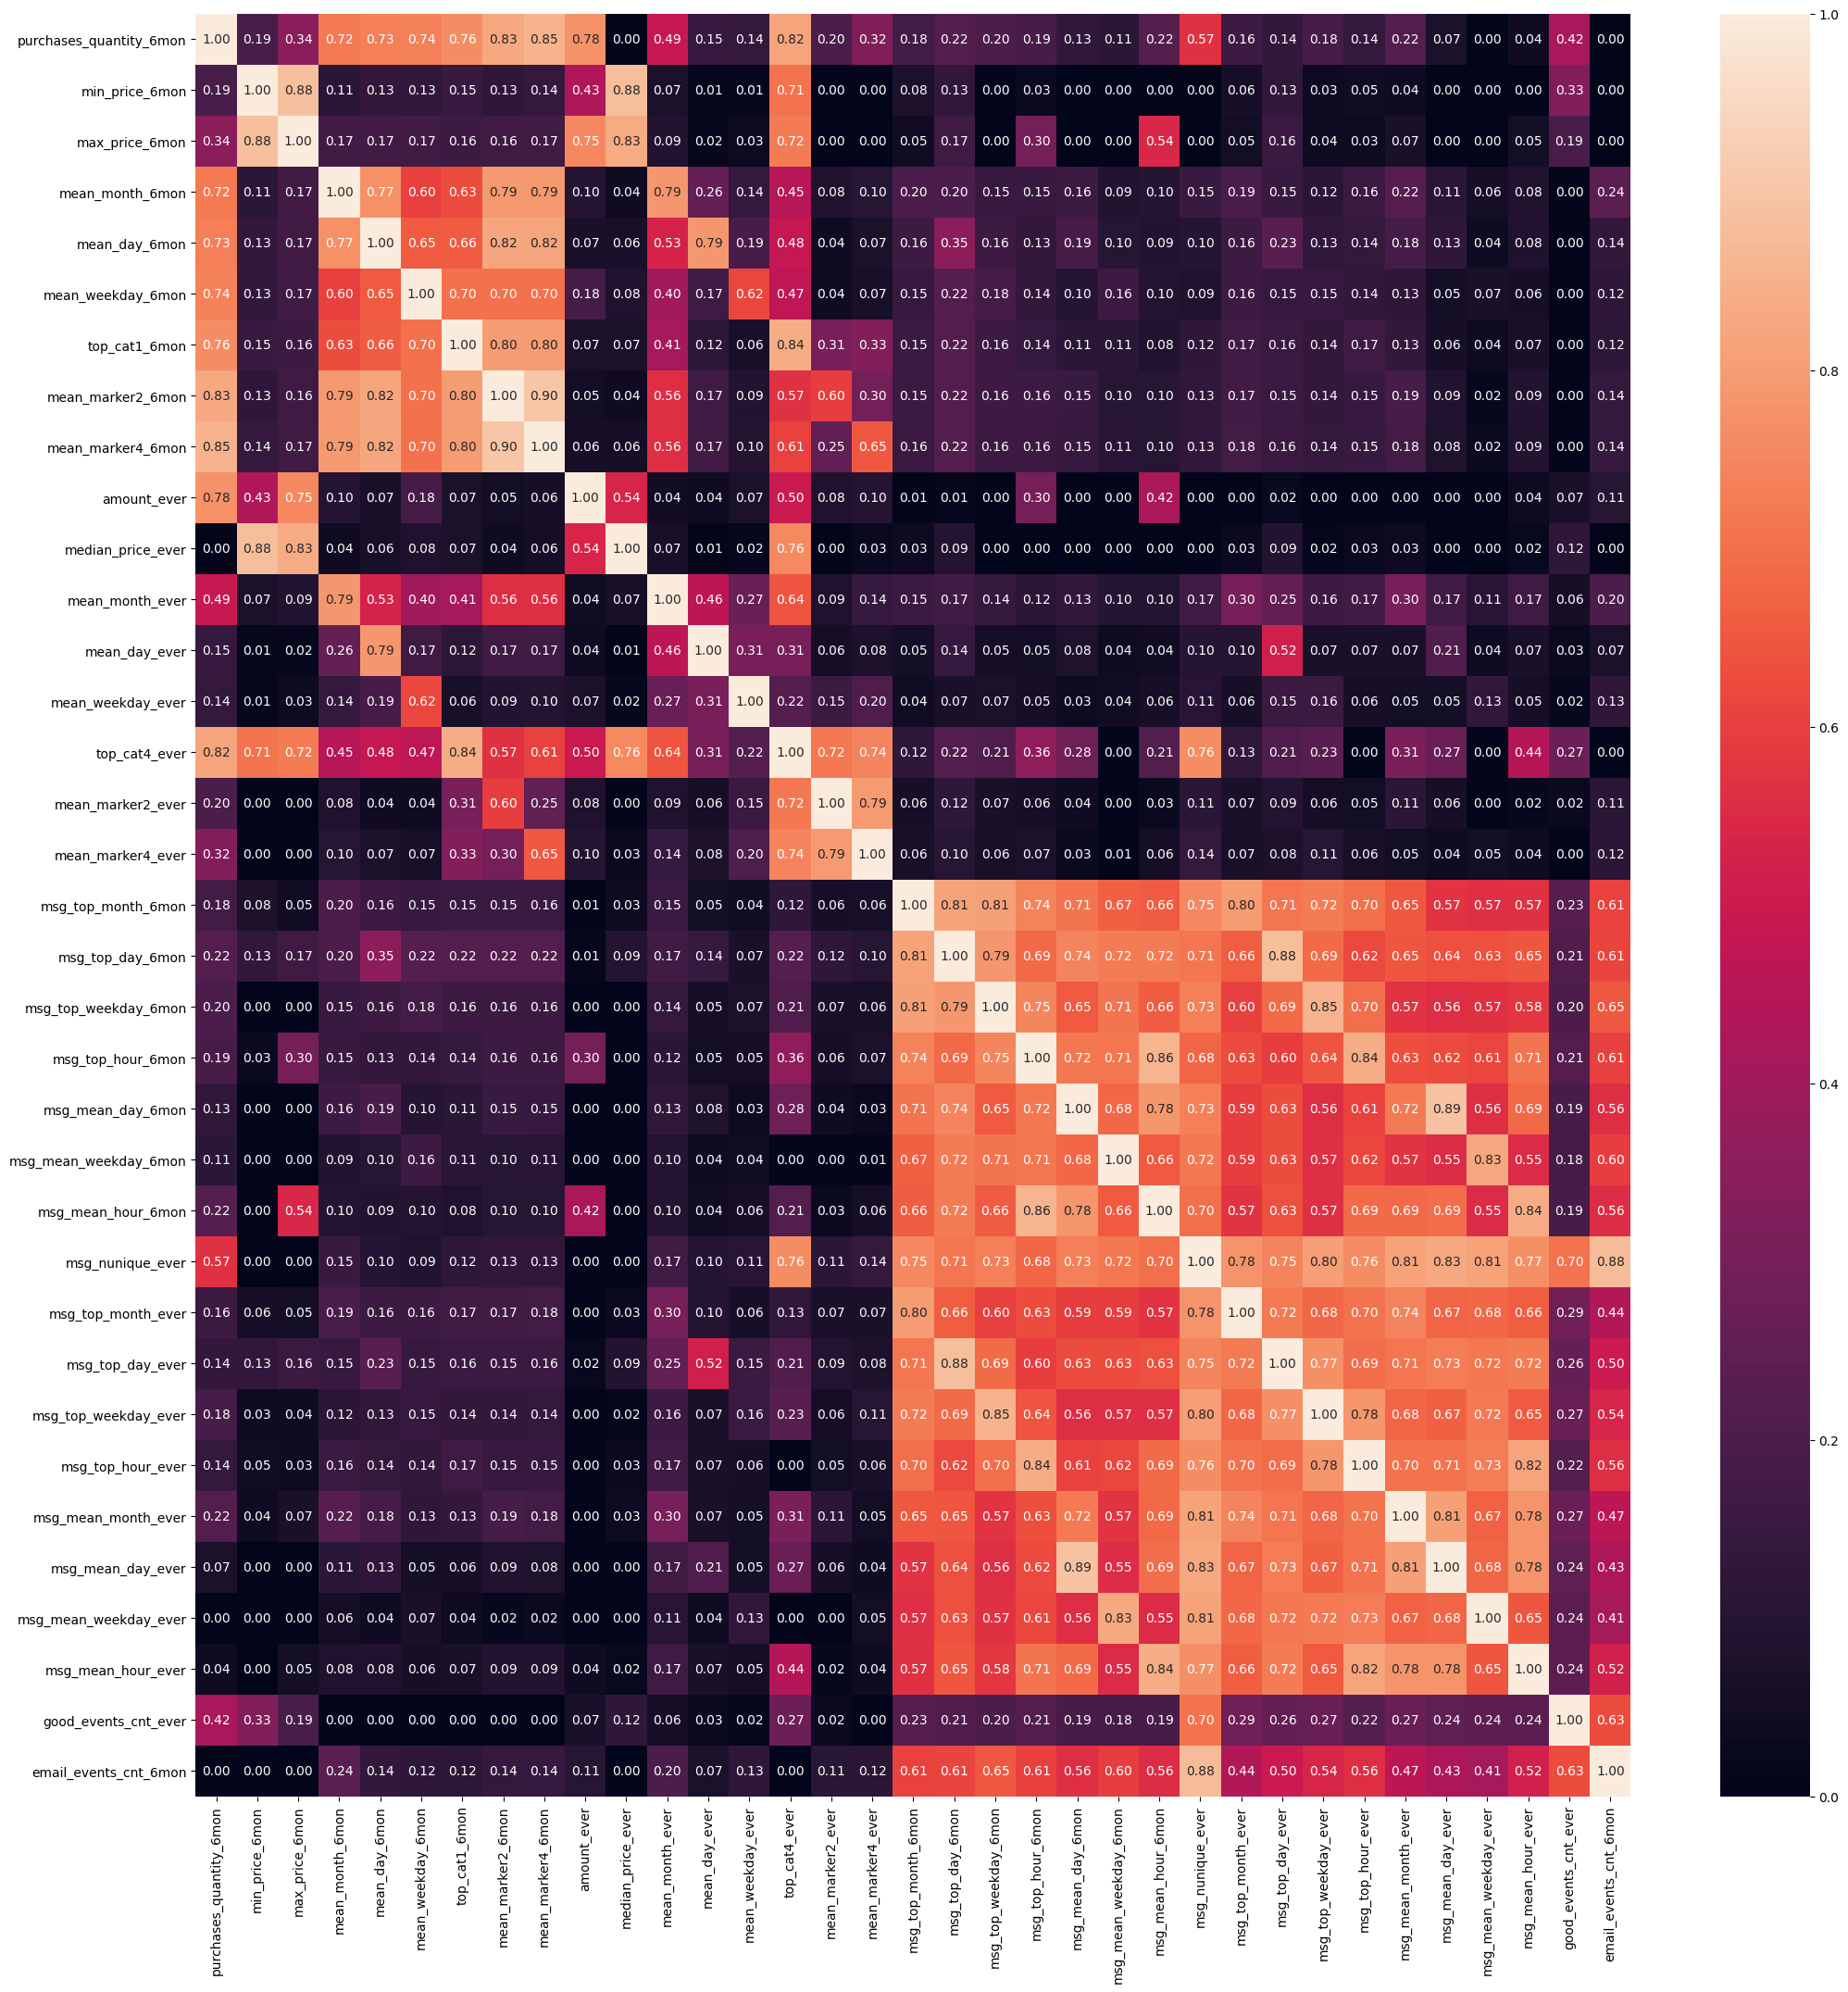

In [82]:
_, ax = plt.subplots(figsize=(25,25))
sns.heatmap(ph_mx_no_mc, annot=True, fmt='.2f', ax=ax);

Удалим ненужные столбцы:

In [83]:
X_train = X_train.drop(columns_to_delete, axis=1)
X_test = X_test.drop(columns_to_delete, axis=1)

UPD-2: т. к. на тестовой выборке очень низкие precision/recall - попробуем также удалить часть фичей из правого нижнего угла, может они тоже мешают..

In [84]:
columns_to_delete_2 = ['msg_top_day_ever', 'msg_top_day_6mon', 
                        'msg_nunique_ever', 'msg_mean_hour_ever', 'msg_mean_month_ever',
                        'msg_mean_day_ever', 'msg_mean_weekday_ever']

In [85]:
X_train = X_train.drop(columns_to_delete_2, axis=1)
X_test = X_test.drop(columns_to_delete_2, axis=1)

# Проверим сбалансированность тренировочной выборки относительно целевого класса (в случае классификации)

In [86]:
y_train.value_counts(normalize=True)

0    0.980688
1    0.019312
Name: target, dtype: float64

In [87]:
y_train.value_counts()

0    36613
1      721
Name: target, dtype: int64

Выборка крайне несбалансированная и элементов класса-1 всего 721. Их можно синтезировать оверсемплингом, но увеличивать таким образом в 20 раз (до 14К) не хотелось бы. Кажетcя, что более чем на 200% синтезировать данные не хотелось бы. Поэтому сделаем оверсемплинг класса-1 до 2000 и андерсемплинг класса 0 до 2000.

UPD-1: ввиду того, что первоначальные precision/recall получились совсем низкие - увеличу датасет ещё в 2 раза (до ~4К).

UPD-2: не помогло

In [88]:
under_sampler = RandomUnderSampler(sampling_strategy=0.16, random_state=RANDOM_STATE)
over_sampler = ADASYN(random_state=RANDOM_STATE)

X_train, y_train = under_sampler.fit_resample(X_train, y_train)
X_train, y_train = over_sampler.fit_resample(X_train, y_train) 

y_train.value_counts()

c:\Users\Papa\.conda\envs\practicum\lib\site-packages\sklearn\base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
c:\Users\Papa\.conda\envs\practicum\lib\site-packages\sklearn\base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(
c:\Users\Papa\.conda\envs\practicum\lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


0    4506
1    4360
Name: target, dtype: int64

# Обучение моделей

## Pipeline

In [89]:
data_preprocessor = ColumnTransformer(
    [
        ('num', StandardScaler(), X_train.columns),
    ], 
    remainder='passthrough'
)

In [90]:
%%time

pipe_final = Pipeline([
    ('preprocessor', data_preprocessor),
    ('models', DecisionTreeClassifier(random_state=RANDOM_STATE))
]
)

param_grid = [
    {
        'models': [DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight='balanced')],
        'models__max_depth': [2,7],
        'models__max_features': [10, 50],
        'models__criterion': ['entropy', 'gini'],
        'models__min_samples_leaf': range(1, 6),
        'preprocessor__num': [StandardScaler(), MinMaxScaler()]   
    }
    ,
    {
        'models': [RandomForestClassifier(random_state=RANDOM_STATE)],
        'models__max_depth': [10, 20, 50],
        'models__min_samples_split': [1, 5, 10],
        'models__min_samples_leaf': [2, 4],
        'models__bootstrap': [True, False],
        'preprocessor__num': [MinMaxScaler()]   
    }
    ,
    {
        'models': [LogisticRegression(
            random_state=RANDOM_STATE, 
            solver='liblinear', 
            penalty='l1',
            class_weight='balanced'
        )],
        'models__C': range(1, 3),
        'preprocessor__num': [StandardScaler(), MinMaxScaler()]   
    }
    ,
    {
        'models': [SVC(
            random_state=RANDOM_STATE, 
            kernel='linear', probability=True, class_weight='balanced'
        )],
        'models__kernel': ['poly', 'rbf'],
        'models__degree': [2, 5, 10],
        'models__C': range(2, 3),
    }
    ,
    {
        'models': [XGBClassifier(learning_rate=0.02, n_estimators=600, 
                    objective='binary:logistic', silent=True
        )],
        'models__min_child_weight': [1, 5, 10],
        'models__gamma': [0.5, 1, 1.5, 2, 5],
        'models__subsample': [0.6, 0.8, 1.0],
        'models__colsample_bytree': [0.6, 0.8, 1.0],
        'models__max_depth': [3, 4, 5]
    }
    ,
    {
        'models': [lgb.LGBMClassifier(objective = 'binary', silent = True,
        )],
        'models__learning_rate': [0.005, 0.01],
        'models__n_estimators': [8,16,24],
        'models__num_leaves': [6,8,12,16], # large num_leaves helps improve accuracy but might lead to over-fitting
        'models__boosting_type' : ['gbdt', 'dart'], # for better accuracy -> try dart
        'models__objective' : ['binary'],
        'models__max_bin':[255, 510], # large max_bin helps improve accuracy but might slow down training progress
        'models__random_state' : [500],
        'models__colsample_bytree' : [0.64, 0.65, 0.66],
        'models__reg_alpha' : [1,1.2],
        'models__reg_lambda' : [1,1.2,1.4]
        }

]

search = RandomizedSearchCV(
    pipe_final, 
    param_grid,
    cv=2,
    scoring='f1',
    n_iter=500,
    verbose = 10,
    n_jobs=-1
)

search.fit(X_train, y_train)

search.best_params_

best_model = search.best_estimator_

Fitting 2 folds for each of 500 candidates, totalling 1000 fits


c:\Users\Papa\.conda\envs\practicum\lib\site-packages\sklearn\model_selection\_validation.py:528: FitFailedWarning: 
8 fits failed out of a total of 1000.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
8 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\Papa\.conda\envs\practicum\lib\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\Papa\.conda\envs\practicum\lib\site-packages\sklearn\base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "c:\Users\Papa\.conda\envs\practicum\lib\site-packages\sklearn\pipeline.py", line 662, in fit
    self._final_estimator.fit(Xt, y

CPU times: total: 15.3 s
Wall time: 2min 5s


# Анализ результатов

## Метрики качества на валидационной выборке

In [91]:
best_model

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num', StandardScaler(),
                                                  Index(['purchases_quantity_6mon', 'min_price_6mon', 'max_price_6mon',
       'mean_month_6mon', 'mean_day_6mon', 'mean_weekday_6mon',
       'mean_hour_6mon', 'top_cat1_6mon', 'mean_marker2_6mon',
       'mean_marker4_6mon', 'amount_ever', 'median_price_ever',
       'mean_mont...
                               feature_types=None, gamma=0.5, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.02,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=5, max_leaves=None, min_child_weight=1,
                               missing=nan, monotone_constraints=None,
                               multi_strategy=None, n_estimators=600,
                               n_jobs=None, num_parallel_tree=None,
                               random_state=None, ...))])

In [92]:
display ('Метрика качества лучшей модели на кроссвалидации: ', search.best_score_)

'Метрика качества лучшей модели на кроссвалидации: '

0.8733838413598394

## Метрики качества на тестовой выборке

In [93]:
y_pred = best_model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.97      0.97     12205
           1       0.09      0.17      0.12       240

    accuracy                           0.95     12445
   macro avg       0.54      0.57      0.55     12445
weighted avg       0.97      0.95      0.96     12445



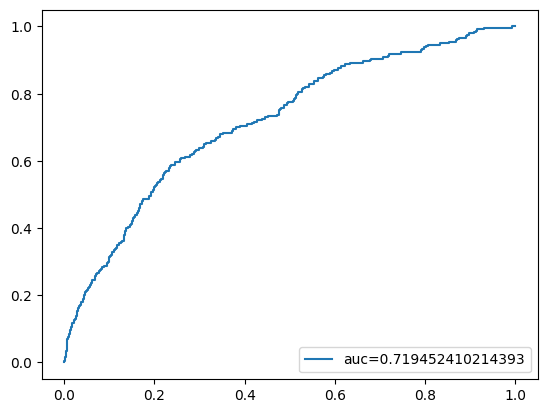

In [94]:
y_pred_proba = best_model.predict_proba(X_test)[::,1]
fpr, tpr, _ = roc_curve(y_test,  y_pred_proba)
auc = roc_auc_score(y_test, y_pred_proba)
plt.plot(fpr,tpr,label="auc="+str(auc))
plt.legend(loc=4)
plt.show()

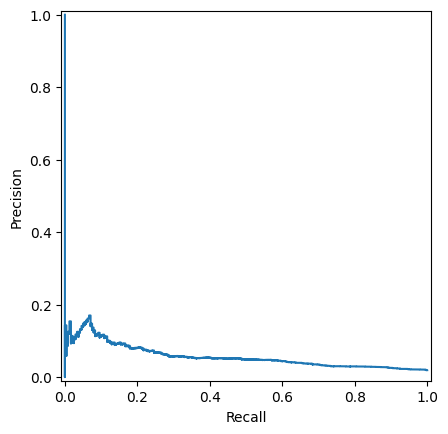

In [95]:
prec, recall, _ = precision_recall_curve(y_test, y_pred_proba, pos_label=best_model.classes_[1])
pr_display = PrecisionRecallDisplay(precision=prec, recall=recall).plot()

## Анализ важности фичей

  0%|          | 0/100 [00:00<?, ?it/s]

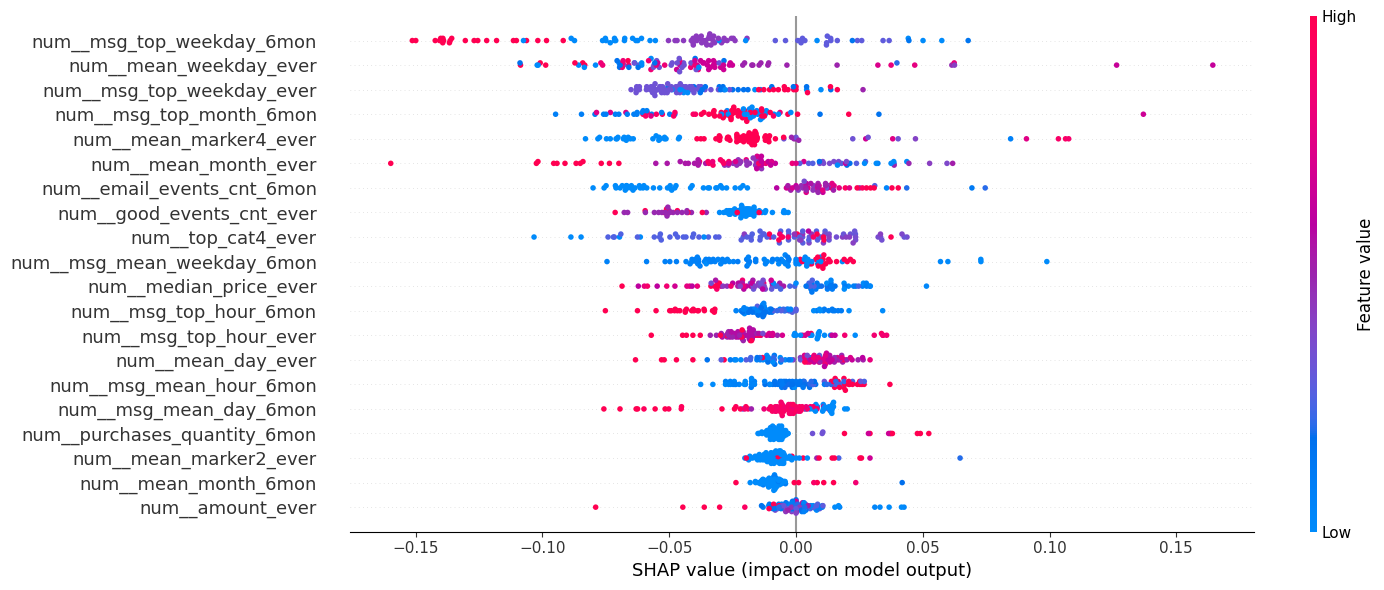

In [96]:
samples = 100
 
# Извлечение лучшей модели из результатов RandomizedSearchCV
best_model = search.best_estimator_.named_steps['models']

# Предобработка данных через пайплайн без конечной модели
preprocessor = search.best_estimator_.named_steps['preprocessor']
X_train_preprocessed = preprocessor.transform(X_train)
X_test_preprocessed = preprocessor.transform(X_test)

all_feature_names = preprocessor.get_feature_names_out()

# Создаем DataFrame с соответствующими именами колонок
X_train_preprocessed_df = pd.DataFrame(X_train_preprocessed, 
                                       columns=all_feature_names)
X_test_preprocessed_df = pd.DataFrame(X_test_preprocessed, 
                                      columns=all_feature_names)

# Семпл данных для KernelExplainer
X_train_preprocessed_smpl = shap.sample(X_train_preprocessed_df, 
                                        samples, random_state=RANDOM_STATE)
X_test_preprocessed_smpl = shap.sample(X_test_preprocessed_df, 
                                       samples, random_state=RANDOM_STATE)

# Теперь, когда у нас есть DataFrame с именами признаков, мы можем использовать KernelExplainer
###explainer = shap.KernelExplainer(best_model.predict_proba, X_train_preprocessed_smpl)
explainer = shap.KernelExplainer(best_model.predict_proba, X_train_preprocessed_smpl)
shap_values = explainer.shap_values(X_test_preprocessed_smpl)

# Создаем объект Explanation для первого КЛАССА.
shap_values_explanation = shap.Explanation(
    values=shap_values[:,:,1], 
    base_values=explainer.expected_value,
    data=X_test_preprocessed_smpl,
    feature_names=all_feature_names
)

shap.summary_plot(shap_values_explanation, plot_size=[15,6])
plt.show()

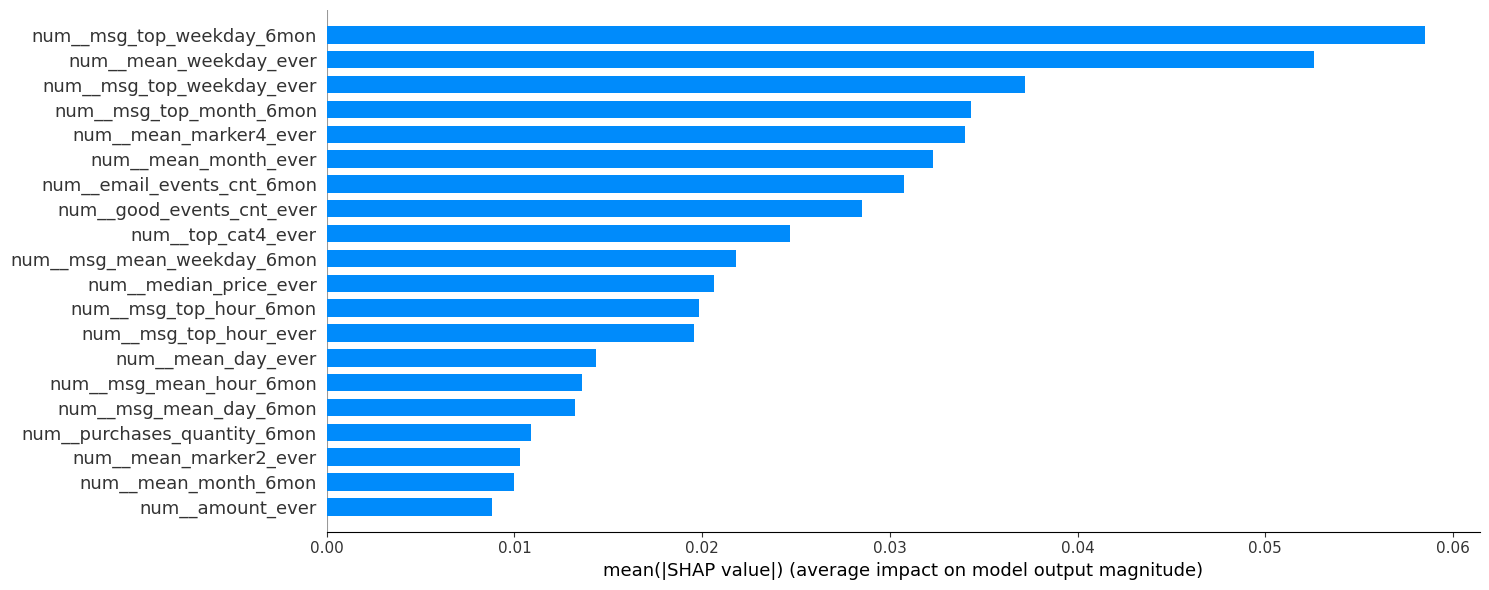

In [97]:
shap.summary_plot(shap_values_explanation, plot_size=[15,6], plot_type='bar')
plt.show()

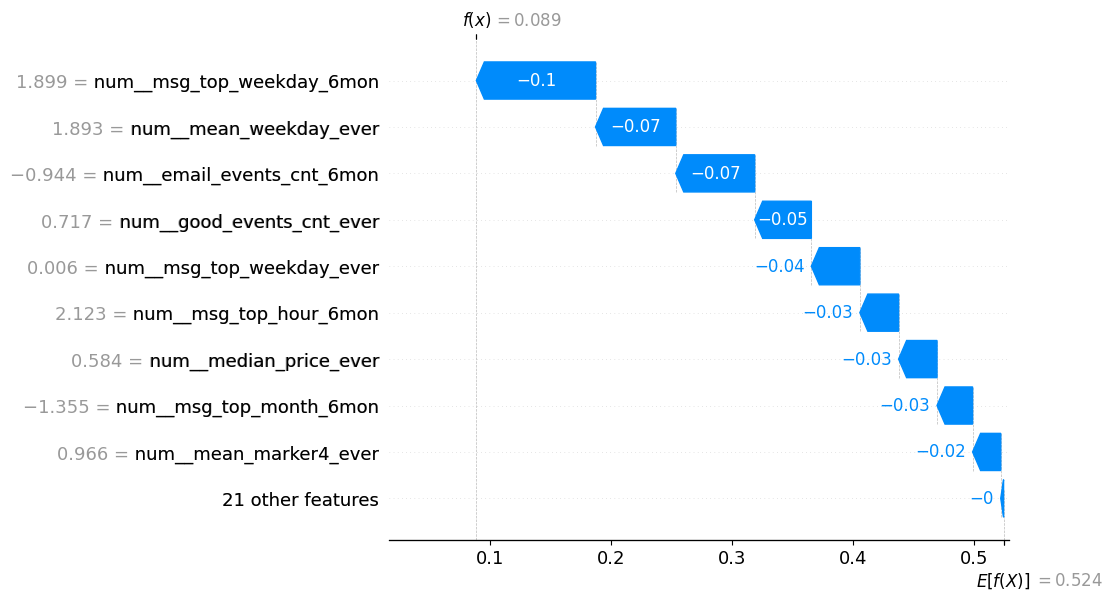

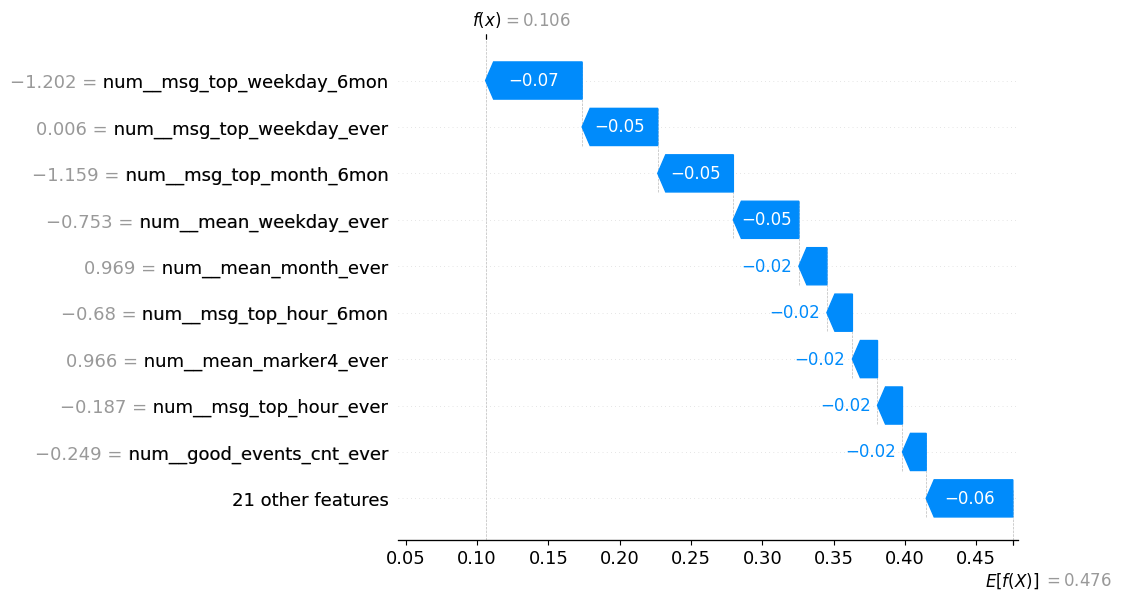

In [98]:
shap.plots.waterfall(shap_values_explanation[0]);
shap.plots.waterfall(shap_values_explanation[1]);
plt.show()

# Отчёт и выводы


- В соответствии с поставленной задачей (см. первый раздел)
    - была проведена подготовка данных и их разведочный анализ, в результате которых:
        - исправлены типы данных
        - удалены малополезные признаки (в т. ч. с учётом мультиколлинеарности)
        - сконструированы новые признаки агрегирующие статистики для каждого клиента (для которого известен целевыой признак)
        - сконструированы новые признаки по категориям
        - объеденины таблицы покупок и сообщений
        - заполнены пропуски
        - удалены явные дубликаты
    - датасет сильно несбалансированный (в тренировочной выборке 2% класс-1 и 98% класс-0)
        - обучающая выборка была сбалансирована овер и андерсэмплингом
    - была натренирована модель с примененеием pipeline, кроссвалидации и перебора гиперпараметров
        - выбрана наиболее оптимальная модель - **XGBClassifier**, показавшая наилучшие результаты:
            - качество предсказания на тестовой выборке: **roc_auc = 0.72**
            - f1 на валидационной выборке 0.87
            - на тестовой выборке очень высокие **precision=0.98 и recall=0.97 для класса-0**, но крайне низкие **precision=0.09 и recall=0.18 для класса-1**
            - TOP5 наиболее важных признаки, согласно shap:
                - num_msg_top_weekday_6_months
                - num_mean_weekday_ever
                - num_msg_top_weekday_ever
                - num_mean_marker_4_ever
                - num_mean_month_ever
- Попутные наблюдения по покупкам:
    - вероятно, категория 2 и 4 - это "маркером распродажи или маркер женщинам/мужчинам"
    - покупки представлены с 2022 по 2024 включительно (большинство покупок за 2023 год)
    - самые активные месяцы 6, 11, 12 (возможно, отпуска и новый год), наименее актинвые месяцы - 2 и 10
    - наиболее активный день недели - Пт
    - Можно было бы также добавить каналы рекламных баннеров из сайтов/поиска/приложений/видео - это помогло бы предсказывать ещё точнее.
    - по графику распределения видно, что есть 2 пика по значению id и они ближе к левому краю. Из этого можно сделать вывод (в предположении, что id выдавались последовательно), что были две большие волны подключения клиентов, причём они - ближе к началу наблюдаемого периода. Значит рост сервиса замедлился.
- Попутные наблюдения по рассылкам:
    - По распределению видно, что последние кампании рассылок (в предположении, что они нумеруются последовательно) более значительно массивные. Возможно, это связано с предыдущем наблюдением-предположением о замедлении роста сервиса - интерес клиентов стараются привлечь активнее, чем раньше.
    - Видна периодичность рассылок - пики примерно раз в неделю в Пт, а самый неактивный день - Вс.
    - Пик пушей - вечером. Очень много пушей в утреннее время. Очень хочется верить, что это связано с разными рассылкой по разным таймзонам, и что никому в его таймзоне не рассылаются пуши ночью во время сна. 
        - ⚠️[!] стоит написать в выводах продакт менеджерам, на всякий случай, пусть проверят (проверить в датасете это не удастся из-за отсутствия информации о таймзоне клиента).
    - Статистика по сообщениям:
        - send = 9058174
        - open = 3052481
        - click = 483326
        - purchase = 62593
        - hard_bounce = 19763
        - soft_bounce = 10582
        - unsubscribe = 2833
        - hbq_spam = 823
        - complain = 527
        - subscribe = 85
        - close = 1
    

# Appendix - comments legend

These icons and [tags] were used to simplify visualization and searching for conclusions, open questions and subtasks, not to forget to finish/check something important. It's convenient to copy a cell from here and paste it into the right place, adding details and then find it by tags or visually.

👷🚩[todo] 

⬆ this task is to be done

👷✅ 

⬆ the task has been done

👷🚨[SOS] 

⬆ need help

👷🔔[reminder] 

⬆ some work to do or check later

⚠️[!] 

⬆ important constraints or facts

💡 [!] 

⬆ something interesting

🏭 [data transformation] this change ⤴ should be done before training/testing/inference

👷🚧🚧🚧🚧🚧 [in progress] 

⬆ in progress right now

🚧⬇️🚧⬇️🚧⬇️🚧⬇️🚧⬇️🚧⬇️🚧⬇️🚧⬇️🚧⬇️🚧⬇️🚧

➡️ some code to be reworked ⬅️

🚧⬆️🚧⬆️🚧⬆️🚧⬆️🚧⬆️🚧⬆️🚧⬆️🚧⬆️🚧⬆️🚧⬆️🚧